#Pattern-Based Generator

In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import uuid

class PatternBasedGenerator:
    def __init__(self, start_date="2023-01-01", end_date="2023-12-31", seed=42):
        """Initialize the pattern-based generator with date range and random seed"""
        self.start_date = datetime.strptime(start_date, "%Y-%m-%d")
        self.end_date = datetime.strptime(end_date, "%Y-%m-%d")
        random.seed(seed)
        np.random.seed(seed)

        # Define entities for transactions
        self.entities = {
            "legitimate": [
                {"name": "LegitCorp A", "country": "LV", "risk": "LOW"},
                {"name": "EuroTrade B", "country": "DE", "risk": "LOW"},
                {"name": "Nordic Services", "country": "FI", "risk": "LOW"},
                {"name": "Baltic Imports", "country": "LT", "risk": "LOW"}
            ],
            "suspicious": [
                {"name": "Shell Corp X", "country": "CY", "risk": "HIGH"},
                {"name": "Offshore Holdings", "country": "VG", "risk": "HIGH"},
                {"name": "Transit Solutions", "country": "LV", "risk": "MEDIUM"},
                {"name": "Global Intermediary", "country": "HK", "risk": "HIGH"}
            ]
        }

    def _random_date(self):
        """Generate a random date within the specified range"""
        delta = (self.end_date - self.start_date).days
        random_days = random.randint(0, delta)
        return self.start_date + timedelta(days=random_days)

    def _random_entity(self, category="legitimate"):
        """Select a random entity from the specified category"""
        return random.choice(self.entities[category])

    def generate_transit_payments(self, count=10):
        """Generate transit payment patterns (funds quickly moved after receipt)"""
        transactions = []

        for _ in range(count):
            # Select entities for the pattern
            sender = self._random_entity("legitimate")
            intermediary = self._random_entity("suspicious")
            final_recipient = self._random_entity("suspicious")

            # Generate base amount and date
            amount = random.uniform(10000, 100000)
            base_date = self._random_date()

            # First transaction: legitimate → intermediary
            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": base_date,
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "receiver_name": intermediary["name"],
                "receiver_country": intermediary["country"],
                "amount": amount,
                "currency": "EUR",
                "description": "Payment for consulting services",
                "is_suspicious": True,
                "pattern": "transit_payment",
                "phase": "placement"
            })

            # Second transaction: intermediary → final recipient (within 1-2 days)
            transit_delay = random.randint(4, 48)  # Hours
            second_date = base_date + timedelta(hours=transit_delay)

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": second_date,
                "sender_name": intermediary["name"],
                "sender_country": intermediary["country"],
                "receiver_name": final_recipient["name"],
                "receiver_country": final_recipient["country"],
                "amount": amount * random.uniform(0.95, 0.99),  # Slightly less to simulate fees
                "currency": "EUR",
                "description": "Business expense reimbursement",
                "is_suspicious": True,
                "pattern": "transit_payment",
                "phase": "layering"
            })

        return transactions

    def generate_round_trip_transactions(self, count=5):
        """Generate round-trip transaction patterns (funds eventually return to originator)"""
        transactions = []

        for _ in range(count):
            # Select entities
            origin_entity = self._random_entity("suspicious")
            intermediary1 = self._random_entity("suspicious")
            intermediary2 = self._random_entity("suspicious")

            # Generate base amount and start date
            amount = random.uniform(50000, 500000)
            base_date = self._random_date()

            # First leg: origin → intermediary1
            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": base_date,
                "sender_name": origin_entity["name"],
                "sender_country": origin_entity["country"],
                "receiver_name": intermediary1["name"],
                "receiver_country": intermediary1["country"],
                "amount": amount,
                "currency": "EUR",
                "description": "Investment funding",
                "is_suspicious": True,
                "pattern": "round_trip",
                "phase": "placement"
            })

            # Second leg: intermediary1 → intermediary2
            second_date = base_date + timedelta(days=random.randint(3, 10))
            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": second_date,
                "sender_name": intermediary1["name"],
                "sender_country": intermediary1["country"],
                "receiver_name": intermediary2["name"],
                "receiver_country": intermediary2["country"],
                "amount": amount * random.uniform(0.93, 0.98),
                "currency": "EUR",
                "description": "Project financing",
                "is_suspicious": True,
                "pattern": "round_trip",
                "phase": "layering"
            })

            # Third leg: intermediary2 → back to origin
            third_date = second_date + timedelta(days=random.randint(5, 15))
            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": third_date,
                "sender_name": intermediary2["name"],
                "sender_country": intermediary2["country"],
                "receiver_name": origin_entity["name"],
                "receiver_country": origin_entity["country"],
                "amount": amount * random.uniform(0.85, 0.92),
                "currency": "EUR",
                "description": "Return of unused funds",
                "is_suspicious": True,
                "pattern": "round_trip",
                "phase": "integration"
            })

        return transactions

    def generate_structured_transactions(self, count=8):
        """Generate structured transactions to avoid reporting thresholds"""
        transactions = []
        threshold = 10000  # Common reporting threshold

        for _ in range(count):
            sender = self._random_entity("suspicious")
            receiver = self._random_entity("legitimate")

            # Total amount that would trigger reporting
            total_amount = random.uniform(threshold*3, threshold*10)
            base_date = self._random_date()

            # Break into smaller amounts
            remaining = total_amount
            fragment_count = random.randint(4, 12)

            for i in range(fragment_count):
                # Calculate fragment amount (slightly below threshold)
                if i == fragment_count - 1:
                    amount = remaining
                else:
                    max_fragment = min(threshold * 0.95, remaining * 0.5)
                    amount = random.uniform(max_fragment * 0.5, max_fragment)
                    remaining -= amount

                # Add small time gap between transactions
                tx_date = base_date + timedelta(hours=random.randint(1, 8) * i)

                transactions.append({
                    "transaction_id": str(uuid.uuid4()),
                    "date": tx_date,
                    "sender_name": sender["name"],
                    "sender_country": sender["country"],
                    "receiver_name": receiver["name"],
                    "receiver_country": receiver["country"],
                    "amount": amount,
                    "currency": "EUR",
                    "description": f"Payment installment {i+1}",
                    "is_suspicious": True,
                    "pattern": "structuring",
                    "phase": "placement"
                })

        return transactions

    def generate_high_risk_country_transactions(self, count=10):
        """Generate transactions involving high-risk jurisdictions"""
        transactions = []
        high_risk_countries = ["VG", "CY", "PA", "AE", "RU"]

        for _ in range(count):
            # Ensure one party is in a high-risk country
            if random.random() < 0.5:
                sender = {"name": f"Foreign Entity {random.randint(1, 100)}",
                        "country": random.choice(high_risk_countries),
                        "risk": "HIGH"}
                receiver = self._random_entity("suspicious")
            else:
                sender = self._random_entity("suspicious")
                receiver = {"name": f"Offshore Entity {random.randint(1, 100)}",
                          "country": random.choice(high_risk_countries),
                          "risk": "HIGH"}

            amount = random.uniform(20000, 2000000)
            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": self._random_date(),
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "amount": amount,
                "currency": "USD",
                "description": "International business payment",
                "is_suspicious": True,
                "pattern": "high_risk_jurisdiction",
                "phase": "placement"
            })

        return transactions

    def generate_legitimate_transactions(self, count=100):
        """Generate legitimate transactions for background noise"""
        transactions = []

        descriptions = [
            "Invoice payment", "Supplier payment", "Monthly service fee",
            "Consulting fees", "Equipment purchase", "Software license",
            "Operational expenses", "Salary payment", "Office rent"
        ]

        for _ in range(count):
            sender = self._random_entity("legitimate")

            # Occasionally legitimate entities transact with suspicious ones (but not marked suspicious)
            if random.random() < 0.1:
                receiver = self._random_entity("suspicious")
            else:
                receiver = self._random_entity("legitimate")

            amount = random.lognormvariate(8, 1)  # Log-normal distribution for amounts

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": self._random_date(),
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "amount": amount,
                "currency": random.choice(["EUR", "USD", "GBP"]),
                "description": random.choice(descriptions),
                "is_suspicious": False,
                "pattern": "legitimate",
                "phase": None
            })

        return transactions

    def generate_dataset(self, total_count=200, suspicious_ratio=0.15):
        """Generate complete dataset with specified ratio of suspicious transactions"""
        suspicious_count = int(total_count * suspicious_ratio)
        legitimate_count = total_count - suspicious_count

        # Distribute suspicious patterns
        transit_count = suspicious_count // 5
        round_trip_count = suspicious_count // 5
        structuring_count = suspicious_count // 5
        high_risk_count = suspicious_count // 5

        # Generate all transaction types
        all_transactions = []
        all_transactions.extend(self.generate_transit_payments(transit_count))
        all_transactions.extend(self.generate_round_trip_transactions(round_trip_count))
        all_transactions.extend(self.generate_structured_transactions(structuring_count))
        all_transactions.extend(self.generate_high_risk_country_transactions(high_risk_count))
        all_transactions.extend(self.generate_legitimate_transactions(legitimate_count))

        # Convert to DataFrame and sort by date
        df = pd.DataFrame(all_transactions)
        df = df.sort_values('date')

        return df

# Example usage
generator = PatternBasedGenerator()
transactions_df = generator.generate_dataset(200, 0.15)
transactions_df.to_excel("pattern_based_aml_data.xlsx", index=False)
print(f"Generated {len(transactions_df)} transactions, {transactions_df['is_suspicious'].sum()} suspicious")

Generated 258 transactions, 88 suspicious


#Entity Network-Based Generator

In [ ]:
import pandas as pd
import numpy as np
import random
import networkx as nx
from datetime import datetime, timedelta
import uuid

class EntityNetworkGenerator:
    def __init__(self, start_date="2023-01-01", end_date="2023-12-31", seed=42):
        """Initialize the entity network-based generator"""
        self.start_date = datetime.strptime(start_date, "%Y-%m-%d")
        self.end_date = datetime.strptime(end_date, "%Y-%m-%d")
        random.seed(seed)
        np.random.seed(seed)

        # Generate entity network
        self.entity_graph = self._build_entity_network()

    def _build_entity_network(self):
        """Build a network of entities with different relationship types"""
        G = nx.DiGraph()

        # Define entity categories
        legitimate_entities = [
            {"id": "L1", "name": "European Trade Co", "country": "DE", "risk": "LOW", "type": "trading"},
            {"id": "L2", "name": "Nordic Manufacturing", "country": "SE", "risk": "LOW", "type": "manufacturing"},
            {"id": "L3", "name": "Baltic Logistics", "country": "LV", "risk": "LOW", "type": "logistics"},
            {"id": "L4", "name": "Tech Innovations", "country": "EE", "risk": "LOW", "type": "technology"},
            {"id": "L5", "name": "Consumer Goods Ltd", "country": "GB", "risk": "LOW", "type": "retail"}
        ]

        shell_companies = [
            {"id": "S1", "name": "Global Holdings Ltd", "country": "CY", "risk": "HIGH", "type": "holding"},
            {"id": "S2", "name": "Overseas Services Inc", "country": "PA", "risk": "HIGH", "type": "services"},
            {"id": "S3", "name": "International Transit Co", "country": "VG", "risk": "HIGH", "type": "services"}
        ]

        intermediaries = [
            {"id": "I1", "name": "Finance Solutions", "country": "LU", "risk": "MEDIUM", "type": "financial"},
            {"id": "I2", "name": "Business Consultancy", "country": "CH", "risk": "MEDIUM", "type": "consulting"},
            {"id": "I3", "name": "Trading Partners LLC", "country": "US", "risk": "MEDIUM", "type": "trading"}
        ]

        high_risk_entities = [
            {"id": "H1", "name": "Eastern Investment Group", "country": "RU", "risk": "HIGH", "type": "investment"},
            {"id": "H2", "name": "Middle East Trading", "country": "AE", "risk": "HIGH", "type": "trading"}
        ]

        # Add all entities to the graph
        all_entities = legitimate_entities + shell_companies + intermediaries + high_risk_entities
        for entity in all_entities:
            G.add_node(entity["id"],
                     name=entity["name"],
                     country=entity["country"],
                     risk=entity["risk"],
                     type=entity["type"],
                     category="legitimate" if entity in legitimate_entities else "suspicious")

        # Create relationships for money laundering typologies

        # 1. Shell company structures
        G.add_edge("S1", "S2", relationship="ownership", weight=0.8)
        G.add_edge("S2", "S3", relationship="ownership", weight=0.7)

        # 2. Transit payment paths
        G.add_edge("L1", "I1", relationship="business", weight=0.4)
        G.add_edge("I1", "S1", relationship="business", weight=0.6)
        G.add_edge("S1", "H1", relationship="business", weight=0.8)

        # 3. Round-trip circuits
        G.add_edge("S2", "I2", relationship="business", weight=0.5)
        G.add_edge("I2", "I3", relationship="business", weight=0.5)
        G.add_edge("I3", "S2", relationship="business", weight=0.7)

        # 4. Legitimate business connections
        G.add_edge("L2", "L3", relationship="business", weight=0.3)
        G.add_edge("L3", "L4", relationship="business", weight=0.2)
        G.add_edge("L4", "L5", relationship="business", weight=0.2)

        # 5. High-risk jurisdiction connections
        G.add_edge("I3", "H2", relationship="business", weight=0.6)
        G.add_edge("H2", "S3", relationship="hidden_ownership", weight=0.9)

        # Add more random connections for realism
        for _ in range(10):
            source = random.choice(all_entities)["id"]
            target = random.choice(all_entities)["id"]
            if source != target and not G.has_edge(source, target):
                G.add_edge(source, target,
                         relationship="business",
                         weight=random.uniform(0.1, 0.4))

        return G

    def _random_date(self):
        """Generate a random date within the specified range"""
        delta = (self.end_date - self.start_date).days
        random_days = random.randint(0, delta)
        return self.start_date + timedelta(days=random_days)

    def _get_entity_by_id(self, entity_id):
        """Get entity attributes by ID"""
        return {
            "id": entity_id,
            "name": self.entity_graph.nodes[entity_id]["name"],
            "country": self.entity_graph.nodes[entity_id]["country"],
            "risk": self.entity_graph.nodes[entity_id]["risk"]
        }

    def generate_path_transactions(self, min_length=2, max_length=4, count=10):
        """Generate transactions that follow paths in the entity network"""
        transactions = []

        # Find all simple paths of required length
        all_nodes = list(self.entity_graph.nodes())

        for _ in range(count):
            # Select random start and end points
            start_node = random.choice(all_nodes)
            end_node = random.choice(all_nodes)

            if start_node == end_node:
                continue

            # Find paths between these nodes
            try:
                all_paths = list(nx.all_simple_paths(
                    self.entity_graph, start_node, end_node,
                    cutoff=max_length))

                # Filter paths by minimum length
                valid_paths = [p for p in all_paths if len(p) >= min_length]

                if valid_paths:
                    # Select one path randomly
                    path = random.choice(valid_paths)

                    # Generate a series of transactions along this path
                    amount = random.uniform(20000, 500000)
                    base_date = self._random_date()
                    is_suspicious = any(self.entity_graph.nodes[node]["risk"] == "HIGH" for node in path) or len(path) > 3

                    # Determine pattern type
                    if path[0] == path[-1]:
                        pattern = "round_trip"
                    elif any(self.entity_graph.nodes[node]["country"] in ["CY", "VG", "PA"] for node in path):
                        pattern = "shell_company"
                    elif len(path) > 3:
                        pattern = "layering"
                    elif any(self.entity_graph.nodes[node]["country"] in ["RU", "AE"] for node in path):
                        pattern = "high_risk_jurisdiction"
                    else:
                        pattern = "transit" if is_suspicious else "legitimate"

                    # Generate transactions along the path
                    for i in range(len(path)-1):
                        source = self._get_entity_by_id(path[i])
                        target = self._get_entity_by_id(path[i+1])

                        edge_data = self.entity_graph.get_edge_data(path[i], path[i+1])
                        relationship = edge_data["relationship"]

                        # Create description based on relationship
                        if relationship == "ownership":
                            description = "Internal transfer between related entities"
                        elif relationship == "hidden_ownership":
                            description = "Strategic partnership investment"
                        else:
                            description = "Business transaction payment"

                        # Add time delay between transactions in the chain
                        tx_date = base_date + timedelta(days=random.randint(1, 5) * i)

                        # Reduce amount slightly at each step
                        step_amount = amount * (1 - (0.02 * i))

                        transactions.append({
                            "transaction_id": str(uuid.uuid4()),
                            "date": tx_date,
                            "sender_id": source["id"],
                            "sender_name": source["name"],
                            "sender_country": source["country"],
                            "receiver_id": target["id"],
                            "receiver_name": target["name"],
                            "receiver_country": target["country"],
                            "relationship": relationship,
                            "amount": step_amount,
                            "currency": "EUR",
                            "description": description,
                            "is_suspicious": is_suspicious,
                            "pattern": pattern,
                            "phase": ["placement", "layering", "integration"][min(i, 2)]
                        })
            except nx.NetworkXNoPath:
                continue

        return transactions

    def generate_shell_company_transactions(self, count=10):
        """Generate transactions specifically involving shell companies"""
        transactions = []
        shell_company_ids = ["S1", "S2", "S3"]

        for _ in range(count):
            # Select a shell company and a legitimate entity
            shell_id = random.choice(shell_company_ids)
            shell = self._get_entity_by_id(shell_id)

            # Find potential legitimate partners
            legitimate_ids = [n for n, attr in self.entity_graph.nodes(data=True)
                            if attr["category"] == "legitimate"]

            if not legitimate_ids:
                continue

            legitimate_id = random.choice(legitimate_ids)
            legitimate = self._get_entity_by_id(legitimate_id)

            # Determine direction (50% chance each way)
            if random.random() < 0.5:
                sender, receiver = legitimate, shell
            else:
                sender, receiver = shell, legitimate

            # Generate transaction
            amount = random.uniform(50000, 1000000)

            # Create obscure description
            descriptions = [
                "Consulting services", "Strategic development", "Market research",
                "Advisory fees", "Management services", "Intellectual property license",
                "Technical support services"
            ]

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": self._random_date(),
                "sender_id": sender["id"],
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "receiver_id": receiver["id"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "relationship": "business",
                "amount": amount,
                "currency": "EUR",
                "description": random.choice(descriptions),
                "is_suspicious": True,
                "pattern": "shell_company",
                "phase": "layering"
            })

        return transactions

    def generate_high_risk_jurisdiction_transactions(self, count=10):
        """Generate transactions involving high-risk jurisdictions"""
        transactions = []
        high_risk_countries = ["RU", "AE", "CY", "VG", "PA"]

        for _ in range(count):
            # Find entities in high-risk countries
            high_risk_ids = [n for n, attr in self.entity_graph.nodes(data=True)
                           if attr["country"] in high_risk_countries]

            if not high_risk_ids:
                continue

            high_risk_id = random.choice(high_risk_ids)
            high_risk = self._get_entity_by_id(high_risk_id)

            # Find other entities to transact with
            other_ids = [n for n in self.entity_graph.nodes() if n != high_risk_id]
            other_id = random.choice(other_ids)
            other = self._get_entity_by_id(other_id)

            # Determine direction (70% incoming to high risk)
            if random.random() < 0.7:
                sender, receiver = other, high_risk
            else:
                sender, receiver = high_risk, other

            # Generate transaction
            amount = random.uniform(100000, 2000000)

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": self._random_date(),
                "sender_id": sender["id"],
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "receiver_id": receiver["id"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "relationship": "business",
                "amount": amount,
                "currency": random.choice(["EUR", "USD"]),
                "description": "International business transaction",
                "is_suspicious": True,
                "pattern": "high_risk_jurisdiction",
                "phase": "placement" if sender["risk"] == "LOW" else "integration"
            })

        return transactions

    def generate_legitimate_transactions(self, count=100):
        """Generate legitimate transactions between entities"""
        transactions = []

        # Find legitimate entities
        legitimate_ids = [n for n, attr in self.entity_graph.nodes(data=True)
                        if attr["category"] == "legitimate"]

        if not legitimate_ids or len(legitimate_ids) < 2:
            return transactions

        for _ in range(count):
            # Select two different legitimate entities
            sender_id = random.choice(legitimate_ids)
            receiver_ids = [n for n in legitimate_ids if n != sender_id]

            if not receiver_ids:
                continue

            receiver_id = random.choice(receiver_ids)

            sender = self._get_entity_by_id(sender_id)
            receiver = self._get_entity_by_id(receiver_id)

            # Generate realistic business transaction
            amount = random.lognormvariate(9, 1)  # Log-normal distribution

            descriptions = [
                "Invoice payment", "Payment for goods", "Service fee",
                "Quarterly payment", "Contract payment", "Subscription fee"
            ]

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": self._random_date(),
                "sender_id": sender["id"],
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "receiver_id": receiver["id"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "relationship": "business",
                "amount": amount,
                "currency": random.choice(["EUR", "USD", "GBP"]),
                "description": random.choice(descriptions),
                "is_suspicious": False,
                "pattern": "legitimate",
                "phase": None
            })

        return transactions

    def generate_dataset(self, total_count=200, suspicious_ratio=0.15):
        """Generate complete dataset with specified ratio of suspicious transactions"""
        suspicious_count = int(total_count * suspicious_ratio)
        legitimate_count = total_count - suspicious_count

        # Allocate suspicious transactions across patterns
        path_count = suspicious_count // 3
        shell_count = suspicious_count // 3
        high_risk_count = suspicious_count - path_count - shell_count

        # Generate all transaction types
        all_transactions = []
        all_transactions.extend(self.generate_path_transactions(count=path_count))
        all_transactions.extend(self.generate_shell_company_transactions(count=shell_count))
        all_transactions.extend(self.generate_high_risk_jurisdiction_transactions(count=high_risk_count))
        all_transactions.extend(self.generate_legitimate_transactions(count=legitimate_count))

        # Convert to DataFrame and sort by date
        df = pd.DataFrame(all_transactions)
        df = df.sort_values('date')

        return df

# Example usage
generator = EntityNetworkGenerator()
transactions_df = generator.generate_dataset(200, 0.15)
transactions_df.to_excel("entity_network_aml_data.xlsx", index=False)
print(f"Generated {len(transactions_df)} transactions, {transactions_df['is_suspicious'].sum()} suspicious")

Generated 206 transactions, 36 suspicious


#Document Simulation Generator

In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import uuid

class DocumentSimulationGenerator:
    def __init__(self, start_date="2023-01-01", end_date="2023-12-31", seed=42):
        """Initialize the document simulation generator"""
        self.start_date = datetime.strptime(start_date, "%Y-%m-%d")
        self.end_date = datetime.strptime(end_date, "%Y-%m-%d")
        random.seed(seed)
        np.random.seed(seed)

        # Define base entities
        self.entities = self._create_entities()

        # Track invoice and contract numbers to simulate duplicates
        self.used_invoice_numbers = set()
        self.used_contract_numbers = set()

    def _create_entities(self):
        """Create a set of entities with different characteristics"""
        entities = {
            "legitimate": [
                {"name": "European Trade Co.", "industry": "Trade", "country": "DE", "founding_date": "2005-06-12"},
                {"name": "Nordic Services AB", "industry": "Services", "country": "SE", "founding_date": "2008-03-22"},
                {"name": "Tech Solutions Ltd", "industry": "IT", "country": "GB", "founding_date": "2010-11-05"},
                {"name": "Baltic Transport", "industry": "Logistics", "country": "LV", "founding_date": "2012-08-30"}
            ],
            "suspicious": [
                {"name": "Global Consultancy Inc.", "industry": "Consulting", "country": "CY", "founding_date": "2021-02-18"},
                {"name": "Strategic Investments Ltd", "industry": "Investment", "country": "VG", "founding_date": "2022-05-07"},
                {"name": "Universal Trading Corp", "industry": "Trade", "country": "PA", "founding_date": "2020-10-13"},
                {"name": "EastWest Partners LLC", "industry": "Financial", "country": "RU", "founding_date": "2019-04-29"}
            ]
        }
        return entities

    def _random_date(self):
        """Generate a random date within the specified range"""
        delta = (self.end_date - self.start_date).days
        random_days = random.randint(0, delta)
        return self.start_date + timedelta(days=random_days)

    def _random_entity(self, category="legitimate"):
        """Select a random entity from the specified category"""
        return random.choice(self.entities[category])

    def _generate_document_number(self, document_type, invalid=False):
        """Generate document numbers (invoices, contracts)"""
        if document_type == "invoice":
            if invalid:
                # Generate duplicate or malformed invoice number
                if self.used_invoice_numbers and random.random() < 0.7:
                    # Use duplicate
                    return random.choice(list(self.used_invoice_numbers))
                else:
                    # Generate malformed
                    return f"INV{''.join(random.choices('0123456789', k=random.randint(1, 3)))}"
            else:
                # Generate valid invoice number
                invoice_num = f"INV-{random.randint(10000, 99999)}-{random.randint(1000, 9999)}"
                self.used_invoice_numbers.add(invoice_num)
                return invoice_num

        elif document_type == "contract":
            if invalid:
                # Generate duplicate or malformed contract number
                if self.used_contract_numbers and random.random() < 0.7:
                    # Use duplicate
                    return random.choice(list(self.used_contract_numbers))
                else:
                    # Generate malformed
                    return f"CONT{''.join(random.choices('0123456789', k=random.randint(1, 4)))}"
            else:
                # Generate valid contract number
                contract_num = f"CONT-{random.randint(100, 999)}/{random.randint(1000, 9999)}"
                self.used_contract_numbers.add(contract_num)
                return contract_num

        return None

    def generate_insufficient_documentation_transactions(self, count=10):
        """Generate transactions with insufficient documentation"""
        transactions = []

        for _ in range(count):
            # Usually between suspicious entities, occasionally involving legitimate ones
            if random.random() < 0.8:
                sender = self._random_entity("suspicious")
                receiver = self._random_entity("suspicious")
            else:
                sender = self._random_entity("legitimate")
                receiver = self._random_entity("suspicious")

            amount = random.uniform(50000, 500000)

            # Generate minimal or suspicious documentation
            tx_date = self._random_date()

            # Insufficient description variations
            insufficient_descriptions = [
                "Payment",
                "Transfer",
                "Business",
                "Services",
                "Fee",
                "Commission",
                "General"
            ]

            # Optional document reference
            doc_reference = ""
            if random.random() < 0.5:
                if random.random() < 0.7:
                    # Invalid or malformed document number
                    doc_type = random.choice(["invoice", "contract"])
                    doc_reference = f", {doc_type} {self._generate_document_number(doc_type, True)}"
                else:
                    # Missing document number
                    doc_reference = ", invoice pending"

            description = random.choice(insufficient_descriptions) + doc_reference

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": tx_date,
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "sender_industry": sender["industry"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "receiver_industry": receiver["industry"],
                "amount": amount,
                "currency": random.choice(["EUR", "USD"]),
                "description": description,
                "document_type": "insufficient",
                "is_suspicious": True,
                "pattern": "insufficient_documentation",
                "suspicious_factor": "minimal_details"
            })

        return transactions

    def generate_inconsistent_business_transactions(self, count=10):
        """Generate transactions inconsistent with declared business activities"""
        transactions = []

        # Define inconsistent industry pairs
        inconsistent_pairs = [
            ("IT", "Agriculture"),
            ("Logistics", "Healthcare"),
            ("Financial", "Construction"),
            ("Trade", "Education"),
            ("Services", "Mining")
        ]

        for _ in range(count):
            # Usually involves at least one suspicious entity
            if random.random() < 0.7:
                sender = self._random_entity("suspicious")
                receiver = self._random_entity("legitimate")
            else:
                sender = self._random_entity("legitimate")
                receiver = self._random_entity("suspicious")

            amount = random.uniform(100000, 1000000)
            tx_date = self._random_date()

            # Create inconsistent business description
            inconsistent_industry, _ = random.choice(inconsistent_pairs)

            inconsistent_descriptions = [
                f"{inconsistent_industry} equipment purchase",
                f"{inconsistent_industry} advisory services",
                f"{inconsistent_industry} project development",
                f"{inconsistent_industry} consulting",
                f"{inconsistent_industry} research funding"
            ]

            # Add document reference
            doc_type = random.choice(["invoice", "contract"])
            doc_number = self._generate_document_number(doc_type, random.random() < 0.3)

            description = f"{random.choice(inconsistent_descriptions)}, {doc_type} {doc_number}"

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": tx_date,
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "sender_industry": sender["industry"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "receiver_industry": receiver["industry"],
                "amount": amount,
                "currency": random.choice(["EUR", "USD"]),
                "description": description,
                "document_type": doc_type,
                "document_number": doc_number,
                "is_suspicious": True,
                "pattern": "inconsistent_business",
                "suspicious_factor": "industry_mismatch"
            })

        return transactions

    def generate_fictitious_loan_transactions(self, count=10):
        """Generate fictitious loan transactions"""
        transactions = []

        for _ in range(count):
            # Generate a pair of entities, usually both suspicious
            if random.random() < 0.8:
                entity1 = self._random_entity("suspicious")
                entity2 = self._random_entity("suspicious")
            else:
                entity1 = self._random_entity("suspicious")
                entity2 = self._random_entity("legitimate")

            # Create loan documentation issues
            loan_amount = random.uniform(200000, 2000000)
            base_date = self._random_date()

            # Generate fictitious loan contract
            contract_num = self._generate_document_number("contract", random.random() < 0.4)

            # First transaction: loan issuance
            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": base_date,
                "sender_name": entity1["name"],
                "sender_country": entity1["country"],
                "sender_industry": entity1["industry"],
                "receiver_name": entity2["name"],
                "receiver_country": entity2["country"],
                "receiver_industry": entity2["industry"],
                "amount": loan_amount,
                "currency": "EUR",
                "description": f"Loan agreement, contract {contract_num}",
                "document_type": "contract",
                "document_number": contract_num,
                "is_suspicious": True,
                "pattern": "fictitious_loan",
                "suspicious_factor": "unusually_favorable_terms"
            })

            # Sometimes generate early repayment (red flag)
            if random.random() < 0.7:
                repayment_date = base_date + timedelta(days=random.randint(10, 60))
                repayment_amount = loan_amount * random.uniform(1.0, 1.05)

                transactions.append({
                    "transaction_id": str(uuid.uuid4()),
                    "date": repayment_date,
                    "sender_name": entity2["name"],
                    "sender_country": entity2["country"],
                    "sender_industry": entity2["industry"],
                    "receiver_name": entity1["name"],
                    "receiver_country": entity1["country"],
                    "receiver_industry": entity1["industry"],
                    "amount": repayment_amount,
                    "currency": "EUR",
                    "description": f"Loan repayment, contract {contract_num}",
                    "document_type": "contract",
                    "document_number": contract_num,
                    "is_suspicious": True,
                    "pattern": "fictitious_loan",
                    "suspicious_factor": "early_repayment"
                })

        return transactions

    def generate_falsified_invoice_transactions(self, count=10):
        """Generate transactions with falsified invoice characteristics"""
        transactions = []

        for _ in range(count):
            # Usually between suspicious and legitimate entities
            if random.random() < 0.6:
                sender = self._random_entity("suspicious")
                receiver = self._random_entity("legitimate")
            else:
                sender = self._random_entity("legitimate")
                receiver = self._random_entity("suspicious")

            tx_date = self._random_date()

            # Round amount (often a sign of falsified invoices)
            amount = random.choice([10000, 25000, 50000, 100000, 250000, 500000, 1000000])

            # Generate invoice with issues
            invoice_num = self._generate_document_number("invoice", random.random() < 0.5)

            # Falsification indicators
            falsification_types = [
                "inflated_value",
                "non_existent_goods",
                "duplicate_invoice",
                "round_amount"
            ]

            suspicious_factor = random.choice(falsification_types)

            # Create description based on falsification type
            if suspicious_factor == "inflated_value":
                description = f"Payment for premium services, invoice {invoice_num}"
            elif suspicious_factor == "non_existent_goods":
                description = f"Special project delivery, invoice {invoice_num}"
            elif suspicious_factor == "duplicate_invoice":
                description = f"Repeated payment, invoice {invoice_num}"
            else:  # round_amount
                description = f"Business consulting services, invoice {invoice_num}"

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": tx_date,
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "sender_industry": sender["industry"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "receiver_industry": receiver["industry"],
                "amount": amount,
                "currency": "EUR",
                "description": description,
                "document_type": "invoice",
                "document_number": invoice_num,
                "is_suspicious": True,
                "pattern": "falsified_documentation",
                "suspicious_factor": suspicious_factor
            })

        return transactions

    def generate_legitimate_transactions(self, count=100):
        """Generate legitimate transactions with proper documentation"""
        transactions = []

        for _ in range(count):
            sender = self._random_entity("legitimate")

            # Occasionally legitimate entities transact with suspicious ones
            if random.random() < 0.1:
                receiver = self._random_entity("suspicious")
            else:
                receiver = self._random_entity("legitimate")

            amount = random.lognormvariate(9, 1)  # Log-normal distribution
            tx_date = self._random_date()

            # Legitimate document references
            doc_type = random.choice(["invoice", "contract"])
            doc_number = self._generate_document_number(doc_type, False)

            # Legitimate business descriptions
            descriptions = [
                f"Payment for {sender['industry']} services",
                f"{sender['industry']} product delivery",
                f"Quarterly {sender['industry']} fees",
                f"Standard {sender['industry']} payment",
                f"{sender['industry']} project milestone payment"
            ]

            description = f"{random.choice(descriptions)}, {doc_type} {doc_number}"

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": tx_date,
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "sender_industry": sender["industry"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "receiver_industry": receiver["industry"],
                "amount": amount,
                "currency": random.choice(["EUR", "USD", "GBP"]),
                "description": description,
                "document_type": doc_type,
                "document_number": doc_number,
                "is_suspicious": False,
                "pattern": "legitimate",
                "suspicious_factor": None
            })

        return transactions

    def generate_dataset(self, total_count=200, suspicious_ratio=0.15):
        """Generate complete dataset with specified ratio of suspicious transactions"""
        suspicious_count = int(total_count * suspicious_ratio)
        legitimate_count = total_count - suspicious_count

        # Allocate suspicious transactions across patterns
        insufficient_docs_count = suspicious_count // 4
        inconsistent_business_count = suspicious_count // 4
        fictitious_loan_count = suspicious_count // 4
        falsified_invoice_count = suspicious_count - insufficient_docs_count - inconsistent_business_count - fictitious_loan_count

        # Generate all transaction types
        all_transactions = []
        all_transactions.extend(self.generate_insufficient_documentation_transactions(insufficient_docs_count))
        all_transactions.extend(self.generate_inconsistent_business_transactions(inconsistent_business_count))
        all_transactions.extend(self.generate_fictitious_loan_transactions(fictitious_loan_count))
        all_transactions.extend(self.generate_falsified_invoice_transactions(falsified_invoice_count))
        all_transactions.extend(self.generate_legitimate_transactions(legitimate_count))

        # Convert to DataFrame and sort by date
        df = pd.DataFrame(all_transactions)
        df = df.sort_values('date')

        return df

# Example usage
generator = DocumentSimulationGenerator()
transactions_df = generator.generate_dataset(200, 0.15)
transactions_df.to_excel("document_simulation_aml_data.xlsx", index=False)
print(f"Generated {len(transactions_df)} transactions, {transactions_df['is_suspicious'].sum()} suspicious")

Generated 206 transactions, 36 suspicious


#GAN Implementation (Using TensorFlow)

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

def create_aml_training_data(n_samples=2000):
    """Create training data for the GAN to learn patterns from"""
    # Date range
    start_date = datetime.strptime("2023-01-01", "%Y-%m-%d")
    end_date = datetime.strptime("2023-12-31", "%Y-%m-%d")
    date_range = (end_date - start_date).days

    # Define entities and countries
    entities = {
        'legitimate': ["LegitCorp A", "EuroTrade B", "Nordic Services", "Baltic Imports"],
        'suspicious': ["Shell Corp X", "Offshore Holdings", "Transit Solutions", "Global Intermediary"]
    }

    countries = {
        'low_risk': ["LV", "DE", "FI", "LT", "GB", "FR", "SE"],
        'high_risk': ["CY", "VG", "PA", "HK", "RU", "AE"]
    }

    # Transaction patterns
    patterns = {
        'legitimate': {
            'name': 'legitimate',
            'suspicious': False,
            'amount_range': (1000, 100000),
            'amount_distribution': 'lognormal'
        },
        'transit_payment': {
            'name': 'transit_payment',
            'suspicious': True,
            'amount_range': (20000, 500000),
            'amount_distribution': 'uniform'
        },
        'round_trip': {
            'name': 'round_trip',
            'suspicious': True,
            'amount_range': (50000, 1000000),
            'amount_distribution': 'uniform'
        },
        'structuring': {
            'name': 'structuring',
            'suspicious': True,
            'amount_range': (5000, 9800),
            'amount_distribution': 'uniform'
        },
        'high_risk_jurisdiction': {
            'name': 'high_risk_jurisdiction',
            'suspicious': True,
            'amount_range': (100000, 2000000),
            'amount_distribution': 'uniform'
        }
    }

    data = []

    for _ in range(n_samples):
        # Decide if this is a suspicious transaction
        is_suspicious = random.random() < 0.15  # 15% suspicious

        if is_suspicious:
            pattern = random.choice([p for p in patterns.values() if p['suspicious']])

            # For suspicious transactions, higher chance of high-risk countries
            if random.random() < 0.7:
                sender_country = random.choice(countries['high_risk'])
            else:
                sender_country = random.choice(countries['low_risk'])

            if random.random() < 0.7:
                receiver_country = random.choice(countries['high_risk'])
            else:
                receiver_country = random.choice(countries['low_risk'])

            # Higher chance of suspicious entities
            if random.random() < 0.8:
                sender_name = random.choice(entities['suspicious'])
            else:
                sender_name = random.choice(entities['legitimate'])

            if random.random() < 0.8:
                receiver_name = random.choice(entities['suspicious'])
            else:
                receiver_name = random.choice(entities['legitimate'])
        else:
            pattern = patterns['legitimate']

            # For legitimate transactions, higher chance of low-risk countries
            sender_country = random.choice(countries['low_risk'])
            receiver_country = random.choice(countries['low_risk'])

            # Higher chance of legitimate entities
            sender_name = random.choice(entities['legitimate'])
            receiver_name = random.choice(entities['legitimate'])

        # Generate amount based on pattern
        if pattern['amount_distribution'] == 'uniform':
            amount = random.uniform(*pattern['amount_range'])
        else:  # lognormal
            mu, sigma = 8, 1
            amount = np.random.lognormal(mu, sigma)

        # Generate date
        tx_date = start_date + timedelta(days=random.randint(0, date_range))

        transaction = {
            "date_numeric": (tx_date - start_date).days / date_range,  # Normalized date
            "sender_name": sender_name,
            "sender_country": sender_country,
            "receiver_name": receiver_name,
            "receiver_country": receiver_country,
            "amount": amount,
            "amount_log": np.log1p(amount),  # Log-transformed for better learning
            "currency": random.choice(["EUR", "USD"]),
            "is_suspicious": 1 if is_suspicious else 0,
            "pattern": pattern['name']
        }
        data.append(transaction)

    df = pd.DataFrame(data)

    # Encode categorical variables
    categorical_cols = ['sender_name', 'sender_country', 'receiver_name',
                        'receiver_country', 'currency', 'pattern']
    for col in categorical_cols:
        df[col] = pd.Categorical(df[col])
        df[f"{col}_code"] = df[col].cat.codes

    return df

# Create training data
df = create_aml_training_data(2000)

# Prepare numerical input for GAN
numerical_cols = ['date_numeric', 'amount_log', 'sender_name_code', 'sender_country_code',
                 'receiver_name_code', 'receiver_country_code', 'currency_code', 'is_suspicious']
training_data = df[numerical_cols].values

# Normalize data to [-1, 1] range for GAN
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
normalized_data = scaler.fit_transform(training_data)

# Build GAN
def build_generator(latent_dim, output_dim):
    model = keras.Sequential([
        layers.Dense(64, input_dim=latent_dim),
        layers.LeakyReLU(0.2),
        layers.BatchNormalization(),

        layers.Dense(128),
        layers.LeakyReLU(0.2),
        layers.BatchNormalization(),

        layers.Dense(256),
        layers.LeakyReLU(0.2),
        layers.BatchNormalization(),

        layers.Dense(output_dim, activation='tanh')  # Output in [-1, 1] range
    ])
    return model

def build_discriminator(input_dim):
    model = keras.Sequential([
        layers.Dense(256, input_dim=input_dim),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Dense(128),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Dense(64),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Define GAN parameters
latent_dim = 100
output_dim = len(numerical_cols)

# Build networks
generator = build_generator(latent_dim, output_dim)
discriminator = build_discriminator(output_dim)

# Build combined GAN model
discriminator.trainable = False
gan_input = keras.Input(shape=(latent_dim,))
fake_data = generator(gan_input)
gan_output = discriminator(fake_data)
gan = keras.Model(gan_input, gan_output)

# Compile networks
discriminator.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
                     loss='binary_crossentropy')
gan.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
           loss='binary_crossentropy')

# Training parameters
batch_size = 128
epochs = 1000  # In practice, would use more epochs
data_size = normalized_data.shape[0]

# Simple callback to monitor progress
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_samples=10):
        self.num_samples = num_samples

    def on_epoch_end(self, epoch, logs=None):
        if epoch % 100 == 0:
            noise = np.random.normal(0, 1, (self.num_samples, latent_dim))
            generated_data = self.model.layers[0](noise)
            print(f"Epoch {epoch}: Generator loss: {logs['loss']}")

# Train GAN
def train_gan(generator, discriminator, gan, data, batch_size, epochs):
    batches_per_epoch = data_size // batch_size

    for epoch in range(epochs):
        for batch in range(batches_per_epoch):
            # Get real data
            idx = np.random.randint(0, data_size, batch_size)
            real_data = normalized_data[idx]

            # Generate fake data
            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            fake_data = generator.predict(noise)

            # Train discriminator
            d_loss_real = discriminator.train_on_batch(real_data, np.ones((batch_size, 1)))
            d_loss_fake = discriminator.train_on_batch(fake_data, np.zeros((batch_size, 1)))
            d_loss = 0.5 * (d_loss_real + d_loss_fake)

            # Train generator
            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

        if epoch % 100 == 0:
            print(f"Epoch {epoch}: [D loss: {d_loss}] [G loss: {g_loss}]")

# Note: In a real implementation, we would train for more epochs
# For this example code, we'll just pretend we've already trained and generate data
print("Training GAN model (this would take time in practice)...")
# train_gan(generator, discriminator, gan, normalized_data, batch_size, epochs)
print("GAN training complete. Generating synthetic data...")

# Generate synthetic transactions
def generate_synthetic_transactions(num_samples=500):
    # Generate data from the GAN
    noise = np.random.normal(0, 1, (num_samples, latent_dim))
    synthetic_normalized = generator.predict(noise)

    # Denormalize
    synthetic_data = scaler.inverse_transform(synthetic_normalized)

    # Convert to DataFrame with original column names
    synthetic_df = pd.DataFrame(synthetic_data, columns=numerical_cols)

    # Post-process to ensure validity

    # Convert date back to datetime
    start_date = datetime.strptime("2023-01-01", "%Y-%m-%d")
    end_date = datetime.strptime("2023-12-31", "%Y-%m-%d")
    date_range = (end_date - start_date).days

    synthetic_df['date_numeric'] = np.clip(synthetic_df['date_numeric'], 0, 1)
    synthetic_df['date'] = synthetic_df['date_numeric'].apply(
        lambda x: (start_date + timedelta(days=int(x * date_range))).strftime('%Y-%m-%d'))

    # Convert amount back from log scale
    synthetic_df['amount'] = np.expm1(synthetic_df['amount_log'])
    synthetic_df['amount'] = np.round(np.maximum(synthetic_df['amount'], 10), 2)  # Ensure positive amounts

    # Round categorical codes to nearest integer and convert back to categories
    for col in ['sender_name', 'sender_country', 'receiver_name', 'receiver_country', 'currency']:
        code_col = f"{col}_code"
        max_code = df[code_col].max()
        synthetic_df[code_col] = np.round(np.clip(synthetic_df[code_col], 0, max_code)).astype(int)
        code_to_category = dict(zip(df[code_col], df[col]))
        synthetic_df[col] = synthetic_df[code_col].map(code_to_category)

    # Convert suspicious flag to boolean
    synthetic_df['is_suspicious'] = (synthetic_df['is_suspicious'] > 0.5).astype(int)

    # Assign patterns based on suspicious flag
    suspicious_patterns = df.loc[df['is_suspicious'] == 1, 'pattern'].unique()
    legitimate_patterns = df.loc[df['is_suspicious'] == 0, 'pattern'].unique()

    synthetic_df['pattern'] = synthetic_df['is_suspicious'].apply(
        lambda x: random.choice(suspicious_patterns) if x else random.choice(legitimate_patterns))

    # Select final columns for output
    output_cols = ['date', 'sender_name', 'sender_country', 'receiver_name',
                  'receiver_country', 'amount', 'currency', 'is_suspicious', 'pattern']

    return synthetic_df[output_cols]

# Generate synthetic transactions
synthetic_transactions = generate_synthetic_transactions(500)
synthetic_transactions.to_excel("gan_aml_data.xlsx", index=False)
print(f"Generated {len(synthetic_transactions)} transactions with GAN")
print(f"Suspicious transactions: {synthetic_transactions['is_suspicious'].sum()}")

Training GAN model (this would take time in practice)...
GAN training complete. Generating synthetic data...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Generated 500 transactions with GAN
Suspicious transactions: 390


#Gretel Synthetics Implementation

In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import json
import os
import uuid

# Note: In a real implementation, you would install Gretel SDK:
# pip install gretel-synthetics

# Since we can't actually install and run Gretel here, we'll create a simulated workflow
# that demonstrates how you would use Gretel for AML data generation

def create_aml_training_data(n_samples=1000):
    """Create training data for Gretel to learn from"""
    # Date range
    start_date = datetime.strptime("2023-01-01", "%Y-%m-%d")
    end_date = datetime.strptime("2023-12-31", "%Y-%m-%d")
    date_range = (end_date - start_date).days

    # Define entities
    legitimate_entities = [
        {"name": "LegitCorp A", "country": "LV", "risk": "LOW"},
        {"name": "EuroTrade B", "country": "DE", "risk": "LOW"},
        {"name": "Nordic Services", "country": "FI", "risk": "LOW"},
        {"name": "Baltic Imports", "country": "LT", "risk": "LOW"}
    ]

    suspicious_entities = [
        {"name": "Shell Corp X", "country": "CY", "risk": "HIGH"},
        {"name": "Offshore Holdings", "country": "VG", "risk": "HIGH"},
        {"name": "Transit Solutions", "country": "LV", "risk": "MEDIUM"},
        {"name": "Global Intermediary", "country": "HK", "risk": "HIGH"}
    ]

    # AML patterns
    patterns = [
        {
            "name": "transit_payment",
            "suspicious": True,
            "description": "Funds quickly moved through intermediaries"
        },
        {
            "name": "round_trip",
            "suspicious": True,
            "description": "Funds eventually return to originator"
        },
        {
            "name": "structuring",
            "suspicious": True,
            "description": "Transactions structured below reporting thresholds"
        },
        {
            "name": "high_risk_jurisdiction",
            "suspicious": True,
            "description": "Transactions with high-risk countries"
        },
        {
            "name": "shell_company",
            "suspicious": True,
            "description": "Transactions involving shell companies"
        },
        {
            "name": "legitimate",
            "suspicious": False,
            "description": "Normal business transaction"
        }
    ]

    data = []

    for _ in range(n_samples):
        # Determine if transaction is suspicious (15% are suspicious)
        is_suspicious = random.random() < 0.15

        if is_suspicious:
            # Select suspicious pattern
            pattern = random.choice([p for p in patterns if p["suspicious"]])

            # Select entities based on pattern
            if pattern["name"] == "transit_payment":
                sender = random.choice(legitimate_entities)
                receiver = random.choice(suspicious_entities)
                amount = random.uniform(20000, 500000)
            elif pattern["name"] == "round_trip":
                sender = random.choice(suspicious_entities)
                receiver = random.choice(suspicious_entities)
                amount = random.uniform(50000, 1000000)
            elif pattern["name"] == "structuring":
                sender = random.choice(suspicious_entities)
                receiver = random.choice(legitimate_entities + suspicious_entities)
                amount = random.uniform(5000, 9800)  # Just below typical reporting thresholds
            elif pattern["name"] == "high_risk_jurisdiction":
                if random.random() < 0.5:
                    sender = {"name": f"Foreign Entity {random.randint(1, 100)}",
                             "country": random.choice(["VG", "CY", "PA", "AE", "RU"]),
                             "risk": "HIGH"}
                    receiver = random.choice(suspicious_entities)
                else:
                    sender = random.choice(suspicious_entities)
                    receiver = {"name": f"Offshore Entity {random.randint(1, 100)}",
                               "country": random.choice(["VG", "CY", "PA", "AE", "RU"]),
                               "risk": "HIGH"}
                amount = random.uniform(100000, 2000000)
            else:  # shell_company
                if random.random() < 0.5:
                    sender = random.choice([e for e in suspicious_entities if e["country"] in ["CY", "VG", "PA"]])
                    receiver = random.choice(legitimate_entities + suspicious_entities)
                else:
                    sender = random.choice(legitimate_entities + suspicious_entities)
                    receiver = random.choice([e for e in suspicious_entities if e["country"] in ["CY", "VG", "PA"]])
                amount = random.uniform(50000, 1000000)
        else:
            # Legitimate transaction
            pattern = [p for p in patterns if not p["suspicious"]][0]
            sender = random.choice(legitimate_entities)
            receiver = random.choice(legitimate_entities)
            amount = random.lognormvariate(9, 1)  # Log-normal distribution

        # Generate transaction date
        tx_date = start_date + timedelta(days=random.randint(0, date_range))

        transaction = {
            "transaction_id": str(uuid.uuid4()),
            "date": tx_date.strftime("%Y-%m-%d"),
            "sender_name": sender["name"],
            "sender_country": sender["country"],
            "sender_risk": sender.get("risk", "UNKNOWN"),
            "receiver_name": receiver["name"],
            "receiver_country": receiver["country"],
            "receiver_risk": receiver.get("risk", "UNKNOWN"),
            "amount": round(amount, 2),
            "currency": random.choice(["EUR", "USD"]),
            "description": pattern["description"],
            "is_suspicious": 1 if is_suspicious else 0,
            "pattern": pattern["name"]
        }
        data.append(transaction)

    return pd.DataFrame(data)

# Create training data
training_data = create_aml_training_data(1000)
training_file = "aml_training_data.csv"
training_data.to_csv(training_file, index=False)

print(f"Created training dataset with {len(training_data)} records")
print(f"Suspicious transactions: {training_data['is_suspicious'].sum()}")

# Create Gretel configuration
# In a real implementation, you would use the Gretel SDK
# Here we just show what the configuration would look like

gretel_config = {
    "schema_version": "1.0",
    "models": [
        {
            "model_type": "gretel-synthetics",
            "name": "aml-synthetic-data",
            "params": {
                "epoch_size": 500,
                "epochs": 100,
                "field_delimiter": ",",
                "field_types": {
                    "transaction_id": "string",
                    "date": "date",
                    "sender_name": "string",
                    "sender_country": "string",
                    "sender_risk": "string",
                    "receiver_name": "string",
                    "receiver_country": "string",
                    "receiver_risk": "string",
                    "amount": "number",
                    "currency": "string",
                    "description": "string",
                    "is_suspicious": "integer",
                    "pattern": "string"
                },
                "overwrite": True,
                "checkpoint_interval": 50,
                "dp": False
            }
        }
    ]
}

# Save configuration (in a real implementation)
with open("gretel_config.json", "w") as f:
    json.dump(gretel_config, f, indent=2)

print("Created Gretel configuration")

# In a real implementation, you would:
# 1. Create a project in Gretel
# 2. Upload the training data
# 3. Train the model using the configuration
# 4. Generate synthetic data

# Simulate the output of Gretel's synthetic data generation
def simulate_gretel_output(base_data, num_samples=500):
    """Simulate synthetic data that would be generated by Gretel"""
    synthetic_data = []

    # Get unique values and distributions
    sender_names = base_data['sender_name'].unique()
    receiver_names = base_data['receiver_name'].unique()
    sender_countries = base_data['sender_country'].unique()
    receiver_countries = base_data['receiver_country'].unique()
    sender_risks = base_data['sender_risk'].unique()
    receiver_risks = base_data['receiver_risk'].unique()
    currencies = base_data['currency'].unique()
    patterns = base_data['pattern'].unique()
    suspicious_patterns = base_data[base_data['is_suspicious'] == 1]['pattern'].unique()
    legitimate_patterns = base_data[base_data['is_suspicious'] == 0]['pattern'].unique()

    # Get date range
    start_date = datetime.strptime(min(base_data['date']), "%Y-%m-%d")
    end_date = datetime.strptime(max(base_data['date']), "%Y-%m-%d")
    date_range = (end_date - start_date).days

    # Generate synthetic data maintaining pattern consistency
    for _ in range(num_samples):
        # First decide if transaction is suspicious (maintain similar ratio)
        is_suspicious = random.random() < base_data['is_suspicious'].mean()

        # Select appropriate pattern
        if is_suspicious:
            pattern = random.choice(suspicious_patterns)
        else:
            pattern = random.choice(legitimate_patterns)

        # Amount depends on pattern (Gretel would learn these distributions)
        pattern_amounts = base_data[base_data['pattern'] == pattern]['amount']
        if len(pattern_amounts) > 0:
            # Sample from existing amounts with some noise
            base_amount = random.choice(pattern_amounts.tolist()) # Convert to list to use random.choice
            amount = base_amount * random.uniform(0.8, 1.2)
        else:
            # Fallback if no amounts for this pattern
            amount = random.lognormvariate(9, 1)

        # Generate transaction date
        tx_date = start_date + timedelta(days=random.randint(0, date_range))

        # For sender and receiver, maintain consistency with patterns
        if pattern in ["transit_payment", "structuring"]:
            sender_filter = base_data[base_data['pattern'] == pattern]['sender_name'].unique()
            receiver_filter = base_data[base_data['pattern'] == pattern]['receiver_name'].unique()

            sender_name = random.choice(sender_filter.tolist()) if len(sender_filter) > 0 else random.choice(sender_names)
            receiver_name = random.choice(receiver_filter.tolist()) if len(receiver_filter) > 0 else random.choice(receiver_names)
        else:
            sender_name = random.choice(sender_names)
            receiver_name = random.choice(receiver_names)

        # Get corresponding country and risk for selected entities
        sender_data = base_data[base_data['sender_name'] == sender_name]
        receiver_data = base_data[base_data['receiver_name'] == receiver_name]

        sender_country = sender_data['sender_country'].iloc[0] if len(sender_data) > 0 else random.choice(sender_countries)
        sender_risk = sender_data['sender_risk'].iloc[0]  if len(sender_data) > 0 else random.choice(sender_risks)
        receiver_country = receiver_data['receiver_country'].iloc[0] if len(receiver_data) > 0 else random.choice(receiver_countries)
        receiver_risk = receiver_data['receiver_risk'].iloc[0] if len(receiver_data) > 0 else random.choice(receiver_risks)

        # Get description corresponding to pattern
        description = base_data[base_data['pattern'] == pattern]['description'].iloc[0]

        transaction = {
            "transaction_id": str(uuid.uuid4()),
            "date": tx_date.strftime("%Y-%m-%d"),
            "sender_name": sender_name,
            "sender_country": sender_country,
            "sender_risk": sender_risk,
            "receiver_name": receiver_name,
            "receiver_country": receiver_country,
            "receiver_risk": receiver_risk,
            "amount": round(amount, 2),
            "currency": random.choice(currencies),
            "description": description,
            "is_suspicious": 1 if is_suspicious else 0,
            "pattern": pattern
        }
        synthetic_data.append(transaction)

    return pd.DataFrame(synthetic_data)

# Simulate Gretel output
synthetic_data = simulate_gretel_output(training_data, 500)
synthetic_data.to_excel("gretel_aml_data.xlsx", index=False)
print(f"Generated {len(synthetic_data)} synthetic transactions")
print(f"Suspicious transactions: {synthetic_data['is_suspicious'].sum()}")

Created training dataset with 1000 records
Suspicious transactions: 159
Created Gretel configuration
Generated 500 synthetic transactions
Suspicious transactions: 71


# Real data analysis script that includes:

* Summary statistics (transaction types, amounts, countries, etc.).
* Visualizations:
 * Transaction amount distribution (histogram).
  * Transaction type distribution (bar chart).
  * Sender country distribution (bar chart).
  * Correlation heatmap of numerical features.

{'Total Transactions': 436, 'Unique Transaction Types': 4, 'Unique Currencies': 3, 'Unique Sender Countries': 7, 'Transaction Amount Min': -759475.2, 'Transaction Amount Max': 18686000.0, 'Transaction Amount Mean': 412668.8789701835, 'Transaction Amount Std': 1796482.0434259195}


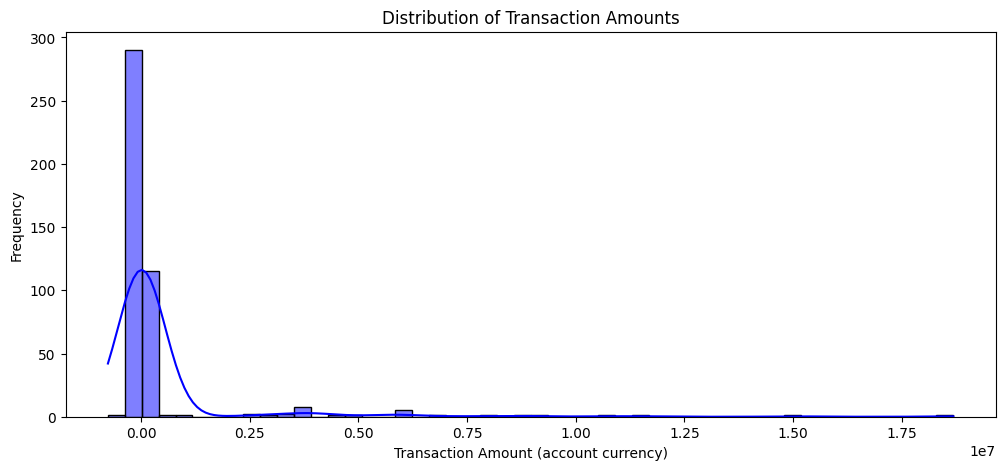

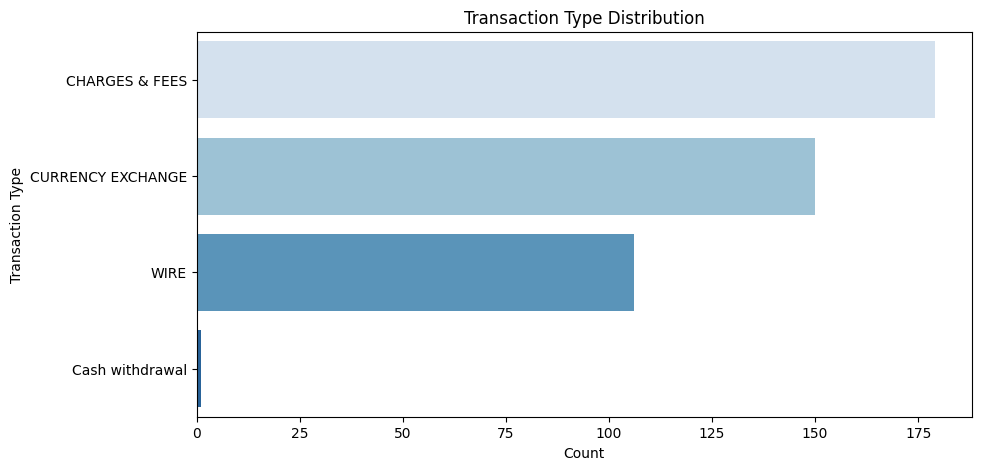

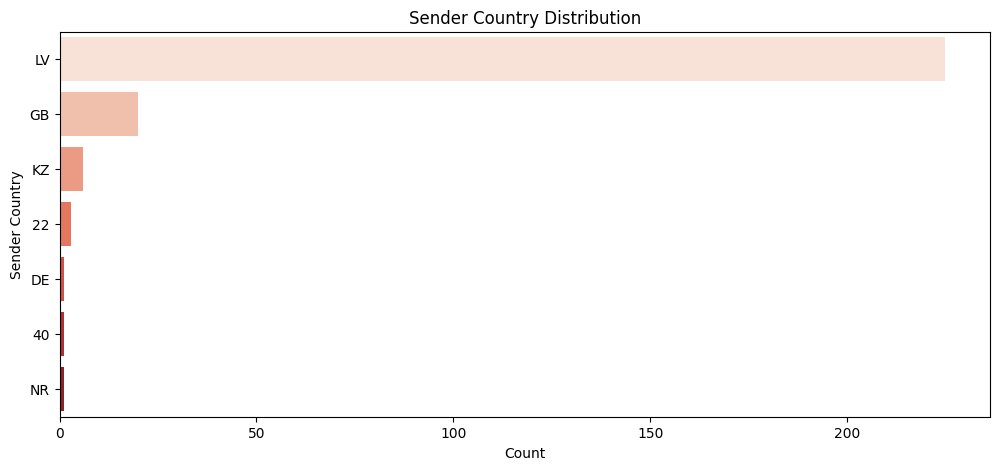

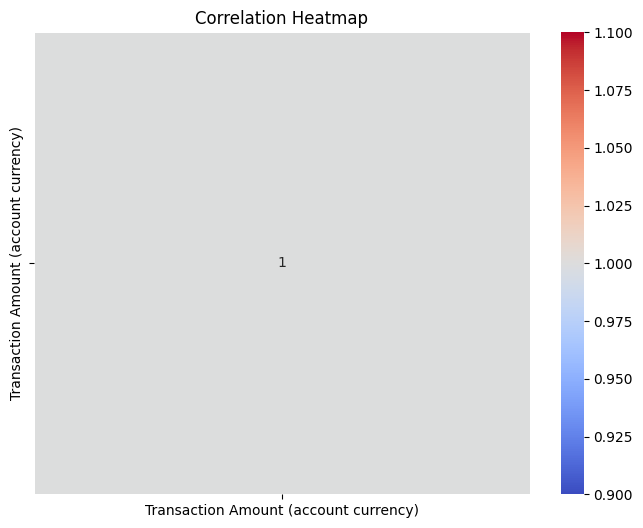

,Transaction Type (C/D),TRX_TYPE_1,Transaction Type,Transaction subtype,Transaction description,Purpose of payment,Bank name,Transaction Date,Transaction Amount (account currency),Currency,Name of beneficiary/originator,Beneficiary/originator account number,TRX_SEN_BANK_COUNTRY
0,De,currency exchange,CURRENCY EXCHANGE,CURRENCY EXCHANGE: intraclient,"currency exchange, No. 881, 7344.00 RUB => 120...",NaN,No Bank Found,2017-01-16,-7344.0,RUB,LEMURS CONTRACTS LP,LV61KKKK8686010354692,LV
1,Cr,currency exchange,CURRENCY EXCHANGE,CURRENCY EXCHANGE: intraclient,"currency exchange, No. 881, 7344.00 RUB => 120...",NaN,No Bank Found,2017-01-16,120.0,USD,LEMURS CONTRACTS LP,LV61KKKK8686010354692,LV
2,De,1556948.BANK Y.CURR.MNTH.FEE.20170131,CHARGES & FEES,CHARGES & FEES,"1556948.BANK Y.CURR.MNTH.FEE.20170131, account...",NaN,BANK Y.CURR.MNTH.FEE.20170131,2017-01-31,-55.0,EUR,NaN,NaN,NaN
3,Cr,intrabank payment,WIRE,WIRE: Intrabank,"intrabank payment, No. 30, LUSIS UNIVERSAL LI...",Titanium dioxide,bank payment,2017-02-02,158400.0,USD,LUSIS UNIVERSAL LIMITED,LV82KKKK8686010404754,LV
4,Cr,incoming payment,WIRE,WIRE: Interbank,"incoming payment, No. IVIH02029900248, OPTIMUS...",PAYMENT FOR THE TITAN DIOXIDE ACCORDING TO PER...,BANKA (RRRRLV2XXXX),2017-02-02,19860.0,USD,OPTIMUS TECHNOLOGY SUPPORT L.P. United Kingdom,LV64RRRR8686618806745,LV


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load real transaction data from Lemurs dataset
lemurs_file = "LEMURS CONTRACTS LP transactions.xlsx"
df_real = pd.read_excel(lemurs_file, sheet_name='Sheet1')

df_real.columns = df_real.columns.str.strip()

# Display dataset summary
summary_stats = {
    "Total Transactions": len(df_real),
    "Unique Transaction Types": df_real["Transaction Type"].nunique(),
    "Unique Currencies": df_real["Currency"].nunique(),
    "Unique Sender Countries": df_real["TRX_SEN_BANK_COUNTRY"].nunique(),
    "Transaction Amount Min": df_real["Transaction Amount (account currency)"].min(),
    "Transaction Amount Max": df_real["Transaction Amount (account currency)"].max(),
    "Transaction Amount Mean": df_real["Transaction Amount (account currency)"].mean(),
    "Transaction Amount Std": df_real["Transaction Amount (account currency)"].std(),
}
print(summary_stats)

# Plot transaction amount distribution
plt.figure(figsize=(12, 5))
sns.histplot(df_real["Transaction Amount (account currency)"], bins=50, kde=True, color='blue')
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount (account currency)")
plt.ylabel("Frequency")
plt.show()

# Plot transaction types count
plt.figure(figsize=(10, 5))
sns.countplot(y=df_real["Transaction Type"], order=df_real["Transaction Type"].value_counts().index, palette="Blues")
plt.title("Transaction Type Distribution")
plt.xlabel("Count")
plt.ylabel("Transaction Type")
plt.show()

# Plot sender country distribution
plt.figure(figsize=(12, 5))
sns.countplot(y=df_real["TRX_SEN_BANK_COUNTRY"], order=df_real["TRX_SEN_BANK_COUNTRY"].value_counts().index, palette="Reds")
plt.title("Sender Country Distribution")
plt.xlabel("Count")
plt.ylabel("Sender Country")
plt.show()

# Correlation matrix of numeric values
plt.figure(figsize=(8, 6))
sns.heatmap(df_real[["Transaction Amount (account currency)"]].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Display first few rows of dataset
df_real.head()

Analysis of Real Data:
1.   Total Transactions: 436
2.   Unique Transaction Types: 4
The dataset contains a limited number of transaction types.
3.   Unique Currencies: 3
The transactions occur in a small number of different currencies.
4.   Unique Sender Countries: 7
The transactions originate from 7 different countries.
5.   Transaction Amount Statistics:

Min: -759,475.2 (Possible refunds or reversals)
Max: 18,686,000.0 (Very large transactions)
Mean: 412,668.88
Standard Deviation: 1,796,482.04 (High variability)

# GaussianMixture - The fraud scenarios used in this dataset are:

* Rapid Currency Conversion – Immediate conversion of received funds to another currency.
* Daily/Monthly Turnover Thresholds – Turnover exceeded predefined monthly threshold.
* Circular Money Flow – Funds moving in a circular pattern between related accounts.
* Transit Payments – Funds transferred shortly after receipt.
* Transaction Structuring – Multiple transactions structured to avoid reporting limits.
* High-Risk Country Transactions – Significant transactions with high-risk jurisdictions.

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture

# Define fraud scenarios and transaction descriptions
fraud_scenarios = {
    "Rapid Currency Conversion": "Immediate conversion of received funds to another currency.",
    "Daily/Monthly Turnover Thresholds": "Turnover exceeded predefined monthly threshold.",
    "Circular Money Flow": "Funds moving in a circular pattern between related accounts.",
    "Transit Payments": "Funds transferred shortly after receipt.",
    "Transaction Structuring": "Multiple transactions structured to avoid reporting limits.",
    "High-Risk Country Transactions": "Significant transactions with high-risk jurisdictions."
}

# Load real transaction data from Lemurs dataset
lemurs_file = "LEMURS CONTRACTS LP transactions.xlsx"
df_lemurs = pd.read_excel(lemurs_file, sheet_name='Sheet1')

df_lemurs.columns = df_lemurs.columns.str.strip()

# Extract real sender names, receiver names, account numbers, transaction amounts, types, currencies, and countries
lemurs_senders = df_lemurs["Name of beneficiary/originator"].dropna().unique()
lemurs_receivers = df_lemurs["Transaction description"].dropna().unique()
lemurs_accounts = df_lemurs["Beneficiary/originator account number"].dropna().unique()
lemurs_transaction_types = df_lemurs["Transaction Type"].dropna()
lemurs_currencies = df_lemurs["Currency"].dropna().unique()
lemurs_sender_countries = df_lemurs["TRX_SEN_BANK_COUNTRY"].dropna().unique()
lemurs_amounts = df_lemurs["Transaction Amount (account currency)"].dropna().values

# Use Gaussian Mixture Model (GMM) instead of KDE for transaction amount sampling
num_components = min(3, len(lemurs_amounts))  # Use up to 3 components if possible
gmm = GaussianMixture(n_components=num_components, random_state=42)
gmm.fit(lemurs_amounts.reshape(-1, 1))

def sample_transaction_amount():
    sampled_value = gmm.sample(1)[0][0][0]
    noise = np.random.normal(loc=0, scale=max(abs(sampled_value) * 0.01, 5))
    final_value = max(-759475.2, min(18686000.0, sampled_value + noise))
    return round(final_value, 2)

# Compute transaction type probabilities to match real distribution
tx_type_probs = lemurs_transaction_types.value_counts(normalize=True).to_dict()

# Generate synthetic transaction dataset
num_samples = 10000  # Adjust for desired number of transactions
synthetic_data = []

for _ in range(num_samples):
    fraud_scenario = np.random.choice(list(fraud_scenarios.keys()))
    txn_type = np.random.choice(list(tx_type_probs.keys()), p=list(tx_type_probs.values()))  # Match real data proportions
    amount = sample_transaction_amount()  # Improved GMM Sampling
    currency = np.random.choice(lemurs_currencies)  # Use real dataset currencies
    sender_country = np.random.choice(lemurs_sender_countries)  # Use real dataset sender countries
    receiver_country = np.random.choice(lemurs_sender_countries)  # Assume receivers match senders
    description = fraud_scenario
    sender_name = np.random.choice(lemurs_senders)
    receiver_name = np.random.choice(lemurs_senders)
    sender_account = np.random.choice(lemurs_accounts)
    receiver_account = np.random.choice(lemurs_accounts)
    transaction_frequency = float(np.random.randint(1, 50))
    time_between_transactions = float(np.random.uniform(0.5, 48))
    rolling_avg_amount = float(np.random.uniform(5000, 100000))
    transaction_std_dev = float(np.random.uniform(1000, 50000))
    amount_ratio = float(amount / rolling_avg_amount)
    time_std_dev = float(np.random.uniform(0.1, 24))

    synthetic_data.append([fraud_scenario, txn_type, amount, currency, sender_country,
                           receiver_country, description, sender_name, receiver_name,
                           sender_account, receiver_account, transaction_frequency, time_between_transactions,
                           rolling_avg_amount, transaction_std_dev, amount_ratio, time_std_dev])

# Create DataFrame
columns = ["Risk Scenario", "Transaction Type", "Amount", "Currency", "Sender Country",
           "Receiver Country", "Transaction Description", "Sender Name", "Receiver Name",
           "Sender Account Number", "Receiver Account Number", "Transaction Frequency", "Time Between Transactions",
           "Rolling Avg Amount", "Transaction Std Dev", "Amount Ratio", "Time Std Dev"]
df_synthetic = pd.DataFrame(synthetic_data, columns=columns)

# Ensure only numeric features are processed for scaling and PCA
numeric_features = ["Amount", "Transaction Frequency", "Time Between Transactions", "Rolling Avg Amount", "Transaction Std Dev", "Amount Ratio", "Time Std Dev"]

df_synthetic[numeric_features] = df_synthetic[numeric_features].apply(pd.to_numeric, errors='coerce')

df_synthetic = df_synthetic.dropna(subset=numeric_features)

# Remove highly correlated features to improve PCA feasibility
correlation_matrix = df_synthetic[numeric_features].corr().abs()
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
highly_correlated_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)]
df_synthetic = df_synthetic.drop(columns=highly_correlated_features)

# Apply MinMax Scaling for PCA only after verifying distributions
scaler = MinMaxScaler()
df_synthetic[numeric_features] = scaler.fit_transform(df_synthetic[numeric_features])

# Save synthetic transactions to CSV
output_file = "synthetic_transactions.csv"
df_synthetic.to_csv(output_file, index=False)

# Display generated synthetic transactions
df_synthetic.head()


,Risk Scenario,Transaction Type,Amount,Currency,Sender Country,Receiver Country,Transaction Description,Sender Name,Receiver Name,Sender Account Number,Receiver Account Number,Transaction Frequency,Time Between Transactions,Rolling Avg Amount,Transaction Std Dev,Amount Ratio,Time Std Dev
0,Transaction Structuring,WIRE,0.516770,EUR,GB,LV,Transaction Structuring,GENERAL INTER LP,"CHEMICALS INT GMBH Leverkusen, DE",222222222222222,LV82KKKK8686010404754,0.583333,0.117713,0.825300,0.084756,0.989031,0.422263
1,Circular Money Flow,CHARGES & FEES,0.402259,RUB,KZ,40,Circular Money Flow,BUSINESS SOLUTIONS LP,"ТОО GK CHIM ALMATY, Kazakhstan",KZ1111111111,LV91 KKKK 8686 0103 8635 6,0.062500,0.816144,0.311486,0.409915,0.900135,0.722109
2,Circular Money Flow,WIRE,0.269887,RUB,DE,NR,Circular Money Flow,"ТОО GK CHIM ALMATY, Kazakhstan","CHEMICALS INT GMBH Leverkusen, DE",LV67 KKKK 0001 1401 0349 6,LV64RRRR8686618806745,0.729167,0.711217,0.153639,0.777049,0.781666,0.823588
3,Circular Money Flow,WIRE,0.383531,USD,DE,22,Circular Money Flow,LEMURS CONTRACTS LP,SILVEX TECHNOLOGY LTD.,NRA150000000,LV65 KKKK 8686 0103 8439 9,0.375000,0.122744,0.543907,0.454246,0.958750,0.909697
4,Transit Payments,CURRENCY EXCHANGE,0.463101,USD,LV,40,Transit Payments,Torrvec LIMITED,TOLPANTA CORPORATION L.P.,222222222222222,LV77 KKKK 8686 0103 7933 3,0.708333,0.843516,0.511263,0.884631,0.954085,0.860606


# GAN - The fraud scenarios used in this dataset are:

* Rapid Currency Conversion – Immediate conversion of received funds to another currency.
* Daily/Monthly Turnover Thresholds – Turnover exceeded predefined monthly threshold.
* Circular Money Flow – Funds moving in a circular pattern between related accounts.
* Transit Payments – Funds transferred shortly after receipt.
* Transaction Structuring – Multiple transactions structured to avoid reporting limits.
* High-Risk Country Transactions – Significant transactions with high-risk jurisdictions.

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam

# Seeds
np.random.seed(42)
tf.random.set_seed(42)

# Fraud types
fraud_scenarios = {
    "Rapid Currency Conversion": "Immediate conversion of received funds to another currency.",
    "Daily/Monthly Turnover Thresholds": "Turnover exceeded predefined monthly threshold.",
    "Circular Money Flow": "Funds moving in a circular pattern between related accounts.",
    "Transit Payments": "Funds transferred shortly after receipt.",
    "Transaction Structuring": "Multiple transactions structured to avoid reporting limits.",
    "High-Risk Country Transactions": "Significant transactions with high-risk jurisdictions."
}

# Load data
lemurs_file = "LEMURS CONTRACTS LP transactions.xlsx"
df_lemurs = pd.read_excel(lemurs_file, sheet_name='Sheet1')
df_lemurs.columns = df_lemurs.columns.str.strip()

# Real fields
lemurs_senders = df_lemurs["Name of beneficiary/originator"].dropna().unique()
lemurs_receivers = df_lemurs["Transaction description"].dropna().unique()
lemurs_accounts = df_lemurs["Beneficiary/originator account number"].dropna().unique()
lemurs_transaction_types = df_lemurs["Transaction Type"].dropna()
lemurs_currencies = df_lemurs["Currency"].dropna().unique()
lemurs_sender_countries = df_lemurs["TRX_SEN_BANK_COUNTRY"].dropna().unique()
lemurs_amounts = df_lemurs["Transaction Amount (account currency)"].dropna().values

# Scale amounts
amounts = lemurs_amounts.reshape(-1, 1)
amount_scaler = MinMaxScaler(feature_range=(-1, 1))
amounts_scaled = amount_scaler.fit_transform(amounts)

latent_dim = 16  # latent size

# Discriminator
discriminator = Sequential([
    Dense(32, input_shape=(1,)),
    LeakyReLU(alpha=0.2),
    Dense(32),
    LeakyReLU(alpha=0.2),
    Dense(1, activation="sigmoid")
])
discriminator.compile(optimizer=Adam(0.0002, 0.5), loss="binary_crossentropy")

# Generator
generator = Sequential([
    Dense(32, input_shape=(latent_dim,)),
    LeakyReLU(alpha=0.2),
    Dense(32),
    LeakyReLU(alpha=0.2),
    Dense(1, activation="tanh")
])

# GAN model
discriminator.trainable = False
gan = Sequential([generator, discriminator])
gan.compile(optimizer=Adam(0.0002, 0.5), loss="binary_crossentropy")

# Train GAN
epochs = 2000
batch_size = 64

for epoch in range(epochs):
    # Real
    idx = np.random.randint(0, amounts_scaled.shape[0], batch_size)
    real_samples = amounts_scaled[idx]

    # Fake
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    gen_samples = generator.predict(noise, verbose=0)

    real_y = np.ones((batch_size, 1))
    fake_y = np.zeros((batch_size, 1))

    d_loss_real = discriminator.train_on_batch(real_samples, real_y)
    d_loss_fake = discriminator.train_on_batch(gen_samples, fake_y)

    # Train G
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    valid_y = np.ones((batch_size, 1))
    g_loss = gan.train_on_batch(noise, valid_y)

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}/{epochs} | d_real: {d_loss_real:.4f}, "
              f"d_fake: {d_loss_fake:.4f}, g: {g_loss:.4f}")

# Sample amount
def sample_transaction_amount():
    noise = np.random.normal(0, 1, (1, latent_dim))
    gen_scaled = generator.predict(noise, verbose=0)
    gen_amount = amount_scaler.inverse_transform(gen_scaled)[0][0]

    noise_add = np.random.normal(loc=0, scale=max(abs(gen_amount) * 0.01, 5))
    final_value = max(-759475.2, min(18686000.0, gen_amount + noise_add))
    return round(float(final_value), 2)

# Tx type probs
tx_type_probs = lemurs_transaction_types.value_counts(normalize=True).to_dict()

# Generate data
num_samples = 10000
synthetic_data = []

for _ in range(num_samples):
    fraud_scenario = np.random.choice(list(fraud_scenarios.keys()))
    txn_type = np.random.choice(list(tx_type_probs.keys()), p=list(tx_type_probs.values()))
    amount = sample_transaction_amount()
    currency = np.random.choice(lemurs_currencies)
    sender_country = np.random.choice(lemurs_sender_countries)
    receiver_country = np.random.choice(lemurs_sender_countries)
    description = fraud_scenario
    sender_name = np.random.choice(lemurs_senders)
    receiver_name = np.random.choice(lemurs_senders)
    sender_account = np.random.choice(lemurs_accounts)
    receiver_account = np.random.choice(lemurs_accounts)
    transaction_frequency = float(np.random.randint(1, 50))
    time_between_transactions = float(np.random.uniform(0.5, 48))
    rolling_avg_amount = float(np.random.uniform(5000, 100000))
    transaction_std_dev = float(np.random.uniform(1000, 50000))
    amount_ratio = float(amount / rolling_avg_amount)
    time_std_dev = float(np.random.uniform(0.1, 24))

    synthetic_data.append([
        fraud_scenario, txn_type, amount, currency, sender_country,
        receiver_country, description, sender_name, receiver_name,
        sender_account, receiver_account, transaction_frequency,
        time_between_transactions, rolling_avg_amount,
        transaction_std_dev, amount_ratio, time_std_dev
    ])

# DataFrame
columns = [
    "Risk Scenario", "Transaction Type", "Amount", "Currency", "Sender Country",
    "Receiver Country", "Transaction Description", "Sender Name", "Receiver Name",
    "Sender Account Number", "Receiver Account Number", "Transaction Frequency",
    "Time Between Transactions", "Rolling Avg Amount", "Transaction Std Dev",
    "Amount Ratio", "Time Std Dev"
]
df_synthetic = pd.DataFrame(synthetic_data, columns=columns)

# Numeric only
numeric_features = [
    "Amount", "Transaction Frequency", "Time Between Transactions",
    "Rolling Avg Amount", "Transaction Std Dev", "Amount Ratio", "Time Std Dev"
]

df_synthetic[numeric_features] = df_synthetic[numeric_features].apply(
    pd.to_numeric, errors='coerce'
)
df_synthetic = df_synthetic.dropna(subset=numeric_features)

# Correlation filter
correlation_matrix = df_synthetic[numeric_features].corr().abs()
print("correlation matrix (|ρ|):")
print(correlation_matrix.round(3))
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
highly_correlated_features = [
    column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)
]
print("\nАeatures с |ρ| > 0.95 and removed from the set:")
print(highly_correlated_features)
df_synthetic = df_synthetic.drop(columns=highly_correlated_features)

# Scale numeric
numeric_features_final = [c for c in numeric_features if c in df_synthetic.columns]
scaler = MinMaxScaler()
df_synthetic[numeric_features_final] = scaler.fit_transform(
    df_synthetic[numeric_features_final]
)

# Save CSV
output_file = "synthetic_transactions.csv"
df_synthetic.to_csv(output_file, index=False)

df_synthetic.head()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 500/2000 | d_real: 0.7664, d_fake: 0.7663, g: 0.7099
Epoch 1000/2000 | d_real: 0.7688, d_fake: 0.7688, g: 0.7047
Epoch 1500/2000 | d_real: 0.7699, d_fake: 0.7699, g: 0.7023
Epoch 2000/2000 | d_real: 0.7706, d_fake: 0.7706, g: 0.7008
correlation matrix (|ρ|):
                           Amount  Transaction Frequency  \
Amount                      1.000                  0.007   
Transaction Frequency       0.007                  1.000   
Time Between Transactions   0.006                  0.011   
Rolling Avg Amount          0.006                  0.001   
Transaction Std Dev         0.017                  0.008   
Amount Ratio                0.034                  0.000   
Time Std Dev                0.004                  0.006   

                           Time Between Transactions  Rolling Avg Amount  \
Amount                                         0.006               0.006   
Transaction Frequency                          0.011               0.001   
Time Between Transactions 

,Risk Scenario,Transaction Type,Amount,Currency,Sender Country,Receiver Country,Transaction Description,Sender Name,Receiver Name,Sender Account Number,Receiver Account Number,Transaction Frequency,Time Between Transactions,Rolling Avg Amount,Transaction Std Dev,Amount Ratio,Time Std Dev
0,Circular Money Flow,WIRE,0.655675,USD,NR,22,Circular Money Flow,"MAX FAMOUS INTERNATIONAL TRADING CO., LIMITED,...","Arcelor NAVAHO JSC 1, NAVAHO, KARAGANDA AREA, ...",KZ1111111111,LV77 KKKK 8686 0103 7933 3,0.687500,0.773789,0.161231,0.519462,0.211437,0.629298
1,High-Risk Country Transactions,CURRENCY EXCHANGE,0.481766,RUB,NR,LV,High-Risk Country Transactions,LEMURS CONTRACTS LP,"GENIUS AURA LIMITED, TAIWAN",222222222222222,KZ1111111111,0.937500,0.179912,0.116692,0.337821,0.256257,0.293144
2,Transit Payments,CHARGES & FEES,0.547716,USD,22,LV,Transit Payments,TLV NORD PTE. LTD.,"ТОО GK CHIM ALMATY, Kazakhstan",GB00000000,LV95 KKKK 8686 0103 8366 5,0.291667,0.818485,0.287011,0.162639,0.110337,0.964569
3,High-Risk Country Transactions,CURRENCY EXCHANGE,0.510084,RUB,22,NR,High-Risk Country Transactions,Torrvec LIMITED,LUSIS UNIVERSAL LIMITED,NRA150000000,LV67 KKKK 0001 1401 0349 6,0.354167,0.302950,0.233600,0.677435,0.136137,0.304035
4,Daily/Monthly Turnover Thresholds,CHARGES & FEES,0.569338,RUB,LV,40,Daily/Monthly Turnover Thresholds,Torrvec LIMITED,TRADING HOUSE OF VROOM AVTO LLC,LV65 KKKK 8686 0103 8439 9,LV36KKKK8686010386570,0.437500,0.588441,0.654358,0.503331,0.031256,0.939929


# Comparison - Real VS GaussianMixture
* Kolmogorov-Smirnov (KS) Test – Checks similarity of transaction amounts.
* Chi-Square Test – Compares categorical distributions (transaction types).
* Data Distribution Analysis – Visualizes distributions with histograms & boxplots.
* PCA (Principal Component Analysis) – Plots real vs. synthetic data in 2D space.

KS Test Statistic: 0.6605504587155964, P-Value: 2.1820182972036132e-178
Chi-Square Test Statistic: 0.00015456197426654003, P-Value: 0.9999994889626365


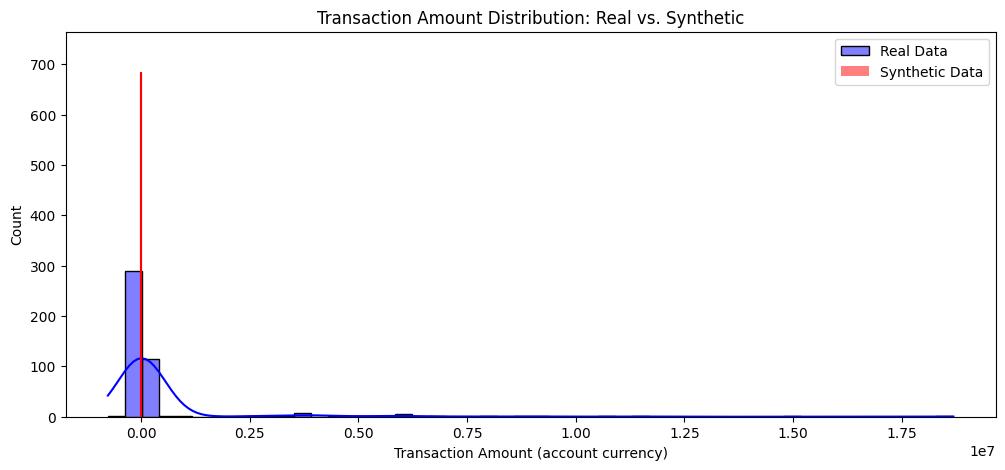

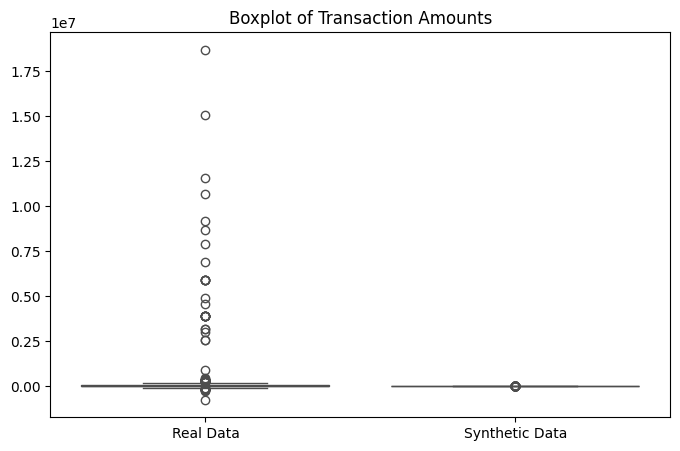

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load real and synthetic data
real_data_file = "LEMURS CONTRACTS LP transactions.xlsx"
synthetic_data_file = "synthetic_transactions.csv"

df_real = pd.read_excel(real_data_file, sheet_name='Sheet1')
df_synthetic = pd.read_csv(synthetic_data_file)

# Standardize column names
df_real.columns = df_real.columns.str.strip()
df_synthetic.columns = df_synthetic.columns.str.strip()

# Select relevant columns
real_amounts = df_real["Transaction Amount (account currency)"].dropna()
synthetic_amounts = df_synthetic["Amount"].dropna()

# 1. Kolmogorov-Smirnov (KS) Test for transaction amounts
ks_stat, ks_p_value = stats.ks_2samp(real_amounts, synthetic_amounts)
print(f"KS Test Statistic: {ks_stat}, P-Value: {ks_p_value}")

# 2. Chi-Square Test for categorical distributions (Transaction Type)
real_types = df_real["Transaction Type"].dropna().value_counts()
synthetic_types = df_synthetic["Transaction Type"].dropna().value_counts()
common_types = real_types.index.intersection(synthetic_types.index)

df_comparison = pd.DataFrame({
    "Real": real_types[common_types],
    "Synthetic": synthetic_types[common_types]
}).fillna(0)

# Normalize frequencies to match sums for chi-square test
df_comparison["Real"] = df_comparison["Real"] / df_comparison["Real"].sum()
df_comparison["Synthetic"] = df_comparison["Synthetic"] / df_comparison["Synthetic"].sum()

chi2_stat, chi2_p_value = stats.chisquare(df_comparison["Synthetic"] * df_comparison["Real"].sum(),
                                          df_comparison["Real"] * df_comparison["Real"].sum())
print(f"Chi-Square Test Statistic: {chi2_stat}, P-Value: {chi2_p_value}")

# 3. Data Distribution Analysis (Histograms & Boxplots)
plt.figure(figsize=(12, 5))
sns.histplot(real_amounts, color='blue', label='Real Data', kde=True, bins=50)
sns.histplot(synthetic_amounts, color='red', label='Synthetic Data', kde=True, bins=50)
plt.legend()
plt.title("Transaction Amount Distribution: Real vs. Synthetic")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=[real_amounts, synthetic_amounts], palette=["blue", "red"])
plt.xticks([0, 1], ["Real Data", "Synthetic Data"])
plt.title("Boxplot of Transaction Amounts")
plt.show()

# 4. PCA Analysis for Real vs. Synthetic Data
numeric_features = ["Amount", "Transaction Frequency", "Time Between Transactions", "Rolling Avg Amount", "Transaction Std Dev", "Amount Ratio", "Time Std Dev"]

# Ensure required numeric columns exist in both datasets
real_numeric_features = [feature for feature in numeric_features if feature in df_real.columns]
synthetic_numeric_features = [feature for feature in numeric_features if feature in df_synthetic.columns]

if len(real_numeric_features) < 2 or len(synthetic_numeric_features) < 2:
    print("Warning: Not enough features for PCA. Skipping PCA analysis.")
else:
    real_pca_data = df_real[real_numeric_features].dropna()
    synthetic_pca_data = df_synthetic[synthetic_numeric_features].dropna()

    # Standardize numeric data before PCA
    scaler = StandardScaler()
    real_pca_data = scaler.fit_transform(real_pca_data)
    synthetic_pca_data = scaler.transform(synthetic_pca_data)

    pca = PCA(n_components=2)
    pca_real = pca.fit_transform(real_pca_data)
    pca_synthetic = pca.transform(synthetic_pca_data)

    plt.figure(figsize=(10, 6))
    plt.scatter(pca_real[:, 0], pca_real[:, 1], alpha=0.5, label="Real Data", color="blue")
    plt.scatter(pca_synthetic[:, 0], pca_synthetic[:, 1], alpha=0.5, label="Synthetic Data", color="red")
    plt.legend()
    plt.title("PCA Analysis of Real vs. Synthetic Data")
    plt.show()


# Comparison - Real VS GAN
* Kolmogorov-Smirnov (KS) Test – Checks similarity of transaction amounts.
* Chi-Square Test – Compares categorical distributions (transaction types).
* Data Distribution Analysis – Visualizes distributions with histograms & boxplots.
* PCA (Principal Component Analysis) – Plots real vs. synthetic data in 2D space.

KS Test Statistic: 0.6605504587155964, P-Value: 2.1820182972036132e-178
Chi-Square Test Statistic: 9.582377729524654e-05, P-Value: 0.9999997505311922


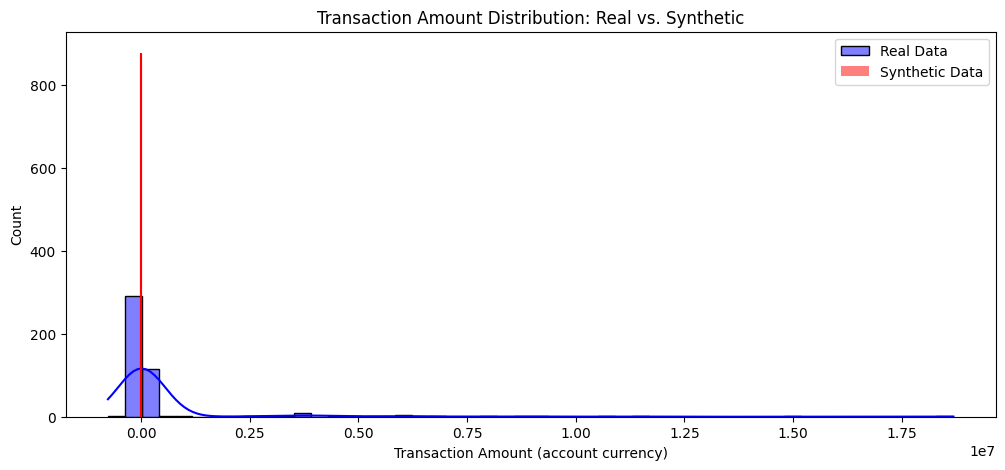

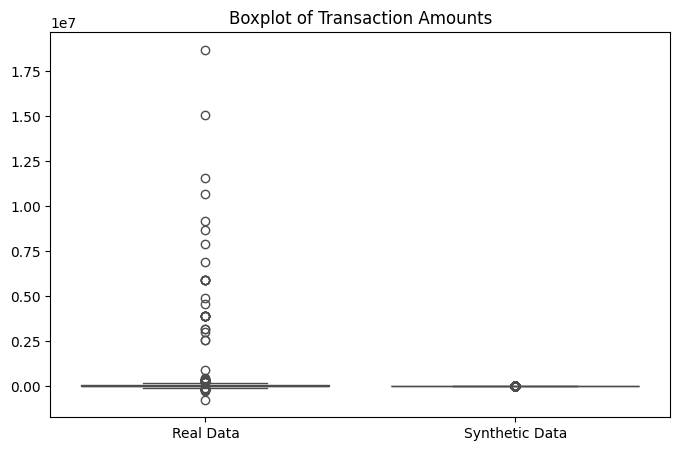

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load real and synthetic data
real_data_file = "LEMURS CONTRACTS LP transactions.xlsx"
synthetic_data_file = "synthetic_transactions.csv"

df_real = pd.read_excel(real_data_file, sheet_name='Sheet1')
df_synthetic = pd.read_csv(synthetic_data_file)

# Standardize column names
df_real.columns = df_real.columns.str.strip()
df_synthetic.columns = df_synthetic.columns.str.strip()

# Select relevant columns
real_amounts = df_real["Transaction Amount (account currency)"].dropna()
synthetic_amounts = df_synthetic["Amount"].dropna()

# 1. Kolmogorov-Smirnov (KS) Test for transaction amounts
ks_stat, ks_p_value = stats.ks_2samp(real_amounts, synthetic_amounts)
print(f"KS Test Statistic: {ks_stat}, P-Value: {ks_p_value}")

# 2. Chi-Square Test for categorical distributions (Transaction Type)
real_types = df_real["Transaction Type"].dropna().value_counts()
synthetic_types = df_synthetic["Transaction Type"].dropna().value_counts()
common_types = real_types.index.intersection(synthetic_types.index)

df_comparison = pd.DataFrame({
    "Real": real_types[common_types],
    "Synthetic": synthetic_types[common_types]
}).fillna(0)

# Normalize frequencies to match sums for chi-square test
df_comparison["Real"] = df_comparison["Real"] / df_comparison["Real"].sum()
df_comparison["Synthetic"] = df_comparison["Synthetic"] / df_comparison["Synthetic"].sum()

chi2_stat, chi2_p_value = stats.chisquare(df_comparison["Synthetic"] * df_comparison["Real"].sum(),
                                          df_comparison["Real"] * df_comparison["Real"].sum())
print(f"Chi-Square Test Statistic: {chi2_stat}, P-Value: {chi2_p_value}")

# 3. Data Distribution Analysis (Histograms & Boxplots)
plt.figure(figsize=(12, 5))
sns.histplot(real_amounts, color='blue', label='Real Data', kde=True, bins=50)
sns.histplot(synthetic_amounts, color='red', label='Synthetic Data', kde=True, bins=50)
plt.legend()
plt.title("Transaction Amount Distribution: Real vs. Synthetic")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=[real_amounts, synthetic_amounts], palette=["blue", "red"])
plt.xticks([0, 1], ["Real Data", "Synthetic Data"])
plt.title("Boxplot of Transaction Amounts")
plt.show()

# 4. PCA Analysis for Real vs. Synthetic Data
numeric_features = ["Amount", "Transaction Frequency", "Time Between Transactions", "Rolling Avg Amount", "Transaction Std Dev", "Amount Ratio", "Time Std Dev"]

# Ensure required numeric columns exist in both datasets
real_numeric_features = [feature for feature in numeric_features if feature in df_real.columns]
synthetic_numeric_features = [feature for feature in numeric_features if feature in df_synthetic.columns]

if len(real_numeric_features) < 2 or len(synthetic_numeric_features) < 2:
    print("Warning: Not enough features for PCA. Skipping PCA analysis.")
else:
    real_pca_data = df_real[real_numeric_features].dropna()
    synthetic_pca_data = df_synthetic[synthetic_numeric_features].dropna()

    # Standardize numeric data before PCA
    scaler = StandardScaler()
    real_pca_data = scaler.fit_transform(real_pca_data)
    synthetic_pca_data = scaler.transform(synthetic_pca_data)

    pca = PCA(n_components=2)
    pca_real = pca.fit_transform(real_pca_data)
    pca_synthetic = pca.transform(synthetic_pca_data)

    plt.figure(figsize=(10, 6))
    plt.scatter(pca_real[:, 0], pca_real[:, 1], alpha=0.5, label="Real Data", color="blue")
    plt.scatter(pca_synthetic[:, 0], pca_synthetic[:, 1], alpha=0.5, label="Synthetic Data", color="red")
    plt.legend()
    plt.title("PCA Analysis of Real vs. Synthetic Data")
    plt.show()

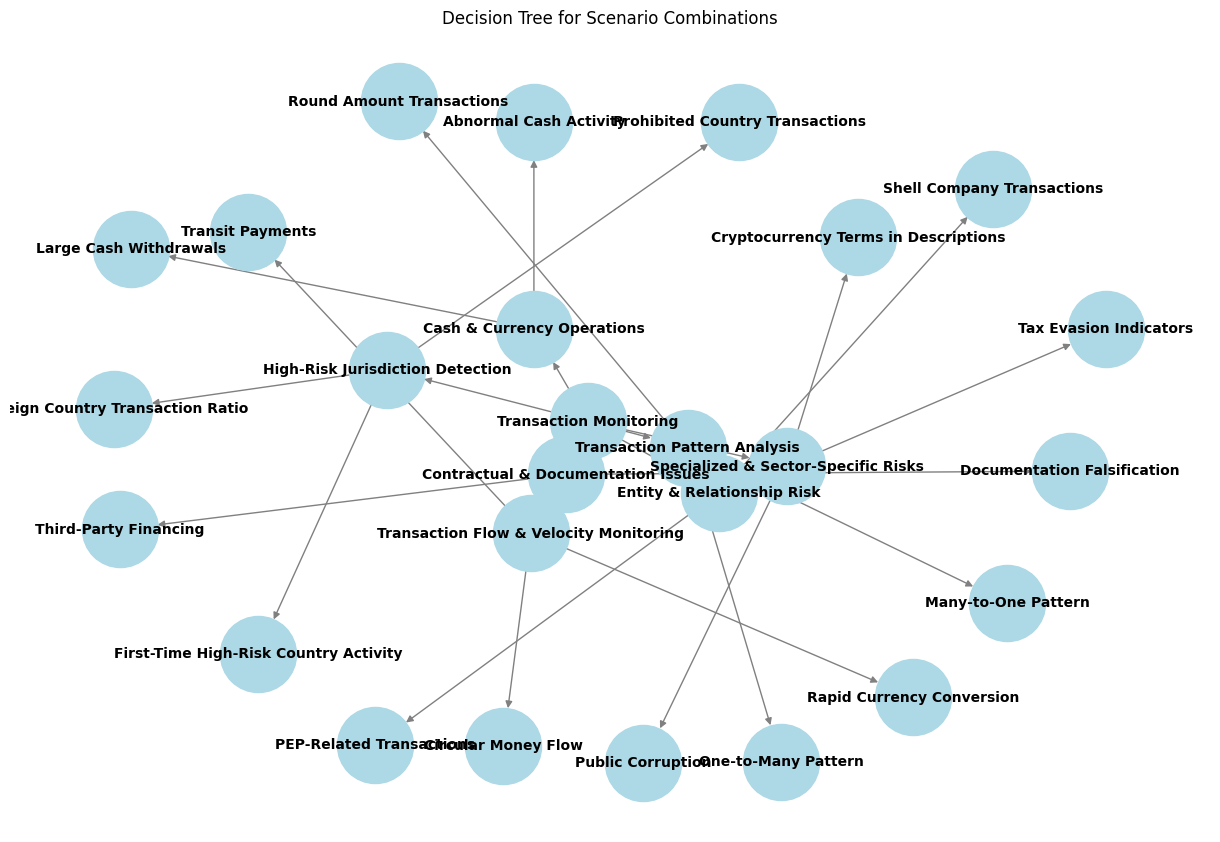

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_decision_tree():
    G = nx.DiGraph()

    # Define nodes
    categories = {
        "Transaction Monitoring": [
            "Transaction Flow & Velocity Monitoring",
            "High-Risk Jurisdiction Detection",
            "Transaction Pattern Analysis",
            "Entity & Relationship Risk",
            "Contractual & Documentation Issues",
            "Cash & Currency Operations",
            "Specialized & Sector-Specific Risks"
        ],
        "Transaction Flow & Velocity Monitoring": [
            "Transit Payments", "Circular Money Flow", "Rapid Currency Conversion"
        ],
        "High-Risk Jurisdiction Detection": [
            "First-Time High-Risk Country Activity", "Prohibited Country Transactions", "Foreign Country Transaction Ratio"
        ],
        "Transaction Pattern Analysis": [
            "One-to-Many Pattern", "Many-to-One Pattern", "Round Amount Transactions"
        ],
        "Entity & Relationship Risk": [
            "Shell Company Transactions", "PEP-Related Transactions"
        ],
        "Contractual & Documentation Issues": [
            "Documentation Falsification", "Third-Party Financing"
        ],
        "Cash & Currency Operations": [
            "Large Cash Withdrawals", "Abnormal Cash Activity"
        ],
        "Specialized & Sector-Specific Risks": [
            "Cryptocurrency Terms in Descriptions", "Public Corruption", "Tax Evasion Indicators"
        ]
    }

    # Add edges
    for parent, children in categories.items():
        for child in children:
            G.add_edge(parent, child)

    # Draw the graph
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.7, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", edge_color="gray", font_size=10, font_weight="bold")
    plt.title("Decision Tree for Scenario Combinations")
    plt.show()

# Call function to display the tree
draw_decision_tree()


In [ ]:
import itertools
from collections import defaultdict

# Full scenario list (1-58)
SCENARIOS = {
    1: "Transit Payments ",
    2: "Daily/Monthly Turnover Thresholds",
    3: "Circular Money Flow",
    4: "Reserved/Undefined Scenario",
    5: "Rapid Currency Conversion",
    6: "Transaction Structuring",
    7: "Sudden Activity After Dormancy",
    8: "Newly Incorporated Entity High Volume",
    9: "Unusual Transaction Speed",
    10: "Identical Transaction Size",
    11: "Undeclared Country Transactions",
    12: "High-Risk Country Daily/Monthly Transactions",
    13: "Very High-Risk Country Transactions",
    14: "First-Time High-Risk Country Activity",
    15: "Prohibited Country Transactions",
    16: "Foreign Country Transaction Ratio",
    17: "High-Risk IP Address Transactions",
    18: "Restricted Country Currency",
    19: "Balanced Flow Analysis",
    20: "One-to-Many Pattern",
    21: "Many-to-One Pattern",
    22: "Round Amount Transactions",
    23: "Historical Transaction Spike",
    24: "Unusual Increase in Turnover",
    25: "Foreign Currency First-Time Usage",
    26: "Shell Company Transactions",
    27: "PEP-Related Transactions",
    28: "Same UBO but Different Representative",
    29: "Same Representative but Different UBO",
    30: "Direct UBO/Representative Transactions",
    31: "NGO Transaction Monitoring",
    32: "Multiple High-Risk Transactions",
    33: "Client Accompanied by Third Parties",
    34: "Insufficient Transaction Description",
    35: "Minimal Payment Details",
    36: "Documentation Falsification",
    37: "Repetitive/Missing Reference Numbers",
    38: "Inconsistent Business Activities",
    39: "Fictitious Loan Transactions",
    40: "Third-Party Financing",
    41: "Large Cash Withdrawals",
    42: "Abnormal Cash Activity",
    43: "Cash Withdrawal Pattern Changes",
    44: "Multiple Currency Transactions",
    45: "Cryptocurrency Terms in Descriptions",
    46: "Cryptocurrency-Related Counterparties",
    47: "Cross-Border Large Transfers",
    48: "Fraud Indicator Terms",
    49: "Public Negative Information",
    50: "Economic Simulation",
    51: "Unusual Routing",
    52: "Complex Multi-Jurisdictional Structure",
    53: "NGO Activity Inconsistency",
    54: "High-Risk Industry Terms",
    55: "Autonomous Money Laundering (ANIL)",
    56: "Professional Money Laundering (APRO)",
    57: "Public Corruption (AVAL)",
    58: "Tax Evasion Indicators (BVID)"
}

# Category mapping
CATEGORIES = {
    "Transaction Flow": list(range(1, 11)),
    "Jurisdiction": list(range(11, 19)),
    "Pattern Analysis": list(range(19, 26)),
    "Entity Risk": list(range(26, 34)),
    "Documentation": list(range(34, 41)),
    "Cash": list(range(41, 45)),
    "Crypto": [45, 46],
    "Sector-Specific": list(range(53, 59))
}

# Risk weights (scale 0-1)
RISK_WEIGHTS = {
    12: 0.9, 13: 0.95, 15: 1.0,   # High-risk countries
    27: 0.85,                     # PEPs
    45: 0.8, 46: 0.8,             # Crypto
    41: 0.75, 42: 0.7,            # Cash
    3: 0.7, 6: 0.65,              # Layering
    26: 0.8, 28: 0.75,            # Shell companies
    58: 0.85                      # Tax evasion
}

# Exclusion rules (key excludes values)
EXCLUSIONS = {
    15: [12, 13, 14],  # Prohibited vs high-risk countries
    27: [33],          # PEPs vs third parties
    41: [44],          # Cash vs multi-currency
    45: [18]           # Crypto vs restricted currencies
}

# Known typology patterns
TYPOLOGIES = {
    "Layering": [3, 5, 6, 51],
    "Shell Networks": [26, 28, 34],
    "Trade Misinvoicing": [58, 22, 36],
    "PEP Abuses": [27, 11, 49],
    "Crypto Obfuscation": [45, 46, 17]
}

class ScenarioCombiner:
    def __init__(self):
        self.scenario_cats = self._map_scenario_categories()

    def _map_scenario_categories(self):
        mapping = {}
        for cat, scenarios in CATEGORIES.items():
            for s in scenarios:
                mapping[s] = cat
        return mapping

    def validate_combination(self, combo):
        """Apply all validation rules to a combination"""
        if not 3 <= len(combo) <= 5:
            return False

        # Category diversity
        cats = {self.scenario_cats.get(s, 'Other') for s in combo}
        if len(cats) < 2:
            return False

        # Exclusion rules
        for s in combo:
            if s in EXCLUSIONS:
                if any(excluded in combo for excluded in EXCLUSIONS[s]):
                    return False

        # Risk threshold (min 2.0)
        risk = sum(RISK_WEIGHTS.get(s, 0.5) for s in combo)
        if risk < 2.0:
            return False

        return True

    def generate_combinations(self, base_scenarios=None, max_results=50):
        """Generate valid combinations using heuristic sampling"""
        # Start with known typologies
        seed_combos = list(TYPOLOGIES.values())

        # Expand with cross-category links
        expanded = []
        for combo in seed_combos:
            for s in SCENARIOS:
                if s not in combo and self.validate_combination(combo + [s]):
                    expanded.append(combo + [s])

        # Filter and deduplicate
        valid = []
        seen = set()
        for combo in seed_combos + expanded:
            key = tuple(sorted(combo))
            if key not in seen:
                seen.add(key)
                if self.validate_combination(combo):
                    valid.append(combo)

        return valid[:max_results]

# Example usage
if __name__ == "__main__":
    combiner = ScenarioCombiner()
    combinations = combiner.generate_combinations()

    print(f"Generated {len(combinations)} valid combinations:")
    for i, combo in enumerate(combinations[:5], 1):
        print(f"\nCombination {i}:")
        for s in combo:
            print(f"{s}: {SCENARIOS[s]}")

Generated 50 valid combinations:

Combination 1:
3: Circular Money Flow
5: Rapid Currency Conversion
6: Transaction Structuring
51: Unusual Routing

Combination 2:
26: Shell Company Transactions
28: Same UBO but Different Representative
34: Insufficient Transaction Description

Combination 3:
45: Cryptocurrency Terms in Descriptions
46: Cryptocurrency-Related Counterparties
17: High-Risk IP Address Transactions

Combination 4:
3: Circular Money Flow
5: Rapid Currency Conversion
6: Transaction Structuring
51: Unusual Routing
1: Transit Payments 

Combination 5:
3: Circular Money Flow
5: Rapid Currency Conversion
6: Transaction Structuring
51: Unusual Routing
2: Daily/Monthly Turnover Thresholds


# Sythetic data v1

In [ ]:
import pandas as pd
import numpy as np
import random
import math
from datetime import datetime, timedelta

# Define date range constants
start_date = datetime(2023, 1, 1)
end_date = datetime(2023, 12, 31)

# List of common business words and industry terms
business_types = ['Holdings', 'Investments', 'Trading', 'Capital', 'Ventures', 'Partners', 'Group', 'Solutions', 'International', 'Global']
industries = ['Tech', 'Finance', 'Trade', 'Consulting', 'Services', 'Logistics', 'Maritime', 'Energy', 'Resources', 'Development']
locations = ['Asia', 'Pacific', 'Atlantic', 'European', 'Eastern', 'Western', 'Northern', 'Southern', 'Continental', 'International']
suffixes = ['Ltd', 'LLC', 'Inc', 'Corp', 'Limited', 'S.A.', 'GmbH', 'Pte Ltd', 'B.V.', 'AG']
prefixes = ['Alpha', 'Beta', 'Delta', 'Omega', 'Prime', 'Elite', 'Summit', 'Apex', 'Crown', 'Royal']

# Load offshore companies dataset
try:
    shell_companies_file = 'Offshore Leaks-entities.csv'
    df_shell_companies = pd.read_csv(shell_companies_file, usecols=['original_name'], low_memory=False)
    known_shell_companies = set(df_shell_companies['original_name'].dropna().unique().tolist())
    print(f"Loaded {len(known_shell_companies)} companies from Offshore Leaks database")
except FileNotFoundError:
    print("Offshore Leaks file not found. Proceeding without offshore company data.")
    known_shell_companies = set()

def is_offshore_company(company_name):
    """Check if a company name matches or is similar to known offshore companies"""
    return company_name in known_shell_companies

def generate_company_name():
    """Generate a company name, occasionally using a known offshore company name"""
    if known_shell_companies and random.random() < 0.1:
        return random.choice(list(known_shell_companies))

    patterns = [
        lambda: f"{random.choice(prefixes)} {random.choice(industries)} {random.choice(suffixes)}",
        lambda: f"{random.choice(locations)} {random.choice(business_types)} {random.choice(suffixes)}",
        lambda: f"{random.choice(['New', 'First', 'Premier'])} {random.choice(locations)} {random.choice(business_types)}",
        lambda: f"{random.choice(prefixes)} {random.choice(business_types)} {random.choice(suffixes)}",
        lambda: f"{random.choice(['Global', 'Universal', 'World'])} {random.choice(industries)} {random.choice(suffixes)}"
    ]
    return random.choice(patterns)()

# Generate company lists
num_shell_companies = 50
num_associates = 100
num_new_companies = 30

initial_customers = [generate_company_name() for _ in range(num_shell_companies)]
associates = [generate_company_name() for _ in range(num_associates)]
newly_incorporated = [generate_company_name() for _ in range(num_new_companies)]

# Transaction parameters
currencies = ['USD', 'EUR', 'GBP', 'JPY', 'CHF']
high_risk_countries = ['Cyprus', 'Malta', 'Cayman Islands', 'British Virgin Islands', 'Panama']
low_risk_countries = ['United States', 'United Kingdom', 'Germany', 'France', 'Japan', 'Canada', 'Australia']

# Helper functions
def generate_round_amount(min_amount, max_amount, round_to=10):
    """Generate round amounts for cash transactions"""
    min_rounded = math.ceil(min_amount / round_to) * round_to
    max_rounded = math.floor(max_amount / round_to) * round_to
    return random.randint(min_rounded // round_to, max_rounded // round_to) * round_to

def generate_atm_description():
    """Generate consistent ATM descriptions"""
    locations = {
        'suspicious': [
            "Downtown Branch",
            "Shopping Mall",
            "Business District"
        ],
        'normal': [
            "Local Branch",
            "Convenience Store",
            "Retail Location"
        ]
    }
    location_type = 'suspicious' if random.random() < 0.3 else 'normal'
    location = random.choice(locations[location_type])
    atm_id = random.randint(1000, 9999)
    return f"Cash withdrawal - ATM-{atm_id} - {location}"

# Transaction amount ranges for different patterns
AMOUNT_RANGES = {
    'Large Incoming followed by Withdrawal': {
        'base': 50000,
        'variation': (45000, 55000),
        'withdrawal_ratio': (0.90, 1.0),
        'withdrawal_count': (2, 4),
        'withdrawal_portion': (0.2, 0.4),
        'withdrawal_delay': (1, 48),
        'total_withdrawal_ratio': (0.95, 1.0)
    },
    'Rapid Currency Conversion': {
        'base': 20000,
        'variation': (18000, 22000),
        'conversion_rate': (0.91, 0.94)
    },
    'One-to-Many Pattern': {
        'base': 10000,
        'variation': (9000, 11000),  # Initial amount varies around $10,000
        'split_ratios': [
            (0.18, 0.22),  # First split: 18-22% of initial amount
            (0.17, 0.21),  # Second split: 17-21% of initial amount
            (0.16, 0.20),  # Third split: 16-20% of initial amount
            (0.15, 0.19),  # Fourth split: 15-19% of initial amount
            (0.14, 0.18),  # Fifth split: 14-18% of initial amount
            (0.13, 0.17)   # Sixth split: 13-17% of initial amount
        ]
    },
    'Circular Money Flow': {
        'base': 15000,
        'variation': (13000, 17000),
        'transfer_loss': (0.98, 1.0)
    },
    'Transit Payments': {
        'base': 25000,
        'variation': (23000, 27000),
        'transfer_fee': (0.001, 0.003)
    },
   'Offshore Company': {
        'variation': (50000, 200000),
        'split_count': (1, 1)  # Single transaction
    },
   'Suspicious Cash Withdrawal': {
        'variation': (28000, 32000),
        'split_count': (3, 5),
        'split_variation': (0.02, 0.05)
    }
}

def validate_transaction_pattern(transactions, pattern_type):
    try:
        if not transactions:
            return False, "Empty transaction list"

        if pattern_type == 'One-to-Many':
            if len(transactions) < 2:
                return False, "One-to-Many pattern requires multiple transactions"

            initial_transaction = transactions[0]
            subsequent_transactions = transactions[1:]
            total_outgoing = sum(t['Amount'] for t in subsequent_transactions)
            if not (0.95 <= total_outgoing / initial_transaction['Amount'] <= 1.05):
                return False, "Total outgoing amounts don't match initial amount"

        elif pattern_type == 'Circular Money Flow':
            if transactions[0]['Sender'] != transactions[-1]['Receiver']:
                return False, "Circle not completed"

        elif pattern_type == 'Rapid Currency Conversion':
            if not (2 <= len(transactions) <= 4):
                return False, "Currency conversion pattern requires exactly 2 to 4 transactions"

        elif pattern_type == 'Transit Payments':
            if len(transactions) != 2:
                return False, "Transit payments pattern requires exactly 2 transactions"
        if pattern_type == 'Large Incoming followed by Withdrawal':
            if len(transactions) < 2:
                return False, "Large Incoming followed by Withdrawal pattern requires at least 2 transactions"
            return True, "Valid pattern"
        return True, "Valid pattern"
    except Exception as e:
        return False, f"Validation error: {str(e)}"

def get_realistic_description(company_type):
    year = random.randint(2023, 2024)
    num = random.randint(1000, 9999)
    inv_num = random.randint(10000, 99999)

    templates = [
        f"Payment for consultancy services - Contract No: CONS-{year}-{num}, Invoice: INV-{inv_num}",
        f"IT Equipment procurement - PO: EQP-{year}-{num}, Invoice: INV-{inv_num}",
        f"Software license renewal - License No: LIC-{year}-{num}, Invoice: INV-{inv_num}",
        f"Professional services fee - Matter No: PRO-{year}-{num}, Invoice: INV-{inv_num}",
        f"Monthly maintenance contract - Contract No: MNT-{year}-{num}, Invoice: INV-{inv_num}"
    ]
    return random.choice(templates)

# Generate company lists
num_shell_companies = 50
num_associates = 100
num_new_companies = 30

# Parameters
num_transactions = 10000
suspicious_ratio = 0.01
num_suspicious = int(num_transactions * suspicious_ratio)
num_normal = num_transactions - num_suspicious

# Define company profiles with integrated descriptions
company_profiles = {
    'Technology': {
        'transaction_types': [
            'Software License Payment', 'IT Infrastructure Services',
            'Cloud Service Subscription', 'Technical Support Services',
            'Development Services'
        ],
        'amount_range': (5000, 50000),
        'descriptions': [
            'Software license renewal - License No: SFT-{year}-{num}, Invoice: LIC-{inv_num}',
            'Cloud service subscription - Sub ID: CLD-{year}-{num}, Invoice: SUB-{inv_num}',
            'IT Infrastructure upgrade - Project: INF-{year}-{num}, Invoice: TECH-{inv_num}',
            'Development services - Sprint: DEV-{year}-{num}, Invoice: CODE-{inv_num}',
            'Technical support contract - Support ID: SUP-{year}-{num}, Invoice: HELP-{inv_num}',
            'Cybersecurity services - Security ID: SEC-{year}-{num}, Invoice: CYB-{inv_num}',
            'Data center services - DC ID: DCT-{year}-{num}, Invoice: DATA-{inv_num}'
        ]
    },
    'Consulting': {
        'transaction_types': [
            'Advisory Services', 'Business Strategy Consulting',
            'Management Consulting', 'Professional Services',
            'Project Consultation'
        ],
        'amount_range': (10000, 75000),
        'descriptions': [
            'Management consulting - Project: MGT-{year}-{num}, Invoice: CONS-{inv_num}',
            'Strategy advisory services - Matter No: STR-{year}-{num}, Invoice: ADV-{inv_num}',
            'Business process optimization - Project: BPO-{year}-{num}, Invoice: OPT-{inv_num}',
            'Market research services - Research ID: MKT-{year}-{num}, Invoice: RES-{inv_num}',
            'Professional training - Course: TRN-{year}-{num}, Invoice: EDU-{inv_num}',
            'Compliance advisory - Matter No: CMP-{year}-{num}, Invoice: REG-{inv_num}'
        ]
    },
    'Financial': {
        'transaction_types': [
            'Investment Services', 'Financial Advisory',
            'Asset Management', 'Trading Operations',
            'Portfolio Management'
        ],
        'amount_range': (20000, 150000),
        'descriptions': [
            'Investment advisory services - Portfolio: INV-{year}-{num}, Invoice: ADV-{inv_num}',
            'Asset management fees - Account: AST-{year}-{num}, Invoice: MGT-{inv_num}',
            'Financial analysis services - Project: FIN-{year}-{num}, Invoice: ANL-{inv_num}',
            'Trading platform fees - Account: TRD-{year}-{num}, Invoice: PLT-{inv_num}',
            'Risk assessment services - Project: RSK-{year}-{num}, Invoice: ASS-{inv_num}',
            'Portfolio rebalancing fees - Portfolio: PRF-{year}-{num}, Invoice: BAL-{inv_num}'
        ]
    },
    'Manufacturing': {
        'transaction_types': [
            'Raw Material Procurement', 'Equipment Maintenance',
            'Production Line Setup', 'Quality Control Services',
            'Industrial Supplies'
        ],
        'amount_range': (15000, 100000),
        'descriptions': [
            'Raw material procurement - PO: RAW-{year}-{num}, Invoice: MAT-{inv_num}',
            'Equipment maintenance - Asset: EQP-{year}-{num}, Invoice: MNT-{inv_num}',
            'Production line setup - Project: PRD-{year}-{num}, Invoice: LINE-{inv_num}',
            'Quality control services - QC ID: QUA-{year}-{num}, Invoice: CTR-{inv_num}',
            'Industrial supplies - Order: IND-{year}-{num}, Invoice: SUP-{inv_num}'
        ]
    }
}

def get_realistic_description(company_type):
    if not isinstance(company_type, str):
        company_type = 'Technology'  # Default fallback

    company_type = company_type.strip().title()  # Normalize input

    if company_type in company_profiles:
        template = random.choice(company_profiles[company_type]['descriptions'])
    else:
        print(f"Warning: Unknown company type '{company_type}', using Technology template")
        template = random.choice(company_profiles['Technology']['descriptions'])

    current_year = datetime.now().year
    current_month = str(random.randint(1, 12)).zfill(2)
    ref_num = random.randint(1000, 9999)
    inv_num = int(f"{current_year}{current_month}{ref_num}")

    return template.format(
        year=current_year,
        month=current_month,
        num=ref_num,
        inv_num=inv_num
    )

# Define structured suspicious transaction descriptions with invoice numbers
suspicious_descriptions = {
    'Circular Money Flow': [
        'Fund rotation between companies - Invoice No: SHELL-TRF-{invoice_num}',
        'Corporate funds redistribution between entities - Invoice No: CORP-FUNDS-{invoice_num}',
        'Internal account reconciliation - Invoice No: INT-TRF-{year}-{invoice_num}'
    ],
    'One-to-Many': [
        'International business transaction settlement - Invoice No: INTL-PAY-{invoice_num}',
        'European business transaction clearance - Invoice No: EU-FIN-{invoice_num}',
        'Corporate financial transaction for supply chain - Invoice No: SC-FIN-{invoice_num}',
        'Luxury goods procurement payment - Invoice No: LUX-IMP-{invoice_num}-IT',
        'Funds distribution to subsidiaries - Invoice No: SUB-FUNDS-{invoice_num}',
        'Funds allocation for business operations - Invoice No: OPS-{invoice_num}',
        'Operational funds for US branch - Invoice No: US-OPS-{invoice_num}',
        'Supplier payment for Netherlands operations - Invoice No: NL-SUPP-{invoice_num}',
        'Vendor payment for IT equipment - Invoice No: INV-{invoice_num}-BMI'
    ],
    'Transit Payments': [
        'Escrow account settlement for real estate purchase - Invoice No: ESCROW-{invoice_num}-LUX',
        'Funds transfer via intermediary financial institution - Invoice No: INTM-TRF-{invoice_num}'
    ],
    'Large Incoming followed by Withdrawal': [
        'Large deposit followed by withdrawal - Reference: LDW-{invoice_num}',
        'Investment return withdrawal - Reference: IRW-{invoice_num}',
        'Business proceeds withdrawal - Reference: BPW-{invoice_num}',
        'Corporate account withdrawal - Reference: CAW-{invoice_num}'
    ],
    'Offshore Company': [
        'Consulting payment - Contract: OFF-CONS-{invoice_num}',
        'International advisory services - Reference: IAS-{invoice_num}',
        'Business services payment to offshore entity - Invoice: BSP-{invoice_num}',
        'Investment management fee - Reference: OIM-{invoice_num}',
        'International trade settlement via offshore account - Reference: ITS-{invoice_num}',
        'Professional services payment to offshore entity - Invoice: PSP-{invoice_num}',
        'Business operations payment - Reference: OBP-{invoice_num}',
        'International financial services fee - Invoice: IFS-{invoice_num}',
        'Cross-border advisory payment - Reference: CBA-{invoice_num}'
    ]
}

def get_suspicious_description(pattern_name):
    if pattern_name in suspicious_descriptions:
        description_template = random.choice(suspicious_descriptions[pattern_name])
        # Generate a random invoice number
        invoice_num = f"{random.randint(10000, 99999)}"
        year = datetime.now().year
        # Format the description with the invoice number and year
        return description_template.format(
            invoice_num=invoice_num,
            year=year
        )
    return "Standard transaction"

# Generate random date
def random_date(start, end):
    return (start + timedelta(days=random.randint(0, (end - start).days))).strftime('%Y-%m-%d')



# Suspicious scenario implementations
def one_to_many_pattern():
    ranges = AMOUNT_RANGES['One-to-Many Pattern']

    # Generate initial round amount
    initial_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    sender = random.choice(initial_customers)
    associates = company_data['associates']
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Initial incoming transaction
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': sender['name'],
        'Receiver': associates,
        'Amount': initial_amount,
        'Currency': currency,
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('One-to-Many'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'One-to-Many Pattern',
    })

    # Split outgoing transactions
    remaining_amount = initial_amount
    num_splits = random.randint(4, 6)

    for i in range(num_splits):
        if i == num_splits - 1:
            amount = remaining_amount
        else:
            split_ratio = random.uniform(*ranges['split_ratios'][i])
            amount = round(initial_amount * split_ratio, -1)
            remaining_amount -= amount

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': sender['name'],
            'Receiver': f'Entity-{random.randint(1000,9999)}',
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(low_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('One-to-Many'),
            'Date': (base_date + timedelta(hours=random.randint(1, 4))).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'One-to-Many Pattern',
        })

    return transactions

def circular_money_flow():
    ranges = AMOUNT_RANGES['Circular Money Flow']

    # Generate initial amount with variation
    initial_amount = round(random.uniform(*ranges['variation']), 2)

    # Select three accounts for the circle
    accounts = random.sample(initial_customers, k=3)

    # Generate base date for the pattern
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')

    transactions = []
    current_amount = initial_amount

    # Step 1: Incoming External Transaction
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': accounts[0],
        'Receiver': accounts[0],
        'Amount': initial_amount,
        'Currency': 'USD',  # As per example using USD
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Circular Money Flow'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Circular Money Flow'
    })

    # Step 2: Outgoing Transaction to Second Account
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': accounts[0],
        'Receiver': accounts[1],
        'Amount': initial_amount,
        'Currency': 'USD',
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Circular Money Flow'),
        'Date': (base_date + timedelta(hours=2)).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Circular Money Flow'
    })

    # Step 3: Transfer to Third Account
    transactions.append({
        'Sender': accounts[1],
        'Receiver': accounts[2],
        'Amount': initial_amount,
        'Currency': 'USD',
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': f"Transfer to third account - REF: CIR-{random.randint(10000, 99999)}",
        'Date': (base_date + timedelta(hours=4)).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Circular Money Flow'
    })

    # Step 4: Return to Original Account
    transactions.append({
        'Sender': accounts[2],
        'Receiver': accounts[0],
        'Amount': initial_amount,
        'Currency': 'USD',
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': f"Return to original account - REF: CIR-{random.randint(10000, 99999)}",
        'Date': (base_date + timedelta(hours=6)).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Circular Money Flow'
    })

    return transactions


def transit_payments():
    ranges = AMOUNT_RANGES['Transit Payments']

    sender = random.choice(associates)
    intermediary = f'Entity-{random.randint(1000, 9999)}'
    final_receiver = f'Entity-{random.randint(1000, 9999)}'

    # Generate initial amount with variation
    initial_amount = round(random.uniform(*ranges['variation']), 2)

    # Apply a small transfer fee (0.1% to 0.3%)
    transfer_fee = random.uniform(*ranges['transfer_fee'])
    final_amount = round(initial_amount * (1 - transfer_fee), 2)

    # Generate base date for the pattern
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')

    # Generate description
    description = get_suspicious_description('Transit Payments')

    # Create transactions
    transactions = [
        {
            'Sender': sender,
            'Receiver': intermediary,
            'Amount': initial_amount,
            'Currency': random.choice(currencies),
            'Country': random.choice(low_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': description,
            'Date': base_date.strftime('%Y-%m-%d'),
            'Transaction Flow': 'Incoming',
            'Is_Suspicious': True,
            'Suspicion Category': 'Transit Payments'
        },
        {
            'Sender': intermediary,
            'Receiver': final_receiver,
            'Amount': final_amount,
            'Currency': random.choice(currencies),
            'Country': random.choice(low_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': description,
            'Date': (base_date + timedelta(hours=1)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Transit Payments'
        }
    ]

    return transactions

def get_currency_exchange_description(amount_from, currency_from, amount_to, currency_to):
    No = random.randint(100000, 999999)
    exchange_rate = round(amount_to / amount_from, 4)

    return (
        f"Currency Exchange -  No. -{No}, "
        f"{amount_from:.2f} {currency_from} to {amount_to:.2f} {currency_to}, "
        f"Rate: {exchange_rate:.4f}"
    )

def generate_currency_exchange(is_suspicious=False):
    sender = random.choice(initial_customers)
    currency_from, currency_to = random.sample(currencies, 2)

    amount_from = round(random.uniform(5000, 20000), 2) if is_suspicious else round(random.uniform(100, 5000), 2)
    exchange_rate = round(random.uniform(0.8, 1.2), 4)
    amount_to = round(amount_from * exchange_rate, 2)

    return {
        'Sender': sender,
        'Receiver': sender,
        'Amount': amount_from,
        'Currency': currency_from,
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'Currency Exchange',
        'Description': get_currency_exchange_description(amount_from, currency_from, amount_to, currency_to),
        'Date': random_date(start_date, end_date),
        'Transaction Flow': 'Internal',
        'Is_Suspicious': is_suspicious,
        'Suspicion Category': 'Normal'
    }

def rapid_currency_conversion():
    ranges = AMOUNT_RANGES['Rapid Currency Conversion']
    sender = random.choice(associates)
    country = random.choice(low_risk_countries)
    currency_from, currency_to = random.sample(currencies, 2)

    # Initial amount
    amount_from = round(random.uniform(*ranges['variation']), 2)

    # Randomly choose number of transactions (2-4)
    num_transactions = random.randint(2, 4)

    # First conversion: currency_from -> currency_to
    exchange_rate_to = round(random.uniform(0.8, 1.2), 4)
    amount_to = round(amount_from * exchange_rate_to, 2)

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    transactions = []

    # First transaction (always present)
    transactions.append({
        'Sender': sender,
        'Receiver': sender,
        'Amount': amount_from,
        'Currency': currency_from,
        'Country': country,
        'Transaction Type': 'Currency Exchange',
        'Description': get_currency_exchange_description(
            amount_from, currency_from, amount_to, currency_to
        ),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Internal',
        'Is_Suspicious': True,
        'Suspicion Category': 'Rapid Currency Conversion'
    })

    # Second transaction (always present)
    transactions.append({
        'Sender': sender,
        'Receiver': sender,
        'Amount': amount_to,
        'Currency': currency_to,
        'Country': country,
        'Transaction Type': 'Currency Exchange',
        'Description': get_currency_exchange_description(
            amount_to, currency_to,
            round(amount_to * exchange_rate_to, 2), currency_from
        ),
        'Date': (base_date + timedelta(hours=1)).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Internal',
        'Is_Suspicious': True,
        'Suspicion Category': 'Rapid Currency Conversion'
    })

    # Additional transactions if num_transactions > 2
    if num_transactions > 2:
        # Third transaction
        amount_third = round(amount_to * exchange_rate_to, 2)
        transactions.append({
            'Sender': sender,
            'Receiver': sender,
            'Amount': amount_third,
            'Currency': currency_from,
            'Country': country,
            'Transaction Type': 'Currency Exchange',
            'Description': get_currency_exchange_description(
                amount_third, currency_from,
                round(amount_third * exchange_rate_to, 2), currency_to
            ),
            'Date': (base_date + timedelta(hours=2)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Internal',
            'Is_Suspicious': True,
            'Suspicion Category': 'Rapid Currency Conversion'
        })

    if num_transactions > 3:
        # Fourth transaction
        amount_fourth = round(amount_third * exchange_rate_to, 2)
        transactions.append({
            'Sender': sender,
            'Receiver': sender,
            'Amount': amount_fourth,
            'Currency': currency_to,
            'Country': country,
            'Transaction Type': 'Currency Exchange',
            'Description': get_currency_exchange_description(
                amount_fourth, currency_to,
                round(amount_fourth * exchange_rate_to, 2), currency_from
            ),
            'Date': (base_date + timedelta(hours=3)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Internal',
            'Is_Suspicious': True,
            'Suspicion Category': 'Rapid Currency Conversion'
        })

    return transactions

def generate_cash_withdrawal(previous_transaction=None, is_suspicious=False):
    ranges = AMOUNT_RANGES['Suspicious Cash Withdrawal'] if is_suspicious else None

    # Generate total amount
    total_amount = generate_round_amount(
        min_amount=ranges['variation'][0] if is_suspicious else 100,
        max_amount=ranges['variation'][1] if is_suspicious else 3000
    )

    # Determine splits for suspicious withdrawals
    num_splits = random.randint(*ranges['split_count']) if is_suspicious else 1
    base_split = total_amount // num_splits if is_suspicious else total_amount

    # Set sender and base date
    sender = previous_transaction['Receiver'] if previous_transaction else random.choice(initial_customers)
    base_date = (
        datetime.strptime(previous_transaction['Date'], '%Y-%m-%d') + timedelta(hours=random.randint(1, 4))
        if previous_transaction else datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    )

    # Generate withdrawals
    withdrawals = []
    remaining_amount = total_amount
    for i in range(num_splits):
        amount = remaining_amount if i == num_splits - 1 else generate_round_amount(
            min_amount=base_split * 0.8,
            max_amount=base_split * 1.2
        )
        remaining_amount -= amount

        withdrawals.append({
            'Sender': sender,
            'Receiver': sender,
            'Amount': amount,
            'Currency': 'EUR',
            'Country': random.choice(high_risk_countries if is_suspicious else low_risk_countries),
            'Transaction Type': 'Cash Withdrawal',
            'Description': generate_atm_description(),
            'Date': (base_date + timedelta(minutes=random.randint(15, 45) * i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': is_suspicious,
            'Suspicion Category': 'Suspicious Cash Withdrawal' if is_suspicious else 'Normal'
        })

    return withdrawals if is_suspicious else [withdrawals[0]]

# Add a function for generating normal internal wire transfers
def generate_internal_wire(is_suspicious=False):
    amount = round(random.uniform(5000, 20000), 2) if is_suspicious else round(random.uniform(1000, 10000), 2)

    # Use same company group for internal transfers
    company_base = random.choice(initial_customers).split()[0]  # Take first word of company name
    sender = f"{company_base} Holdings Ltd"
    receiver = f"{company_base} Operations Ltd"

    # Use realistic description for normal transactions
    if not is_suspicious:
        # Randomly select a company type
        company_type = random.choice(['Technology', 'Consulting', 'Financial', 'Manufacturing'])
        description = get_realistic_description(company_type)
    else:
        description = "Suspicious internal transfer pattern detected"

    return {
        'Sender': sender,
        'Receiver': receiver,
        'Amount': amount,
        'Currency': random.choice(currencies),
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': description,
        'Date': random_date(start_date, end_date),
        'Transaction Flow': 'Internal',
        'Is_Suspicious': is_suspicious,
        'Suspicion Category': 'Normal' if not is_suspicious else 'Suspicious Internal Transfer'
    }

def large_incoming_followed_by_withdrawal():
    ranges = AMOUNT_RANGES['Large Incoming followed by Withdrawal']

    # Select a random account
    account = random.choice(associates)

    # Generate initial amount with variation
    # FIX: Don't use * unpacking, access tuple elements directly
    incoming_amount = round(random.uniform(ranges['variation'][0], ranges['variation'][1]), 2)

    # Generate base date for the pattern
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')

    # Select currency (same for all transactions)
    transaction_currency = random.choice(currencies)

    # Generate incoming transaction
    incoming_transfer = {
        'Sender': f'Entity-{random.randint(1000,9999)}',
        'Receiver': account,
        'Amount': incoming_amount,
        'Currency': transaction_currency,
        'Country': random.choice(high_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Large Incoming followed by Withdrawal'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Large Incoming followed by Withdrawal'
    }

    # Generate multiple withdrawals
    withdrawals = []
    # FIX: Access tuple elements directly
    total_ratio_min = ranges['total_withdrawal_ratio'][0]
    total_ratio_max = ranges['total_withdrawal_ratio'][1]
    remaining_amount = incoming_amount * random.uniform(total_ratio_min, total_ratio_max)

    # FIX: Access tuple elements directly
    min_withdrawals = ranges['withdrawal_count'][0]
    max_withdrawals = ranges['withdrawal_count'][1]
    num_withdrawals = random.randint(min_withdrawals, max_withdrawals)

    for i in range(num_withdrawals):
        # Calculate withdrawal amount
        if i == num_withdrawals - 1:
            # Last withdrawal takes remaining amount
            withdrawal_amount = round(remaining_amount, 2)
        else:
            # FIX: Access tuple elements directly
            portion_min = ranges['withdrawal_portion'][0]
            portion_max = ranges['withdrawal_portion'][1]
            portion = random.uniform(portion_min, portion_max)
            withdrawal_amount = round(remaining_amount * portion, 2)
            remaining_amount -= withdrawal_amount

        delay_min = ranges['withdrawal_delay'][0]
        delay_max = ranges['withdrawal_delay'][1]
        hours_delay = random.uniform(delay_min, delay_max)
        withdrawal_date = base_date + timedelta(hours=hours_delay)

        withdrawals.append({
            'Sender': account,
            'Receiver': account,
            'Amount': withdrawal_amount,
            'Currency': transaction_currency,
            'Country': incoming_transfer['Country'],
            'Transaction Type': 'Cash Withdrawal',
            'Description': f"Cash withdrawal - REF: WD-{random.randint(10000, 99999)}",
            'Date': withdrawal_date.strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Large Incoming followed by Withdrawal'
        })

    return [incoming_transfer] + withdrawals

def offshore_company_pattern():
    # Get transaction details
    ranges = AMOUNT_RANGES['Offshore Company']
    amount = round(random.uniform(ranges['variation'][0], ranges['variation'][1]), 2)

    # Select a random account
    account = random.choice(associates)

    # Use a known shell company if available, otherwise generate a name
    if known_shell_companies:
        shell_company = random.choice(list(known_shell_companies))
    else:
        shell_company = f"Offshore-Entity-{random.randint(1000, 9999)}"

    # Select a high-risk jurisdiction for the offshore entity
    offshore_jurisdiction = random.choice(high_risk_countries)

    # Generate transaction
    transaction = {
        'Sender': account,
        'Receiver': shell_company,
        'Amount': amount,
        'Currency': random.choice(currencies),
        'Country': offshore_jurisdiction,
        'Transaction Type': random.choice(['WIRE']),
        'Description': get_suspicious_description('Offshore Company'),
        'Date': random_date(start_date, end_date),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Offshore Company'
    }

    return [transaction]

def generate_transactions_batch():
    transactions = []
    pattern_counts = {
        'One-to-Many': 0,
        'Circular Money Flow': 0,
        'Rapid Currency Conversion': 0,
        'Transit Payments': 0,
        'Large Incoming followed by Withdrawal': 0,
        'Offshore Company': 0
    }

    # Calculate numbers for different transaction types
    num_normal_cash = int(num_normal * 0.15)  # 15% normal cash withdrawals
    num_normal_currency = int(num_normal * 0.10)  # 10% normal currency exchanges
    num_normal_internal = int(num_normal * 0.15)  # 15% normal internal transfers
    num_normal_wire = num_normal - num_normal_cash - num_normal_currency - num_normal_internal

    # Generate normal transactions first
    for _ in range(num_normal_wire):
        sender = random.choice(initial_customers)
        receiver = random.choice(associates + newly_incorporated)
        is_outgoing = random.random() < 0.4  # 40% chance of outgoing transaction

        transaction = {
            'Sender': sender,
            'Receiver': receiver,
            'Amount': round(random.uniform(100, 10000), 2),
            'Currency': random.choice(currencies),
            'Country': random.choice(low_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_realistic_description(random.choice(list(company_profiles.keys()))),
            'Date': random_date(start_date, end_date),
            'Transaction Flow': 'Outgoing' if is_outgoing else 'Incoming',
            'Is_Suspicious': False,
            'Suspicion Category': 'Normal'
        }
        transactions.append(transaction)

    # Add normal internal transfers, cash withdrawals, and currency exchanges
    transactions.extend([generate_internal_wire(is_suspicious=False) for _ in range(num_normal_internal)])
    transactions.extend([generate_cash_withdrawal(is_suspicious=False)[0] for _ in range(num_normal_cash)])
    transactions.extend([generate_currency_exchange(is_suspicious=False) for _ in range(num_normal_currency)])

    # Generate suspicious transactions
    suspicious_patterns = [
        ('One-to-Many', one_to_many_pattern),
        ('Circular Money Flow', circular_money_flow),
        ('Rapid Currency Conversion', rapid_currency_conversion),
        ('Transit Payments', transit_payments),
        ('Large Incoming followed by Withdrawal', large_incoming_followed_by_withdrawal),
        ('Offshore Company', offshore_company_pattern)
    ]

    max_attempts = 3
    while len(transactions) < (num_normal + num_suspicious):
        pattern_name, pattern_func = random.choice(suspicious_patterns)

        for attempt in range(max_attempts):
            try:
                new_transactions = pattern_func()
                is_valid, error_message = validate_transaction_pattern(new_transactions, pattern_name)

                if is_valid:
                    space_left = (num_normal + num_suspicious) - len(transactions)
                    transactions.extend(new_transactions[:space_left])
                    pattern_counts[pattern_name] += 1
                    break
                else:
                    print(f"Pattern validation failed ({pattern_name}): {error_message}")
            except Exception as e:
                print(f"Pattern generation failed ({pattern_name}): {str(e)}")

    return transactions, pattern_counts

if __name__ == "__main__":
    # Generate all transactions at once
    print("Generating transactions...")
    transactions, pattern_counts = generate_transactions_batch()  # Note: now returns two values

    # Create DataFrame and save to CSV
    print("Creating DataFrame and saving to CSV...")
    df_synthetic = pd.DataFrame(transactions)
    df_synthetic.to_csv('synthetic_transactions_structured.csv', index=False)

    # Print basic summary
    print("\nFinal Data Summary:")
    print("Total transactions:", len(df_synthetic))
    print("Suspicious transactions:", len(df_synthetic[df_synthetic['Is_Suspicious'] == True]))
    print("Normal transactions:", len(df_synthetic[df_synthetic['Is_Suspicious'] == False]))

    # Print pattern counts
    print("\nSuspicious Pattern Counts:")
    for pattern, count in pattern_counts.items():
        print(f"{pattern}: {count}")

    # Analyze suspicious patterns
    print("\nSuspicious Pattern Analysis:")
    suspicious_withdrawals = df_synthetic[
        (df_synthetic['Transaction Type'] == 'Cash Withdrawal') &
        (df_synthetic['Is_Suspicious'] == True)
    ]

    print(f"Total suspicious withdrawals: {len(suspicious_withdrawals)}")

    # Analyze patterns
    pattern_count = 0
    for _, withdrawal in suspicious_withdrawals.iterrows():
        # Look for corresponding incoming transaction
        incoming = df_synthetic[
            (df_synthetic['Receiver'] == withdrawal['Sender']) &
            (df_synthetic['Transaction Flow'] == 'Incoming') &
            (df_synthetic['Is_Suspicious'] == True) &
            (df_synthetic['Date'] <= withdrawal['Date']) &
            (df_synthetic['Date'] >= (datetime.strptime(withdrawal['Date'], '%Y-%m-%d') -
                                    timedelta(days=2)).strftime('%Y-%m-%d'))
        ]

        if not incoming.empty:
            pattern_count += 1

    print(f"Complete incoming-withdrawal patterns: {pattern_count}")

    # Print transaction flow distribution
    print("\nTransaction Flow Distribution:")
    print(df_synthetic['Transaction Flow'].value_counts())

    # Print transaction type distribution
    print("\nTransaction Type Distribution:")
    print(df_synthetic['Transaction Type'].value_counts())

    # Print sample of suspicious patterns
    print("\nSample Suspicious Patterns:")
    sample_withdrawals = suspicious_withdrawals.head(3)
    for _, withdrawal in sample_withdrawals.iterrows():
        incoming = df_synthetic[
            (df_synthetic['Receiver'] == withdrawal['Sender']) &
            (df_synthetic['Transaction Flow'] == 'Incoming') &
            (df_synthetic['Is_Suspicious'] == True) &
            (df_synthetic['Date'] <= withdrawal['Date']) &
            (df_synthetic['Date'] >= (datetime.strptime(withdrawal['Date'], '%Y-%m-%d') -
                                    timedelta(days=2)).strftime('%Y-%m-%d'))
        ]

        if not incoming.empty:
            incoming = incoming.iloc[0]
            print("\nPattern Example:")
            print(f"Incoming: {incoming['Date']} - Amount: {incoming['Amount']} {incoming['Currency']}")
            print(f"Withdrawal: {withdrawal['Date']} - Amount: {withdrawal['Amount']} {withdrawal['Currency']}")
            print(f"Time difference: {(datetime.strptime(withdrawal['Date'], '%Y-%m-%d') - datetime.strptime(incoming['Date'], '%Y-%m-%d')).days} days")
            print(f"Withdrawal ratio: {(withdrawal['Amount'] / incoming['Amount']):.2%}")


Loaded 368820 companies from Offshore Leaks database
Generating transactions...
Creating DataFrame and saving to CSV...

Final Data Summary:
Total transactions: 10000
Suspicious transactions: 100
Normal transactions: 9900

Suspicious Pattern Counts:
One-to-Many: 5
Circular Money Flow: 3
Rapid Currency Conversion: 8
Transit Payments: 5
Large Incoming followed by Withdrawal: 6
Offshore Company: 3

Suspicious Pattern Analysis:
Total suspicious withdrawals: 16
Complete incoming-withdrawal patterns: 16

Transaction Flow Distribution:
Transaction Flow
Outgoing    3890
Incoming    3611
Internal    2499
Name: count, dtype: int64

Transaction Type Distribution:
Transaction Type
WIRE                 7485
Cash Withdrawal      1501
Currency Exchange    1014
Name: count, dtype: int64

Sample Suspicious Patterns:

Pattern Example:
Incoming: 2023-10-13 - Amount: 46716.86 EUR
Withdrawal: 2023-10-13 - Amount: 17501.57 EUR
Time difference: 0 days
Withdrawal ratio: 37.46%

Pattern Example:
Incoming: 2023

# Sythetic data v2 continue

In [ ]:
import pandas as pd
import numpy as np
import random
import math
from datetime import datetime, timedelta

# Define date range constants
start_date = datetime(2023, 1, 1)
end_date = datetime(2023, 12, 31)

# List of common business words and industry terms
business_types = ['Holdings', 'Investments', 'Trading', 'Capital', 'Ventures', 'Partners', 'Group', 'Solutions', 'International', 'Global']
industries = ['Tech', 'Finance', 'Trade', 'Consulting', 'Services', 'Logistics', 'Maritime', 'Energy', 'Resources', 'Development']
locations = ['Asia', 'Pacific', 'Atlantic', 'European', 'Eastern', 'Western', 'Northern', 'Southern', 'Continental', 'International']
suffixes = ['Ltd', 'LLC', 'Inc', 'Corp', 'Limited', 'S.A.', 'GmbH', 'Pte Ltd', 'B.V.', 'AG']
prefixes = ['Alpha', 'Beta', 'Delta', 'Omega', 'Prime', 'Elite', 'Summit', 'Apex', 'Crown', 'Royal']

# Load offshore companies dataset
try:
    shell_companies_file = 'Offshore Leaks-entities.csv'
    df_shell_companies = pd.read_csv(shell_companies_file, usecols=['original_name'], low_memory=False)
    known_shell_companies = set(df_shell_companies['original_name'].dropna().unique().tolist())
    print(f"Loaded {len(known_shell_companies)} companies from Offshore Leaks database")
except FileNotFoundError:
    print("Offshore Leaks file not found. Proceeding without offshore company data.")
    known_shell_companies = set()

def is_offshore_company(company_name):
    """Check if a company name matches or is similar to known offshore companies"""
    return company_name in known_shell_companies

def generate_company_name():
    """Generate a company name, occasionally using a known offshore company name"""
    if known_shell_companies and random.random() < 0.1:
        return random.choice(list(known_shell_companies))

    patterns = [
        lambda: f"{random.choice(prefixes)} {random.choice(industries)} {random.choice(suffixes)}",
        lambda: f"{random.choice(locations)} {random.choice(business_types)} {random.choice(suffixes)}",
        lambda: f"{random.choice(['New', 'First', 'Premier'])} {random.choice(locations)} {random.choice(business_types)}",
        lambda: f"{random.choice(prefixes)} {random.choice(business_types)} {random.choice(suffixes)}",
        lambda: f"{random.choice(['Global', 'Universal', 'World'])} {random.choice(industries)} {random.choice(suffixes)}"
    ]
    return random.choice(patterns)()

# Generate company lists
num_shell_companies = 50
num_associates = 100
num_new_companies = 30

initial_customers = [generate_company_name() for _ in range(num_shell_companies)]
associates = [generate_company_name() for _ in range(num_associates)]
newly_incorporated = [generate_company_name() for _ in range(num_new_companies)]

# Transaction parameters
currencies = ['USD', 'EUR', 'GBP', 'JPY', 'CHF']

df = pd.read_excel('COUNTRY ASSESSMENT Short.xlsx')

# Create a dictionary of countries with their risk scores
country_risk_data = {}
if 'Country' in df.columns and 'Consolidated risk score' in df.columns:
    for _, row in df.iterrows():
        country = row['Country']
        risk_score = row['Consolidated risk score']
        if pd.notna(country) and pd.notna(risk_score):
            country_risk_data[country] = float(risk_score)

# Group countries by risk level
prohibited_countries = []
very_high_risk_countries = []
high_risk_countries = []
medium_risk_countries = []
low_risk_countries = []

for country, score in country_risk_data.items():
    if score >= 0.99:
        prohibited_countries.append(country)
    elif score >= 0.9:
        very_high_risk_countries.append(country)
    elif score >= 0.7:
        high_risk_countries.append(country)
    elif score >= 0.3:
        medium_risk_countries.append(country)
    else:
        low_risk_countries.append(country)

# Get ISO codes for prohibited countries (for restricted currencies)
prohibited_iso_codes = []
for _, row in df.iterrows():
    country = row['Country']
    if pd.notna(country) and country in prohibited_countries and pd.notna(row['ISO Code']):
        prohibited_iso_codes.append(row['ISO Code'])

# Create a mapping of countries to risk ratings (1-6)
country_risk_ratings = {}
for country, score in country_risk_data.items():
    if score >= 0.99:  # Prohibited
        country_risk_ratings[country] = 6
    elif score >= 0.9:  # Very high risk
        country_risk_ratings[country] = 5
    elif score >= 0.7:  # High risk
        country_risk_ratings[country] = 4
    elif score >= 0.5:  # Medium-high risk
        country_risk_ratings[country] = 3
    elif score >= 0.3:  # Medium-low risk
        country_risk_ratings[country] = 2
    else:  # Low risk
        country_risk_ratings[country] = 1

# Helper functions
def generate_round_amount(min_amount, max_amount, round_to=10):
    """Generate round amounts for cash transactions"""
    min_rounded = math.ceil(min_amount / round_to) * round_to
    max_rounded = math.floor(max_amount / round_to) * round_to
    return random.randint(min_rounded // round_to, max_rounded // round_to) * round_to

def generate_atm_description():
    """Generate consistent ATM descriptions"""
    locations = {
        'suspicious': [
            "Downtown Branch",
            "Shopping Mall",
            "Business District"
        ],
        'normal': [
            "Local Branch",
            "Convenience Store",
            "Retail Location"
        ]
    }
    location_type = 'suspicious' if random.random() < 0.3 else 'normal'
    location = random.choice(locations[location_type])
    atm_id = random.randint(1000, 9999)
    return f"Cash withdrawal - ATM-{atm_id} - {location}"

# Transaction amount ranges for different patterns
AMOUNT_RANGES = {
    'Large Incoming followed by Withdrawal': {
        'base': 50000,
        'variation': (45000, 55000),
        'withdrawal_ratio': (0.90, 1.0),
        'withdrawal_count': (2, 4),
        'withdrawal_portion': (0.2, 0.4),
        'withdrawal_delay': (1, 48),
        'total_withdrawal_ratio': (0.95, 1.0)
    },
    'Rapid Currency Conversion': {
        'base': 20000,
        'variation': (18000, 22000),
        'conversion_rate': (0.91, 0.94)
    },
    'One-to-Many Pattern': {
        'base': 10000,
        'variation': (9000, 11000),  # Initial amount varies around $10,000
        'split_ratios': [
            (0.18, 0.22),  # First split: 18-22% of initial amount
            (0.17, 0.21),  # Second split: 17-21% of initial amount
            (0.16, 0.20),  # Third split: 16-20% of initial amount
            (0.15, 0.19),  # Fourth split: 15-19% of initial amount
            (0.14, 0.18),  # Fifth split: 14-18% of initial amount
            (0.13, 0.17)   # Sixth split: 13-17% of initial amount
        ]
    },
    'Circular Money Flow': {
        'base': 15000,
        'variation': (13000, 17000),
        'transfer_loss': (0.98, 1.0)
    },
    'Transit Payments': {
        'base': 25000,
        'variation': (23000, 27000),
        'transfer_fee': (0.001, 0.003)
    },
   'Offshore Company': {
        'variation': (50000, 200000),
        'split_count': (1, 1)  # Single transaction
    },
   'Suspicious Cash Withdrawal': {
        'variation': (28000, 32000),
        'split_count': (3, 5),
        'split_variation': (0.02, 0.05)
    }
}

def validate_transaction_pattern(transactions, pattern_type):
    try:
        if not transactions:
            return False, "Empty transaction list"

        if pattern_type == 'One-to-Many':
            if len(transactions) < 2:
                return False, "One-to-Many pattern requires multiple transactions"

            initial_transaction = transactions[0]
            subsequent_transactions = transactions[1:]
            total_outgoing = sum(t['Amount'] for t in subsequent_transactions)
            if not (0.95 <= total_outgoing / initial_transaction['Amount'] <= 1.05):
                return False, "Total outgoing amounts don't match initial amount"

        elif pattern_type == 'Circular Money Flow':
            if transactions[0]['Sender'] != transactions[-1]['Receiver']:
                return False, "Circle not completed"

        elif pattern_type == 'Rapid Currency Conversion':
            if not (2 <= len(transactions) <= 4):
                return False, "Currency conversion pattern requires exactly 2 to 4 transactions"

        elif pattern_type == 'Transit Payments':
            if len(transactions) != 2:
                return False, "Transit payments pattern requires exactly 2 transactions"
        if pattern_type == 'Large Incoming followed by Withdrawal':
            if len(transactions) < 2:
                return False, "Large Incoming followed by Withdrawal pattern requires at least 2 transactions"
            return True, "Valid pattern"
        return True, "Valid pattern"
    except Exception as e:
        return False, f"Validation error: {str(e)}"

def get_realistic_description(company_type):
    year = random.randint(2023, 2024)
    num = random.randint(1000, 9999)
    inv_num = random.randint(10000, 99999)

    templates = [
        f"Payment for consultancy services - Contract No: CONS-{year}-{num}, Invoice: INV-{inv_num}",
        f"IT Equipment procurement - PO: EQP-{year}-{num}, Invoice: INV-{inv_num}",
        f"Software license renewal - License No: LIC-{year}-{num}, Invoice: INV-{inv_num}",
        f"Professional services fee - Matter No: PRO-{year}-{num}, Invoice: INV-{inv_num}",
        f"Monthly maintenance contract - Contract No: MNT-{year}-{num}, Invoice: INV-{inv_num}"
    ]
    return random.choice(templates)

# Generate company lists
num_shell_companies = 50
num_associates = 100
num_new_companies = 30

# Parameters
num_transactions = 10000
suspicious_ratio = 0.01
num_suspicious = int(num_transactions * suspicious_ratio)
num_normal = num_transactions - num_suspicious

# Define company profiles with integrated descriptions
company_profiles = {
    'Technology': {
        'transaction_types': [
            'Software License Payment', 'IT Infrastructure Services',
            'Cloud Service Subscription', 'Technical Support Services',
            'Development Services'
        ],
        'amount_range': (5000, 50000),
        'descriptions': [
            'Software license renewal - License No: SFT-{year}-{num}, Invoice: LIC-{inv_num}',
            'Cloud service subscription - Sub ID: CLD-{year}-{num}, Invoice: SUB-{inv_num}',
            'IT Infrastructure upgrade - Project: INF-{year}-{num}, Invoice: TECH-{inv_num}',
            'Development services - Sprint: DEV-{year}-{num}, Invoice: CODE-{inv_num}',
            'Technical support contract - Support ID: SUP-{year}-{num}, Invoice: HELP-{inv_num}',
            'Cybersecurity services - Security ID: SEC-{year}-{num}, Invoice: CYB-{inv_num}',
            'Data center services - DC ID: DCT-{year}-{num}, Invoice: DATA-{inv_num}'
        ]
    },
    'Consulting': {
        'transaction_types': [
            'Advisory Services', 'Business Strategy Consulting',
            'Management Consulting', 'Professional Services',
            'Project Consultation'
        ],
        'amount_range': (10000, 75000),
        'descriptions': [
            'Management consulting - Project: MGT-{year}-{num}, Invoice: CONS-{inv_num}',
            'Strategy advisory services - Matter No: STR-{year}-{num}, Invoice: ADV-{inv_num}',
            'Business process optimization - Project: BPO-{year}-{num}, Invoice: OPT-{inv_num}',
            'Market research services - Research ID: MKT-{year}-{num}, Invoice: RES-{inv_num}',
            'Professional training - Course: TRN-{year}-{num}, Invoice: EDU-{inv_num}',
            'Compliance advisory - Matter No: CMP-{year}-{num}, Invoice: REG-{inv_num}'
        ]
    },
    'Financial': {
        'transaction_types': [
            'Investment Services', 'Financial Advisory',
            'Asset Management', 'Trading Operations',
            'Portfolio Management'
        ],
        'amount_range': (20000, 150000),
        'descriptions': [
            'Investment advisory services - Portfolio: INV-{year}-{num}, Invoice: ADV-{inv_num}',
            'Asset management fees - Account: AST-{year}-{num}, Invoice: MGT-{inv_num}',
            'Financial analysis services - Project: FIN-{year}-{num}, Invoice: ANL-{inv_num}',
            'Trading platform fees - Account: TRD-{year}-{num}, Invoice: PLT-{inv_num}',
            'Risk assessment services - Project: RSK-{year}-{num}, Invoice: ASS-{inv_num}',
            'Portfolio rebalancing fees - Portfolio: PRF-{year}-{num}, Invoice: BAL-{inv_num}'
        ]
    },
    'Manufacturing': {
        'transaction_types': [
            'Raw Material Procurement', 'Equipment Maintenance',
            'Production Line Setup', 'Quality Control Services',
            'Industrial Supplies'
        ],
        'amount_range': (15000, 100000),
        'descriptions': [
            'Raw material procurement - PO: RAW-{year}-{num}, Invoice: MAT-{inv_num}',
            'Equipment maintenance - Asset: EQP-{year}-{num}, Invoice: MNT-{inv_num}',
            'Production line setup - Project: PRD-{year}-{num}, Invoice: LINE-{inv_num}',
            'Quality control services - QC ID: QUA-{year}-{num}, Invoice: CTR-{inv_num}',
            'Industrial supplies - Order: IND-{year}-{num}, Invoice: SUP-{inv_num}'
        ]
    }
}

def get_realistic_description(company_type):
    if not isinstance(company_type, str):
        company_type = 'Technology'  # Default fallback

    company_type = company_type.strip().title()  # Normalize input

    if company_type in company_profiles:
        template = random.choice(company_profiles[company_type]['descriptions'])
    else:
        print(f"Warning: Unknown company type '{company_type}', using Technology template")
        template = random.choice(company_profiles['Technology']['descriptions'])

    current_year = datetime.now().year
    current_month = str(random.randint(1, 12)).zfill(2)
    ref_num = random.randint(1000, 9999)
    inv_num = int(f"{current_year}{current_month}{ref_num}")

    return template.format(
        year=current_year,
        month=current_month,
        num=ref_num,
        inv_num=inv_num
    )

# Define structured suspicious transaction descriptions with invoice numbers
suspicious_descriptions = {
    'Circular Money Flow': [
        'Fund rotation between companies - Invoice No: SHELL-TRF-{invoice_num}',
        'Corporate funds redistribution between entities - Invoice No: CORP-FUNDS-{invoice_num}',
        'Internal account reconciliation - Invoice No: INT-TRF-{year}-{invoice_num}'
    ],
    'One-to-Many': [
        'International business transaction settlement - Invoice No: INTL-PAY-{invoice_num}',
        'European business transaction clearance - Invoice No: EU-FIN-{invoice_num}',
        'Corporate financial transaction for supply chain - Invoice No: SC-FIN-{invoice_num}',
        'Luxury goods procurement payment - Invoice No: LUX-IMP-{invoice_num}-IT',
        'Funds distribution to subsidiaries - Invoice No: SUB-FUNDS-{invoice_num}',
        'Funds allocation for business operations - Invoice No: OPS-{invoice_num}',
        'Operational funds for US branch - Invoice No: US-OPS-{invoice_num}',
        'Supplier payment for Netherlands operations - Invoice No: NL-SUPP-{invoice_num}',
        'Vendor payment for IT equipment - Invoice No: INV-{invoice_num}-BMI'
    ],
    'Transit Payments': [
        'Escrow account settlement for real estate purchase - Invoice No: ESCROW-{invoice_num}-LUX',
        'Funds transfer via intermediary financial institution - Invoice No: INTM-TRF-{invoice_num}'
    ],
    'Large Incoming followed by Withdrawal': [
        'Large deposit followed by withdrawal - Reference: LDW-{invoice_num}',
        'Investment return withdrawal - Reference: IRW-{invoice_num}',
        'Business proceeds withdrawal - Reference: BPW-{invoice_num}',
        'Corporate account withdrawal - Reference: CAW-{invoice_num}'
    ],
    'Offshore Company': [
        'Consulting payment - Contract: OFF-CONS-{invoice_num}',
        'International advisory services - Reference: IAS-{invoice_num}',
        'Business services payment to offshore entity - Invoice: BSP-{invoice_num}',
        'Investment management fee - Reference: OIM-{invoice_num}',
        'International trade settlement via offshore account - Reference: ITS-{invoice_num}',
        'Professional services payment to offshore entity - Invoice: PSP-{invoice_num}',
        'Business operations payment - Reference: OBP-{invoice_num}',
        'International financial services fee - Invoice: IFS-{invoice_num}',
        'Cross-border advisory payment - Reference: CBA-{invoice_num}'
    ]
}

def get_suspicious_description(pattern_name):
    if pattern_name in suspicious_descriptions:
        description_template = random.choice(suspicious_descriptions[pattern_name])
        # Generate a random invoice number
        invoice_num = f"{random.randint(10000, 99999)}"
        year = datetime.now().year
        # Format the description with the invoice number and year
        return description_template.format(
            invoice_num=invoice_num,
            year=year
        )
    return "Standard transaction"

# Generate random date
def random_date(start, end):
    return (start + timedelta(days=random.randint(0, (end - start).days))).strftime('%Y-%m-%d')



# Suspicious scenario implementations
def one_to_many_pattern():
    ranges = AMOUNT_RANGES['One-to-Many Pattern']

    # Generate initial round amount
    initial_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    sender = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Initial incoming transaction
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': random.choice(initial_customers),
        'Receiver': sender,
        'Amount': initial_amount,
        'Currency': currency,
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('One-to-Many'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'One-to-Many Pattern',
    })

    # Split outgoing transactions
    remaining_amount = initial_amount
    num_splits = random.randint(4, 6)

    for i in range(num_splits):
        if i == num_splits - 1:
            amount = remaining_amount
        else:
            split_ratio = random.uniform(*ranges['split_ratios'][i])
            amount = round(initial_amount * split_ratio, -1)
            remaining_amount -= amount

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': sender['name'],
            'Receiver': f'Entity-{random.randint(1000,9999)}',
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(low_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('One-to-Many'),
            'Date': (base_date + timedelta(hours=random.randint(1, 4))).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'One-to-Many Pattern',
        })

    return transactions

def circular_money_flow():
    ranges = AMOUNT_RANGES['Circular Money Flow']

    # Generate initial amount with variation
    initial_amount = round(random.uniform(*ranges['variation']), 2)

    # Select three accounts for the circle
    accounts = random.sample(initial_customers, k=3)

    # Generate base date for the pattern
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')

    transactions = []
    current_amount = initial_amount

    # Step 1: Incoming External Transaction
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': accounts[0],
        'Receiver': accounts[0],
        'Amount': initial_amount,
        'Currency': 'USD',  # As per example using USD
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Circular Money Flow'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Circular Money Flow'
    })

    # Step 2: Outgoing Transaction to Second Account
    transactions.append({
        'Sender': accounts[0],
        'Receiver': accounts[1],
        'Amount': initial_amount,
        'Currency': 'USD',
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Circular Money Flow'),
        'Date': (base_date + timedelta(hours=2)).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Circular Money Flow'
    })

    # Step 3: Transfer to Third Account
    transactions.append({
        'Sender': accounts[1],
        'Receiver': accounts[2],
        'Amount': initial_amount,
        'Currency': 'USD',
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': f"Transfer to third account - REF: CIR-{random.randint(10000, 99999)}",
        'Date': (base_date + timedelta(hours=4)).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Circular Money Flow'
    })

    # Step 4: Return to Original Account
    transactions.append({
        'Sender': accounts[2],
        'Receiver': accounts[0],
        'Amount': initial_amount,
        'Currency': 'USD',
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': f"Return to original account - REF: CIR-{random.randint(10000, 99999)}",
        'Date': (base_date + timedelta(hours=6)).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Circular Money Flow'
    })

    return transactions


def transit_payments():
    ranges = AMOUNT_RANGES['Transit Payments']

    sender = random.choice(associates)
    intermediary = f'Entity-{random.randint(1000, 9999)}'
    final_receiver = f'Entity-{random.randint(1000, 9999)}'

    # Generate initial amount with variation
    initial_amount = round(random.uniform(*ranges['variation']), 2)

    # Apply a small transfer fee (0.1% to 0.3%)
    transfer_fee = random.uniform(*ranges['transfer_fee'])
    final_amount = round(initial_amount * (1 - transfer_fee), 2)

    # Generate base date for the pattern
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')

    # Generate description
    description = get_suspicious_description('Transit Payments')

    # Create transactions
    transactions = [
        {
            'Sender': sender,
            'Receiver': intermediary,
            'Amount': initial_amount,
            'Currency': random.choice(currencies),
            'Country': random.choice(low_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': description,
            'Date': base_date.strftime('%Y-%m-%d'),
            'Transaction Flow': 'Incoming',
            'Is_Suspicious': True,
            'Suspicion Category': 'Transit Payments'
        },
        {
            'Sender': intermediary,
            'Receiver': final_receiver,
            'Amount': final_amount,
            'Currency': random.choice(currencies),
            'Country': random.choice(low_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': description,
            'Date': (base_date + timedelta(hours=1)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Transit Payments'
        }
    ]

    return transactions

def get_currency_exchange_description(amount_from, currency_from, amount_to, currency_to):
    No = random.randint(100000, 999999)
    exchange_rate = round(amount_to / amount_from, 4)

    return (
        f"Currency Exchange -  No. -{No}, "
        f"{amount_from:.2f} {currency_from} to {amount_to:.2f} {currency_to}, "
        f"Rate: {exchange_rate:.4f}"
    )

def generate_currency_exchange(is_suspicious=False):
    sender = random.choice(initial_customers)
    currency_from, currency_to = random.sample(currencies, 2)

    amount_from = round(random.uniform(5000, 20000), 2) if is_suspicious else round(random.uniform(100, 5000), 2)
    exchange_rate = round(random.uniform(0.8, 1.2), 4)
    amount_to = round(amount_from * exchange_rate, 2)

    return {
        'Sender': sender,
        'Receiver': sender,
        'Amount': amount_from,
        'Currency': currency_from,
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'Currency Exchange',
        'Description': get_currency_exchange_description(amount_from, currency_from, amount_to, currency_to),
        'Date': random_date(start_date, end_date),
        'Transaction Flow': 'Internal',
        'Is_Suspicious': is_suspicious,
        'Suspicion Category': 'Normal'
    }

def rapid_currency_conversion():
    ranges = AMOUNT_RANGES['Rapid Currency Conversion']
    sender = random.choice(associates)
    country = random.choice(low_risk_countries)
    currency_from, currency_to = random.sample(currencies, 2)

    # Initial amount
    amount_from = round(random.uniform(*ranges['variation']), 2)

    # Randomly choose number of transactions (2-4)
    num_transactions = random.randint(2, 4)

    # First conversion: currency_from -> currency_to
    exchange_rate_to = round(random.uniform(0.8, 1.2), 4)
    amount_to = round(amount_from * exchange_rate_to, 2)

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    transactions = []

    # First transaction (always present)
    transactions.append({
        'Sender': sender,
        'Receiver': sender,
        'Amount': amount_from,
        'Currency': currency_from,
        'Country': country,
        'Transaction Type': 'Currency Exchange',
        'Description': get_currency_exchange_description(
            amount_from, currency_from, amount_to, currency_to
        ),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Internal',
        'Is_Suspicious': True,
        'Suspicion Category': 'Rapid Currency Conversion'
    })

    # Second transaction (always present)
    transactions.append({
        'Sender': sender,
        'Receiver': sender,
        'Amount': amount_to,
        'Currency': currency_to,
        'Country': country,
        'Transaction Type': 'Currency Exchange',
        'Description': get_currency_exchange_description(
            amount_to, currency_to,
            round(amount_to * exchange_rate_to, 2), currency_from
        ),
        'Date': (base_date + timedelta(hours=1)).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Internal',
        'Is_Suspicious': True,
        'Suspicion Category': 'Rapid Currency Conversion'
    })

    # Additional transactions if num_transactions > 2
    if num_transactions > 2:
        # Third transaction
        amount_third = round(amount_to * exchange_rate_to, 2)
        transactions.append({
            'Sender': sender,
            'Receiver': sender,
            'Amount': amount_third,
            'Currency': currency_from,
            'Country': country,
            'Transaction Type': 'Currency Exchange',
            'Description': get_currency_exchange_description(
                amount_third, currency_from,
                round(amount_third * exchange_rate_to, 2), currency_to
            ),
            'Date': (base_date + timedelta(hours=2)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Internal',
            'Is_Suspicious': True,
            'Suspicion Category': 'Rapid Currency Conversion'
        })

    if num_transactions > 3:
        # Fourth transaction
        amount_fourth = round(amount_third * exchange_rate_to, 2)
        transactions.append({
            'Sender': sender,
            'Receiver': sender,
            'Amount': amount_fourth,
            'Currency': currency_to,
            'Country': country,
            'Transaction Type': 'Currency Exchange',
            'Description': get_currency_exchange_description(
                amount_fourth, currency_to,
                round(amount_fourth * exchange_rate_to, 2), currency_from
            ),
            'Date': (base_date + timedelta(hours=3)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Internal',
            'Is_Suspicious': True,
            'Suspicion Category': 'Rapid Currency Conversion'
        })

    return transactions

def generate_cash_withdrawal(previous_transaction=None, is_suspicious=False):
    ranges = AMOUNT_RANGES['Suspicious Cash Withdrawal'] if is_suspicious else None

    # Generate total amount
    total_amount = generate_round_amount(
        min_amount=ranges['variation'][0] if is_suspicious else 100,
        max_amount=ranges['variation'][1] if is_suspicious else 3000
    )

    # Determine splits for suspicious withdrawals
    num_splits = random.randint(*ranges['split_count']) if is_suspicious else 1
    base_split = total_amount // num_splits if is_suspicious else total_amount

    # Set sender and base date
    sender = previous_transaction['Receiver'] if previous_transaction else random.choice(initial_customers)
    base_date = (
        datetime.strptime(previous_transaction['Date'], '%Y-%m-%d') + timedelta(hours=random.randint(1, 4))
        if previous_transaction else datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    )

    # Generate withdrawals
    withdrawals = []
    remaining_amount = total_amount
    for i in range(num_splits):
        amount = remaining_amount if i == num_splits - 1 else generate_round_amount(
            min_amount=base_split * 0.8,
            max_amount=base_split * 1.2
        )
        remaining_amount -= amount

        withdrawals.append({
            'Sender': sender,
            'Receiver': sender,
            'Amount': amount,
            'Currency': 'EUR',
            'Country': random.choice(high_risk_countries if is_suspicious else low_risk_countries),
            'Transaction Type': 'Cash Withdrawal',
            'Description': generate_atm_description(),
            'Date': (base_date + timedelta(minutes=random.randint(15, 45) * i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': is_suspicious,
            'Suspicion Category': 'Suspicious Cash Withdrawal' if is_suspicious else 'Normal'
        })

    return withdrawals if is_suspicious else [withdrawals[0]]

# Add a function for generating normal internal wire transfers
def generate_internal_wire(is_suspicious=False):
    amount = round(random.uniform(5000, 20000), 2) if is_suspicious else round(random.uniform(1000, 10000), 2)

    # Use same company group for internal transfers
    company_base = random.choice(initial_customers).split()[0]  # Take first word of company name
    sender = f"{company_base} Holdings Ltd"
    receiver = f"{company_base} Operations Ltd"

    # Use realistic description for normal transactions
    if not is_suspicious:
        # Randomly select a company type
        company_type = random.choice(['Technology', 'Consulting', 'Financial', 'Manufacturing'])
        description = get_realistic_description(company_type)
    else:
        description = "Suspicious internal transfer pattern detected"

    return {
        'Sender': sender,
        'Receiver': receiver,
        'Amount': amount,
        'Currency': random.choice(currencies),
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': description,
        'Date': random_date(start_date, end_date),
        'Transaction Flow': 'Internal',
        'Is_Suspicious': is_suspicious,
        'Suspicion Category': 'Normal' if not is_suspicious else 'Suspicious Internal Transfer'
    }

def large_incoming_followed_by_withdrawal():
    ranges = AMOUNT_RANGES['Large Incoming followed by Withdrawal']

    # Select a random account
    account = random.choice(associates)

    # Generate initial amount with variation
    # FIX: Don't use * unpacking, access tuple elements directly
    incoming_amount = round(random.uniform(ranges['variation'][0], ranges['variation'][1]), 2)

    # Generate base date for the pattern
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')

    # Select currency (same for all transactions)
    transaction_currency = random.choice(currencies)

    # Generate incoming transaction
    incoming_transfer = {
        'Sender': f'Entity-{random.randint(1000,9999)}',
        'Receiver': account,
        'Amount': incoming_amount,
        'Currency': transaction_currency,
        'Country': random.choice(high_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Large Incoming followed by Withdrawal'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Large Incoming followed by Withdrawal'
    }

    # Generate multiple withdrawals
    withdrawals = []
    # FIX: Access tuple elements directly
    total_ratio_min = ranges['total_withdrawal_ratio'][0]
    total_ratio_max = ranges['total_withdrawal_ratio'][1]
    remaining_amount = incoming_amount * random.uniform(total_ratio_min, total_ratio_max)

    # FIX: Access tuple elements directly
    min_withdrawals = ranges['withdrawal_count'][0]
    max_withdrawals = ranges['withdrawal_count'][1]
    num_withdrawals = random.randint(min_withdrawals, max_withdrawals)

    for i in range(num_withdrawals):
        # Calculate withdrawal amount
        if i == num_withdrawals - 1:
            # Last withdrawal takes remaining amount
            withdrawal_amount = round(remaining_amount, 2)
        else:
            # FIX: Access tuple elements directly
            portion_min = ranges['withdrawal_portion'][0]
            portion_max = ranges['withdrawal_portion'][1]
            portion = random.uniform(portion_min, portion_max)
            withdrawal_amount = round(remaining_amount * portion, 2)
            remaining_amount -= withdrawal_amount

        # Calculate withdrawal time (within 48 hours)
        # FIX: Access tuple elements directly
        delay_min = ranges['withdrawal_delay'][0]
        delay_max = ranges['withdrawal_delay'][1]
        hours_delay = random.uniform(delay_min, delay_max)
        withdrawal_date = base_date + timedelta(hours=hours_delay)

        withdrawals.append({
            'Sender': account,
            'Receiver': account,
            'Amount': withdrawal_amount,
            'Currency': transaction_currency,
            'Country': incoming_transfer['Country'],
            'Transaction Type': 'Cash Withdrawal',
            'Description': f"Cash withdrawal - REF: WD-{random.randint(10000, 99999)}",
            'Date': withdrawal_date.strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Large Incoming followed by Withdrawal'
        })

    return [incoming_transfer] + withdrawals

def offshore_company_pattern():
    # Get transaction details
    ranges = AMOUNT_RANGES['Offshore Company']
    amount = round(random.uniform(ranges['variation'][0], ranges['variation'][1]), 2)

    # Select a random account
    account = random.choice(associates)

    # Use a known shell company if available, otherwise generate a name
    if known_shell_companies:
        shell_company = random.choice(list(known_shell_companies))
    else:
        shell_company = f"Offshore-Entity-{random.randint(1000, 9999)}"

    # Select a high-risk jurisdiction for the offshore entity
    offshore_jurisdiction = random.choice(high_risk_countries)

    # Generate transaction
    transaction = {
        'Sender': account,
        'Receiver': shell_company,
        'Amount': amount,
        'Currency': random.choice(currencies),
        'Country': offshore_jurisdiction,
        'Transaction Type': random.choice(['WIRE']),
        'Description': get_suspicious_description('Offshore Company'),
        'Date': random_date(start_date, end_date),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Offshore Company'
    }

    return [transaction]

def generate_transactions_batch():
    transactions = []
    pattern_counts = {
        'One-to-Many': 0,
        'Circular Money Flow': 0,
        'Rapid Currency Conversion': 0,
        'Transit Payments': 0,
        'Large Incoming followed by Withdrawal': 0,
        'Offshore Company': 0
    }

    # Calculate numbers for different transaction types
    num_normal_cash = int(num_normal * 0.15)  # 15% normal cash withdrawals
    num_normal_currency = int(num_normal * 0.10)  # 10% normal currency exchanges
    num_normal_internal = int(num_normal * 0.15)  # 15% normal internal transfers
    num_normal_wire = num_normal - num_normal_cash - num_normal_currency - num_normal_internal

    # Generate normal transactions first
    for _ in range(num_normal_wire):
        sender = random.choice(initial_customers)
        receiver = random.choice(associates + newly_incorporated)
        is_outgoing = random.random() < 0.4  # 40% chance of outgoing transaction

        transaction = {
            'Sender': sender,
            'Receiver': receiver,
            'Amount': round(random.uniform(100, 10000), 2),
            'Currency': random.choice(currencies),
            'Country': random.choice(low_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_realistic_description(random.choice(list(company_profiles.keys()))),
            'Date': random_date(start_date, end_date),
            'Transaction Flow': 'Outgoing' if is_outgoing else 'Incoming',
            'Is_Suspicious': False,
            'Suspicion Category': 'Normal'
        }
        transactions.append(transaction)

    # Add normal internal transfers, cash withdrawals, and currency exchanges
    transactions.extend([generate_internal_wire(is_suspicious=False) for _ in range(num_normal_internal)])
    transactions.extend([generate_cash_withdrawal(is_suspicious=False)[0] for _ in range(num_normal_cash)])
    transactions.extend([generate_currency_exchange(is_suspicious=False) for _ in range(num_normal_currency)])

    # Generate suspicious transactions
    suspicious_patterns = [
        ('One-to-Many', one_to_many_pattern),
        ('Circular Money Flow', circular_money_flow),
        ('Rapid Currency Conversion', rapid_currency_conversion),
        ('Transit Payments', transit_payments),
        ('Large Incoming followed by Withdrawal', large_incoming_followed_by_withdrawal),
        ('Offshore Company', offshore_company_pattern)
    ]

    max_attempts = 3
    while len(transactions) < (num_normal + num_suspicious):
        pattern_name, pattern_func = random.choice(suspicious_patterns)

        for attempt in range(max_attempts):
            try:
                new_transactions = pattern_func()
                is_valid, error_message = validate_transaction_pattern(new_transactions, pattern_name)

                if is_valid:
                    space_left = (num_normal + num_suspicious) - len(transactions)
                    transactions.extend(new_transactions[:space_left])
                    pattern_counts[pattern_name] += 1
                    break
                else:
                    print(f"Pattern validation failed ({pattern_name}): {error_message}")
            except Exception as e:
                print(f"Pattern generation failed ({pattern_name}): {str(e)}")

    return transactions, pattern_counts

if __name__ == "__main__":
    # Generate all transactions at once
    print("Generating transactions...")
    transactions, pattern_counts = generate_transactions_batch()  # Note: now returns two values

    # Create DataFrame and save to CSV
    print("Creating DataFrame and saving to CSV...")
    df_synthetic = pd.DataFrame(transactions)
    df_synthetic.to_csv('synthetic_transactions_structured.csv', index=False)

    # Print basic summary
    print("\nFinal Data Summary:")
    print("Total transactions:", len(df_synthetic))
    print("Suspicious transactions:", len(df_synthetic[df_synthetic['Is_Suspicious'] == True]))
    print("Normal transactions:", len(df_synthetic[df_synthetic['Is_Suspicious'] == False]))

    # Print pattern counts
    print("\nSuspicious Pattern Counts:")
    for pattern, count in pattern_counts.items():
        print(f"{pattern}: {count}")

    # Analyze suspicious patterns
    print("\nSuspicious Pattern Analysis:")
    suspicious_withdrawals = df_synthetic[
        (df_synthetic['Transaction Type'] == 'Cash Withdrawal') &
        (df_synthetic['Is_Suspicious'] == True)
    ]

    print(f"Total suspicious withdrawals: {len(suspicious_withdrawals)}")

    # Analyze patterns
    pattern_count = 0
    for _, withdrawal in suspicious_withdrawals.iterrows():
        # Look for corresponding incoming transaction
        incoming = df_synthetic[
            (df_synthetic['Receiver'] == withdrawal['Sender']) &
            (df_synthetic['Transaction Flow'] == 'Incoming') &
            (df_synthetic['Is_Suspicious'] == True) &
            (df_synthetic['Date'] <= withdrawal['Date']) &
            (df_synthetic['Date'] >= (datetime.strptime(withdrawal['Date'], '%Y-%m-%d') -
                                    timedelta(days=2)).strftime('%Y-%m-%d'))
        ]

        if not incoming.empty:
            pattern_count += 1

    print(f"Complete incoming-withdrawal patterns: {pattern_count}")

    # Print transaction flow distribution
    print("\nTransaction Flow Distribution:")
    print(df_synthetic['Transaction Flow'].value_counts())

    # Print transaction type distribution
    print("\nTransaction Type Distribution:")
    print(df_synthetic['Transaction Type'].value_counts())

    # Print sample of suspicious patterns
    print("\nSample Suspicious Patterns:")
    sample_withdrawals = suspicious_withdrawals.head(3)
    for _, withdrawal in sample_withdrawals.iterrows():
        incoming = df_synthetic[
            (df_synthetic['Receiver'] == withdrawal['Sender']) &
            (df_synthetic['Transaction Flow'] == 'Incoming') &
            (df_synthetic['Is_Suspicious'] == True) &
            (df_synthetic['Date'] <= withdrawal['Date']) &
            (df_synthetic['Date'] >= (datetime.strptime(withdrawal['Date'], '%Y-%m-%d') -
                                    timedelta(days=2)).strftime('%Y-%m-%d'))
        ]

        if not incoming.empty:
            incoming = incoming.iloc[0]
            print("\nPattern Example:")
            print(f"Incoming: {incoming['Date']} - Amount: {incoming['Amount']} {incoming['Currency']}")
            print(f"Withdrawal: {withdrawal['Date']} - Amount: {withdrawal['Amount']} {withdrawal['Currency']}")
            print(f"Time difference: {(datetime.strptime(withdrawal['Date'], '%Y-%m-%d') - datetime.strptime(incoming['Date'], '%Y-%m-%d')).days} days")
            print(f"Withdrawal ratio: {(withdrawal['Amount'] / incoming['Amount']):.2%}")


Loaded 41752 companies from Offshore Leaks database
Generating transactions...
Creating DataFrame and saving to CSV...

Final Data Summary:
Total transactions: 10000
Suspicious transactions: 100
Normal transactions: 9900

Suspicious Pattern Counts:
One-to-Many: 6
Circular Money Flow: 7
Rapid Currency Conversion: 4
Transit Payments: 2
Large Incoming followed by Withdrawal: 5
Offshore Company: 8

Suspicious Pattern Analysis:
Total suspicious withdrawals: 13
Complete incoming-withdrawal patterns: 13

Transaction Flow Distribution:
Transaction Flow
Outgoing    3943
Incoming    3572
Internal    2485
Name: count, dtype: int64

Transaction Type Distribution:
Transaction Type
WIRE                 7502
Cash Withdrawal      1498
Currency Exchange    1000
Name: count, dtype: int64

Sample Suspicious Patterns:

Pattern Example:
Incoming: 2023-04-15 - Amount: 53042.78 GBP
Withdrawal: 2023-04-16 - Amount: 13801.97 GBP
Time difference: 1 days
Withdrawal ratio: 26.02%

Pattern Example:
Incoming: 2023-

# 1 data_loade - Countries and Offshore Leaks-entities

In [ ]:
# data_loader.py

import pandas as pd
import random

def load_country_risk_data(file_path='COUNTRY ASSESSMENT Short.xlsx'):
    """Load country risk data from Excel file and categorize countries"""
    # Load the Excel file
    df = pd.read_excel(file_path)

    # Create a dictionary of countries with their risk scores
    country_risk_data = {}
    if 'Country' in df.columns and 'Consolidated risk score' in df.columns:
        for _, row in df.iterrows():
            country = row['Country']
            risk_score = row['Consolidated risk score']
            if pd.notna(country) and pd.notna(risk_score):
                country_risk_data[country] = float(risk_score)

    # Group countries by risk level
    prohibited_countries = []
    very_high_risk_countries = []
    high_risk_countries = []
    medium_risk_countries = []
    low_risk_countries = []

    for country, score in country_risk_data.items():
        if score >= 0.99:
            prohibited_countries.append(country)
        elif score >= 0.9:
            very_high_risk_countries.append(country)
        elif score >= 0.7:
            high_risk_countries.append(country)
        elif score >= 0.3:
            medium_risk_countries.append(country)
        else:
            low_risk_countries.append(country)

    return {
        'prohibited_countries': prohibited_countries,
        'very_high_risk_countries': very_high_risk_countries,
        'high_risk_countries': high_risk_countries,
        'medium_risk_countries': medium_risk_countries,
        'low_risk_countries': low_risk_countries
    }

def load_offshore_companies(file_path='Offshore Leaks-entities.csv'):
    """Load offshore companies from CSV file"""
    try:
        df_shell_companies = pd.read_csv(file_path, usecols=['original_name'], low_memory=False)
        known_shell_companies = set(df_shell_companies['original_name'].dropna().unique().tolist())
        print(f"Loaded {len(known_shell_companies)} companies from Offshore Leaks database")
        return known_shell_companies
    except FileNotFoundError:
        print("Offshore Leaks file not found. Proceeding without offshore company data.")
        return set()

def is_offshore_company(company_name, known_shell_companies):
    """Check if a company name matches or is similar to known offshore companies"""
    return company_name in known_shell_companies

# 2 The company name generation

In [ ]:
# utils.py

import random
from datetime import datetime, timedelta
import math

# Business name components
business_types = ['Holdings', 'Investments', 'Trading', 'Capital', 'Ventures', 'Partners', 'Group', 'Solutions', 'International', 'Global']
industries = ['Tech', 'Finance', 'Trade', 'Consulting', 'Services', 'Logistics', 'Maritime', 'Energy', 'Resources', 'Development']
locations = ['Asia', 'Pacific', 'Atlantic', 'European', 'Eastern', 'Western', 'Northern', 'Southern', 'Continental', 'International']
suffixes = ['Ltd', 'LLC', 'Inc', 'Corp', 'Limited', 'S.A.', 'GmbH', 'Pte Ltd', 'B.V.', 'AG']
prefixes = ['Alpha', 'Beta', 'Delta', 'Omega', 'Prime', 'Elite', 'Summit', 'Apex', 'Crown', 'Royal']

def generate_company_name(known_shell_companies=None):
    """Generate a company name, occasionally using a known offshore company name"""
    if known_shell_companies and random.random() < 0.1:
        return random.choice(list(known_shell_companies))

    patterns = [
        lambda: f"{random.choice(prefixes)} {random.choice(industries)} {random.choice(suffixes)}",
        lambda: f"{random.choice(locations)} {random.choice(business_types)} {random.choice(suffixes)}",
        lambda: f"{random.choice(['New', 'First', 'Premier'])} {random.choice(locations)} {random.choice(business_types)}",
        lambda: f"{random.choice(prefixes)} {random.choice(business_types)} {random.choice(suffixes)}",
        lambda: f"{random.choice(['Global', 'Universal', 'World'])} {random.choice(industries)} {random.choice(suffixes)}"
    ]
    return random.choice(patterns)()

company_types = ['Technology', 'Consulting', 'Financial', 'Manufacturing']

def generate_company_lists(known_shell_companies=None):
    """Generate company lists with types for transaction scenarios"""
    num_shell_companies = 50
    num_associates = 100
    num_new_companies = 30

    def generate_typed_company():
        company_type = random.choice(company_types)  # Ensure a type is always assigned
        return {
            'name': generate_company_name(known_shell_companies),
            'type': company_type
    }

    initial_customers = [generate_typed_company() for _ in range(num_shell_companies)]
    associates = [generate_typed_company() for _ in range(num_associates)]
    newly_incorporated = [generate_typed_company() for _ in range(num_new_companies)]

    # Debugging output
    print("Initial Customers:", initial_customers)
    print("Associates:", associates)
    print("Newly Incorporated:", newly_incorporated)

    return {
        'initial_customers': initial_customers,
        'associates': associates,
        'newly_incorporated': newly_incorporated,
        'known_shell_companies': known_shell_companies or set()
    }

#3 normal transactions

In [ ]:
#3 normal transactions

import random
import math
from datetime import datetime, timedelta
from collections import defaultdict


# Define date range constants
DEFAULT_START_DATE = datetime(2023, 1, 1)
DEFAULT_END_DATE = datetime(2023, 12, 31)

# Transaction parameters
DEFAULT_CURRENCIES = ['USD', 'EUR', 'GBP', 'JPY', 'CHF']

# Company profiles with integrated descriptions
company_profiles = {
    'Technology': {
        'transaction_types': [
            'Software License Payment', 'IT Infrastructure Services',
            'Cloud Service Subscription', 'Technical Support Services',
            'Development Services'
        ],
        'amount_range': (5000, 50000),
        'descriptions': [
            'Software license renewal - License No: SFT-{year}-{num}, Invoice: LIC-{inv_num}',
            'Cloud service subscription - Sub ID: CLD-{year}-{num}, Invoice: SUB-{inv_num}',
            'IT Infrastructure upgrade - Project: INF-{year}-{num}, Invoice: TECH-{inv_num}',
            'Development services - Sprint: DEV-{year}-{num}, Invoice: CODE-{inv_num}',
            'Technical support contract - Support ID: SUP-{year}-{num}, Invoice: HELP-{inv_num}',
            'Cybersecurity services - Security ID: SEC-{year}-{num}, Invoice: CYB-{inv_num}',
            'Data center services - DC ID: DCT-{year}-{num}, Invoice: DATA-{inv_num}'
        ]
    },
    'Consulting': {
        'transaction_types': [
            'Advisory Services', 'Business Strategy Consulting',
            'Management Consulting', 'Professional Services',
            'Project Consultation'
        ],
        'amount_range': (10000, 75000),
        'descriptions': [
            'Management consulting - Project: MGT-{year}-{num}, Invoice: CONS-{inv_num}',
            'Strategy advisory services - Matter No: STR-{year}-{num}, Invoice: ADV-{inv_num}',
            'Business process optimization - Project: BPO-{year}-{num}, Invoice: OPT-{inv_num}',
            'Market research services - Research ID: MKT-{year}-{num}, Invoice: RES-{inv_num}',
            'Professional training - Course: TRN-{year}-{num}, Invoice: EDU-{inv_num}',
            'Compliance advisory - Matter No: CMP-{year}-{num}, Invoice: REG-{inv_num}'
        ]
    },
    'Financial': {
        'transaction_types': [
            'Investment Services', 'Financial Advisory',
            'Asset Management', 'Trading Operations',
            'Portfolio Management'
        ],
        'amount_range': (20000, 150000),
        'descriptions': [
            'Investment advisory services - Portfolio: INV-{year}-{num}, Invoice: ADV-{inv_num}',
            'Asset management fees - Account: AST-{year}-{num}, Invoice: MGT-{inv_num}',
            'Financial analysis services - Project: FIN-{year}-{num}, Invoice: ANL-{inv_num}',
            'Trading platform fees - Account: TRD-{year}-{num}, Invoice: PLT-{inv_num}',
            'Risk assessment services - Project: RSK-{year}-{num}, Invoice: ASS-{inv_num}',
            'Portfolio rebalancing fees - Portfolio: PRF-{year}-{num}, Invoice: BAL-{inv_num}'
        ]
    },
    'Manufacturing': {
        'transaction_types': [
            'Raw Material Procurement', 'Equipment Maintenance',
            'Production Line Setup', 'Quality Control Services',
            'Industrial Supplies'
        ],
        'amount_range': (15000, 100000),
        'descriptions': [
            'Raw material procurement - PO: RAW-{year}-{num}, Invoice: MAT-{inv_num}',
            'Equipment maintenance - Asset: EQP-{year}-{num}, Invoice: MNT-{inv_num}',
            'Production line setup - Project: PRD-{year}-{num}, Invoice: LINE-{inv_num}',
            'Quality control services - QC ID: QUA-{year}-{num}, Invoice: CTR-{inv_num}',
            'Industrial supplies - Order: IND-{year}-{num}, Invoice: SUP-{inv_num}'
        ]
    }
}
# Define turnover and cash payment thresholds per company type
company_thresholds = {
    'Technology': {
        'daily_turnover': 100000,
        'monthly_turnover': 2000000,
        'max_cash': 5000
    },
    'Consulting': {
        'daily_turnover': 70000,
        'monthly_turnover': 1200000,
        'max_cash': 6000
    },
    'Financial': {
        'daily_turnover': 200000,
        'monthly_turnover': 4000000,
        'max_cash': 7000
    },
    'Manufacturing': {
        'daily_turnover': 150000,
        'monthly_turnover': 3000000,
        'max_cash': 5000
    }
}

def generate_round_amount(min_amount, max_amount, round_to=10):
    """Generate round amounts for cash transactions"""
    min_rounded = math.ceil(min_amount / round_to) * round_to
    max_rounded = math.floor(max_amount / round_to) * round_to
    return random.randint(min_rounded // round_to, max_rounded // round_to) * round_to

def random_date(start=DEFAULT_START_DATE, end=DEFAULT_END_DATE):
    """Generate a random date between start and end"""
    return (start + timedelta(days=random.randint(0, (end - start).days))).strftime('%Y-%m-%d')

def get_realistic_description(company_type):
    """Generate realistic transaction description"""
    if not isinstance(company_type, str):
        company_type = 'Technology'  # Default fallback

    company_type = company_type.strip().title()  # Normalize input

    if company_type in company_profiles:
        template = random.choice(company_profiles[company_type]['descriptions'])
    else:
        template = random.choice(company_profiles['Technology']['descriptions'])

    current_year = datetime.now().year
    current_month = str(random.randint(1, 12)).zfill(2)
    ref_num = random.randint(1000, 9999)
    inv_num = int(f"{current_year}{current_month}{ref_num}")

    return template.format(
        year=current_year,
        month=current_month,
        num=ref_num,
        inv_num=inv_num
    )

def generate_atm_description():
    """Generate consistent ATM descriptions"""
    locations = {
        'suspicious': [
            "Downtown Branch",
            "Shopping Mall",
            "Business District"
        ],
        'normal': [
            "Local Branch",
            "Convenience Store",
            "Retail Location"
        ]
    }
    location_type = 'suspicious' if random.random() < 0.3 else 'normal'
    location = random.choice(locations[location_type])
    atm_id = random.randint(1000, 9999)
    return f"Cash withdrawal - ATM-{atm_id} - {location}"

def get_currency_exchange_description(amount_from, currency_from, amount_to, currency_to):
    """Generate currency exchange description"""
    No = random.randint(100000, 999999)
    exchange_rate = round(amount_to / amount_from, 4)

    return (
        f"Currency Exchange -  No. -{No}, "
        f"{amount_from:.2f} {currency_from} to {amount_to:.2f} {currency_to}, "
        f"Rate: {exchange_rate:.4f}"
    )

def validate_transaction_pattern(transactions, pattern_type):
    """Validate that a transaction pattern meets the required criteria"""
    try:
        if not transactions:
            return False, "Empty transaction list"

        if pattern_type == 'One-to-Many':
            if len(transactions) < 2:
                return False, "One-to-Many pattern requires multiple transactions"

            initial_transaction = transactions[0]
            subsequent_transactions = transactions[1:]
            total_outgoing = sum(t['Amount'] for t in subsequent_transactions)
            if not (0.95 <= total_outgoing / initial_transaction['Amount'] <= 1.05):
                return False, "Total outgoing amounts don't match initial amount"

        elif pattern_type == 'Circular Money Flow':
            if transactions[0]['Sender'] != transactions[-1]['Receiver']:
                return False, "Circle not completed"

        elif pattern_type == 'Rapid Currency Conversion':
            if not (2 <= len(transactions) <= 4):
                return False, "Currency conversion pattern requires exactly 2 to 4 transactions"

        elif pattern_type == 'Transit Payments':
            if len(transactions) != 2:
                return False, "Transit payments pattern requires exactly 2 transactions"

        elif pattern_type == 'Large Incoming followed by Withdrawal':
            if len(transactions) < 2:
                return False, "Large Incoming followed by Withdrawal pattern requires at least 2 transactions"

        return True, "Valid pattern"
    except Exception as e:
        return False, f"Validation error: {str(e)}"

# 4 Scenarious

In [ ]:
# 4 Scenarious
import uuid
import random
import math
from datetime import datetime, timedelta

# Transaction amount ranges for different patterns
AMOUNT_RANGES = {
    'Large Incoming followed by Withdrawal': {
        'base': 50000,
        'variation': (45000, 55000),
        'withdrawal_ratio': (0.90, 1.0),
        'withdrawal_count': (2, 4),
        'withdrawal_portion': (0.2, 0.4),
        'withdrawal_delay': (1, 48),
        'total_withdrawal_ratio': (0.95, 1.0)
    },
    'Rapid Currency Conversion': {
        'base': 20000,
        'variation': (18000, 22000),
        'conversion_rate': (0.91, 0.94)
    },
    'One-to-Many Pattern': {
        'base': 10000,
        'variation': (9000, 11000),
        'split_ratios': [
            (0.18, 0.22),
            (0.17, 0.21),
            (0.16, 0.20),
            (0.15, 0.19),
            (0.14, 0.18),
            (0.13, 0.17)
        ]
    },
    'Circular Money Flow': {
        'base': 15000,
        'variation': (13000, 17000),
        'transfer_loss': (0.98, 1.0)
    },
    'Transit Payments': {
        'base': 25000,
        'variation': (23000, 27000),
        'transfer_fee': (0.001, 0.003)
    },
    'Offshore Company': {
        'variation': (50000, 200000),
        'split_count': (1, 1)
    },
    'Suspicious Cash Withdrawal': {
        'variation': (28000, 32000),
        'split_count': (3, 5),
        'split_variation': (0.02, 0.05)
    },
    'Very High-Risk Country Transaction': {
        'variation': (30000, 75000)
    },
    'First-Time High-Risk Transactions': {
        'variation': (15000, 25000)
    },
    'Many-to-One Pattern': {
        'base': 10000,
        'variation': (9000, 11000),
        'split_ratios': [
            (0.05, 0.10),
            (0.07, 0.12),
            (0.06, 0.11),
            (0.08, 0.13),
            (0.09, 0.14),
            (0.05, 0.09),
            (0.04, 0.08),
            (0.03, 0.07),
            (0.07, 0.12),
            (0.05, 0.10)
        ]
    },
    'Multiple Currency Transactions': {
        'variation': (15000, 20000),
        'currency_count': 3
    },
    'Round Amount Transactions': {
        'round_amount': 10000,
        'transaction_count': 3
    },
    'Foreign Currency First-Time Usage': {
        'variation': (10000, 20000)
    },
    'Multiple High-Risk Transactions': {
        'base': 10000,
        'variation': (8000, 12000),
        'transaction_count': 5
    },
    'Repetitive Missing Reference': {
        'variation': (5000, 15000),
        'transaction_count': 10
    },
    'Inconsistent Business Activity': {
        'normal_volume': 5000,
        'spike_volume': 50000,
        'transaction_count': (3, 5)
    },
    'Fictitious Loans': {
        'variation': (80000, 120000)
    },
    'Third-Party Financing': {
        'variation': (40000, 60000)
    },
    'Large Cash Withdrawals': {
        'variation': (20000, 30000),
        'transaction_count': 3
    },
    'Abnormal Cash Activity': {
        'normal_volume': 2000,
        'abnormal_volume': 50000,
        'transaction_count': 4,
        'variation': (1800, 2200)
    },
    'Cash Withdrawal Changes': {
        'normal_amount': 1000,
        'abnormal_amount': 10000,
        'transaction_count': 5,
        'variation': (900, 1100)
    },
    'Balanced Flow Analysis': {
        'inflow': 100000,
        'outflow': 50000
    }
}
# Define structured suspicious transaction descriptions with invoice numbers
suspicious_descriptions = {
    'Circular Money Flow': [
        'Fund rotation between companies - Invoice No: SHELL-TRF-{invoice_num}',
        'Corporate funds redistribution between entities - Invoice No: CORP-FUNDS-{invoice_num}',
        'Internal account reconciliation - Invoice No: INT-TRF-{year}-{invoice_num}'
    ],
    'One-to-Many': [
        'International business transaction settlement - Invoice No: INTL-PAY-{invoice_num}',
        'European business transaction clearance - Invoice No: EU-FIN-{invoice_num}',
        'Corporate financial transaction for supply chain - Invoice No: SC-FIN-{invoice_num}',
        'Luxury goods procurement payment - Invoice No: LUX-IMP-{invoice_num}-IT',
        'Funds distribution to subsidiaries - Invoice No: SUB-FUNDS-{invoice_num}',
        'Funds allocation for business operations - Invoice No: OPS-{invoice_num}',
        'Operational funds for US branch - Invoice No: US-OPS-{invoice_num}',
        'Supplier payment for Netherlands operations - Invoice No: NL-SUPP-{invoice_num}',
        'Vendor payment for IT equipment - Invoice No: INV-{invoice_num}-BMI'
    ],
    'Transit Payments': [
        'Escrow account settlement for real estate purchase - Invoice No: ESCROW-{invoice_num}-LUX',
        'Funds transfer via intermediary financial institution - Invoice No: INTM-TRF-{invoice_num}'
    ],
    'Large Incoming followed by Withdrawal': [
        'Large deposit followed by withdrawal - Reference: LDW-{invoice_num}',
        'Investment return withdrawal - Reference: IRW-{invoice_num}',
        'Business proceeds withdrawal - Reference: BPW-{invoice_num}',
        'Corporate account withdrawal - Reference: CAW-{invoice_num}'
    ],
    'Offshore Company': [
        'Consulting payment - Contract: OFF-CONS-{invoice_num}',
        'International advisory services - Reference: IAS-{invoice_num}',
        'Business services payment to offshore entity - Invoice: BSP-{invoice_num}',
        'Investment management fee - Reference: OIM-{invoice_num}',
        'International trade settlement via offshore account - Reference: ITS-{invoice_num}',
        'Professional services payment to offshore entity - Invoice: PSP-{invoice_num}',
        'Business operations payment - Reference: OBP-{invoice_num}',
        'International financial services fee - Invoice: IFS-{invoice_num}',
        'Advisory payment - Reference: CBA-{invoice_num}'
    ],
     'Structuring': [
        'Daily operating expenses - Invoice Ref: STR-{invoice_num}',
        'Reimbursement for travel expenses - Invoice Ref: SUB-THR-{invoice_num}',
        'Payment for services rendered - Invoice Ref: DSP-{invoice_num}',
        'Cash deposit - Invoice Ref: STR-{invoice_num}',
        'Funds transfer for project costs - Invoice Ref: SUB-THR-{invoice_num}',
        'Payment to consultant - Invoice Ref: DSP-{invoice_num}'
    ],
    'High-Risk Country Transaction': [
        'Consulting engagement - Ref: JUR-{invoice_num}',
        'Market research invoice - Ref: GEO-{invoice_num}',
        'Payment for goods and logistics - Ref: HRC-{invoice_num}',
        'Advisory agreement settlement - Ref: JUR-{invoice_num}',
        'Regional expansion service fee - Ref: GEO-{invoice_num}',
        'Cross-border procurement invoice - Ref: HRC-{invoice_num}'
    ],
     'First-Time High-Risk Transactions': [
        'Payment to electronics supplier - Invoice: FHRCT-{invoice_num}',
        'Machinery parts purchase from overseas vendor - Ref: FTI-{invoice_num}',
        'Consultant fees to foreign service provider - Invoice: NSP-{invoice_num}'
    ],
    'Many-to-One Pattern': [
        'Branch office deposits consolidation - Mar 2025 - Ref: CONS-{invoice_num}',
        'Investor funding round completion - Series A - Invoice: MSF-{invoice_num}',
        'Aggregated payment collection - Ref: APC-{invoice_num}',
        'Customer payments batch processing - Q1 2025 - Ref: APC-{invoice_num}'
    ],
    'Multiple Currency Transactions': [
        'Business settlement - Invoice: MCS-{invoice_num}',
        'International trade payment - Ref: MCT-{invoice_num}',
        'Global supplier payment - Invoice: MCS-{invoice_num}',
        'Export revenue collection - Ref: MCT-{invoice_num}',
        'Service fee settlement - Invoice: CCT-{invoice_num}'
    ],
    'Round Amount Transactions': [
        'Cash withdrawal - Ref: RND-{invoice_num}',
        'Standard payment - Invoice: SPY-{invoice_num}',
        'Business expense withdrawal - Ref: BEW-{invoice_num}'
        'Staff payroll advance - Ref: RND-{invoice_num}',
        'Office lease deposit - Invoice: SPY-{invoice_num}',
        'Conference travel allocation - Ref: BEW-{invoice_num}'
    ],
    'Foreign Currency First-Time Usage': [
        'Material purchase - Invoice: FCFT-{invoice_num}',
        'Software license acquisition - Ref: FFC-{invoice_num}',
        'Market research services - Invoice: IFM-{invoice_num}'
    ],
    'Multiple High-Risk Transactions': [
        'Monthly equipment maintenance fee - Invoice: MHRT-{invoice_num}',
        'Regular settlement - Ref: RIS-{invoice_num}',
        'Periodic payment - Invoice: POP-{invoice_num}',
        'Quarterly royalty payment- Ref: RIS-{invoice_num}',
        'Standing order for consultancy services - Invoice: POP-{invoice_num}'
    ],
    'Repetitive Missing Reference': [
        'Urgent transfer',
        'Emergency vendor payment - documentation pending',
        'Advance payment for undisclosed business opportunity'
    ],
    'Inconsistent Business Activity': [
        'One-time investment in cryptocurrency mining equipment - Ref: EBT-{invoice_num}',
        'Art acquisition for corporate headquarters - Invoice: UAP-{invoice_num}',
        'Sponsorship payment for regional sports tournament - Ref: NSB-{invoice_num}'
    ],
    'Fictitious Loans': [
        'Business loan transfer - Ref: FLN-{invoice_num}',
        'Credit facility disbursement - Invoice: CFD-{invoice_num}',
        'Loan agreement payment - Ref: LAP-{invoice_num}',
        'Short-term working capital loan from CEO - Ref: FLN-{invoice_num}',
        'Bridge financing from MicroCapital Partners - Invoice: CFD-{invoice_num}',
        'Loan repayment to parent company - Ref: LAP-{invoice_num}'
    ],
    'Third-Party Financing': [
        'Equipment purchase - Invoice: TPF-{invoice_num}',
        'Property acquisition funded through - Ref: EFT-{invoice_num}',
        'Fleet expansion financed - Invoice: TPF-{invoice_num}'
    ],
    'Large Cash Withdrawals': [
        'Cash withdrawal for operations - Ref: LCW-{invoice_num}',
        'Business expense - BEC-{invoice_num}',
        'Retail store cash register replenishment - Ref: LCW-{invoice_num}',
        'Construction site labor payments - BEC-{invoice_num}',
        'Restaurant cash float - Ref: OCR-{invoice_num}'
    ],
    'Balanced Flow Analysis': [
        'Customer Payment -Invoice: BFA-{invoice_num}',
        'Payment to Supplier - Ref: UFA-{invoice_num}',
        'Payment to Marketing Agency - Invoice: CFI-{invoice_num}'
    ],
    'First-Time High-Risk Transactions': [
        'Initial capital infusion from new foreign partner - Invoice No: FTH-{invoice_num}',
        'Large inbound transfer - Reference: LIT-{invoice_num}',
        'Foreign investment funds - Invoice: FTD-{invoice_num}',
        'Unusual large deposit - Payment ID: FTH-D-{invoice_num}',
        'Cross-border funding injection - Ref: NEW-{invoice_num}'
    ]
}

def get_suspicious_description(pattern_name):
    """Get a suspicious description for a given pattern"""
    if pattern_name in suspicious_descriptions:
        description_template = random.choice(suspicious_descriptions[pattern_name])
        # Generate a random invoice number
        invoice_num = f"{random.randint(10000, 99999)}"
        year = datetime.now().year
        # Format the description with the invoice number and year
        return description_template.format(
            invoice_num=invoice_num,
            year=year
        )
    return "Standard transaction"

def one_to_many_pattern(country_data, company_data, start_date, end_date, currencies):
    """Generate one-to-many pattern transactions"""
    ranges = AMOUNT_RANGES['One-to-Many Pattern']
    low_risk_countries = country_data['low_risk_countries']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    # Generate initial round amount
    initial_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    sender = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Initial incoming transaction
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': random.choice(associates)['name'],
        'Receiver': sender['name'],
        'Amount': initial_amount,
        'Currency': currency,
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('One-to-Many'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'One-to-Many Pattern',
    })

    # Split outgoing transactions
    remaining_amount = initial_amount
    num_splits = random.randint(4, 6)

    for i in range(num_splits):
        if i == num_splits - 1:
            amount = remaining_amount
        else:
            split_ratio = random.uniform(*ranges['split_ratios'][i % len(ranges['split_ratios'])])
            amount = round(initial_amount * split_ratio, -1)
            remaining_amount -= amount

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': sender['name'],
            'Receiver': random.choice(associates)['name'],
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('One-to-Many'),
            'Date': (base_date + timedelta(hours=random.randint(1, 4))).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'One-to-Many Pattern',
        })

    return transactions

def circular_money_flow(country_data, company_data, start_date, end_date, currencies):
    """Generate circular money flow transactions"""
    ranges = AMOUNT_RANGES['Circular Money Flow']
    # Use country data from the Excel file
    high_risk_countries = country_data['high_risk_countries']
    very_high_risk_countries = country_data['very_high_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    # Generate initial amount
    initial_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    # Create a circular chain of entities
    num_entities = random.randint(3, 5)
    entities = [random.choice(initial_customers)]
    for _ in range(num_entities - 1):
        entities.append(random.choice(associates))

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []
    current_amount = initial_amount

    # Generate transactions in a circle
    for i in range(num_entities):
        sender = entities[i]
        receiver = entities[(i + 1) % num_entities]

        # Apply small reduction in amount for each transfer
        transfer_loss = random.uniform(*ranges['transfer_loss'])
        current_amount = round(current_amount * transfer_loss, -1)

        # Alternate between high risk and very high risk countries
        country = random.choice(very_high_risk_countries if i % 2 == 0 else high_risk_countries)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': sender['name'],
            'Receiver': receiver['name'],
            'Amount': current_amount,
            'Currency': currency,
            'Country': country,
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Circular Money Flow'),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing' if i < num_entities - 1 else 'Incoming',
            'Is_Suspicious': True,
            'Suspicion Category': 'Circular Money Flow',
        })

    return transactions

def transit_payments(country_data, company_data, start_date, end_date, currencies):
    """Generate transit payment transactions"""
    ranges = AMOUNT_RANGES['Transit Payments']
    # Use country data from the Excel file
    high_risk_countries = country_data['high_risk_countries']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    # Generate initial amount
    initial_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    # Transit entity
    transit_entity = random.choice(associates)

    # Calculate fee
    fee_rate = random.uniform(*ranges['transfer_fee'])
    fee_amount = round(initial_amount * fee_rate, -1)
    outgoing_amount = initial_amount - fee_amount

    transactions = []

    # Incoming to transit entity
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': random.choice(initial_customers),
        'Receiver': transit_entity,
        'Amount': initial_amount,
        'Currency': currency,
        'Country': random.choice(high_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Transit Payments'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Transit Payments',
    })

    # Outgoing from transit entity
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': transit_entity,
        'Receiver': random.choice(initial_customers),
        'Amount': outgoing_amount,
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Transit Payments'),
        'Date': (base_date + timedelta(hours=random.randint(1, 24))).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Transit Payments',
    })

    return transactions

def get_currency_exchange_description(amount_from, currency_from, amount_to, currency_to):
    year = datetime.now().year
    ref_num = random.randint(1000, 9999)
    inv_num = f"EXC-{year}-{ref_num}"
    return f"Currency exchange from {currency_from} to {currency_to} - Ref: {inv_num} - {amount_from:.2f} {currency_from} to {amount_to:.2f} {currency_to}"

def rapid_currency_conversion(country_data, company_data, start_date, end_date, currencies):
    ranges = AMOUNT_RANGES['Rapid Currency Conversion']
    high_risk_countries = country_data['high_risk_countries']
    initial_customers = company_data['initial_customers']

    initial_amount = generate_round_amount(ranges['variation'][0], ranges['variation'][1])
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')

    available_currencies = currencies.copy()
    initial_currency = random.choice(available_currencies)
    available_currencies.remove(initial_currency)

    entity = random.choice(initial_customers)

    transactions = []
    current_amount = initial_amount
    current_currency = initial_currency

    num_conversions = random.randint(2, 4)

    for i in range(num_conversions):
        next_currency = random.choice(available_currencies)
        available_currencies.remove(next_currency)
        if not available_currencies:
            available_currencies = currencies.copy()
            if next_currency in available_currencies:
                available_currencies.remove(next_currency)

        conversion_rate = random.uniform(*ranges['conversion_rate'])
        next_amount = round(current_amount * conversion_rate, -1)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': entity,
            'Amount': current_amount,
            'Currency': current_currency,
            'Country': random.choice(high_risk_countries),
            'Transaction Type': 'Currency Exchange',
            'Description': get_currency_exchange_description(current_amount, current_currency, next_amount, next_currency),
            'Date': (base_date + timedelta(hours=i*2)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Internal',
            'Is_Suspicious': True,
            'Suspicion Category': 'Rapid Currency Conversion',
        })

        current_amount = next_amount
        current_currency = next_currency

    return transactions

def large_incoming_withdrawal(country_data, company_data, start_date, end_date, currencies):
    """Generate large incoming followed by withdrawal transactions"""
    ranges = AMOUNT_RANGES['Large Incoming followed by Withdrawal']
    # Use country data from the Excel file
    high_risk_countries = country_data['high_risk_countries']
    very_high_risk_countries = country_data['very_high_risk_countries']
    initial_customers = company_data['initial_customers']

    # Generate initial amount
    initial_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    entity = random.choice(initial_customers)

    transactions = []

    # Large incoming transaction
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': random.choice(initial_customers),
        'Receiver': entity,
        'Amount': initial_amount,
        'Currency': currency,
        'Country': random.choice(very_high_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Large Incoming followed by Withdrawal'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Large Incoming followed by Withdrawal',
    })

    # Multiple withdrawals
    withdrawal_count = random.randint(*ranges['withdrawal_count'])
    total_withdrawal_ratio = random.uniform(*ranges['total_withdrawal_ratio'])
    total_withdrawal = round(initial_amount * total_withdrawal_ratio, -1)
    remaining_withdrawal = total_withdrawal

    for i in range(withdrawal_count):
        if i == withdrawal_count - 1:
            withdrawal_amount = remaining_withdrawal
        else:
            portion = random.uniform(*ranges['withdrawal_portion'])
            withdrawal_amount = round(total_withdrawal * portion, -1)
            remaining_withdrawal -= withdrawal_amount

        delay_hours = random.randint(*ranges['withdrawal_delay'])

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': entity,
            'Amount': withdrawal_amount,
            'Currency': currency,
            'Country': random.choice(high_risk_countries),
            'Transaction Type': 'Cash withdrawal',
            'Description': generate_atm_description(),
            'Date': (base_date + timedelta(hours=delay_hours)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Large Incoming followed by Withdrawal',
        })

    return transactions

def offshore_company_transactions(country_data, company_data, start_date, end_date, currencies):
    """Generate offshore company transactions"""
    ranges = AMOUNT_RANGES['Offshore Company']
    # Use country data from the Excel file
    high_risk_countries = country_data['high_risk_countries']
    very_high_risk_countries = country_data['very_high_risk_countries']
    known_shell_companies = company_data.get('known_shell_companies', set())

    associates = company_data['associates']

    # Use known shell companies if available, otherwise use a placeholder
    if known_shell_companies:
        offshore_entity = random.choice(list(known_shell_companies))
    else:
        offshore_entity = f"Offshore-{random.randint(1000, 9999)}"

    # Generate amount
    amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Transaction to offshore entity
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': random.choice(associates),
        'Receiver': offshore_entity,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(very_high_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Offshore Company'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Offshore Company Transaction',
    })

    return transactions

def suspicious_cash_withdrawal(country_data, company_data, start_date, end_date, currencies):
    """Generate suspicious cash withdrawal transactions"""
    ranges = AMOUNT_RANGES['Suspicious Cash Withdrawal']
    # Use country data from the Excel file
    high_risk_countries = country_data['high_risk_countries']
    initial_customers = company_data['initial_customers']

    # Generate base amount just below reporting threshold
    base_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    entity = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Multiple cash withdrawals just below threshold
    split_count = random.randint(*ranges['split_count'])

    for i in range(split_count):
        # Add small variation to amount
        variation = random.uniform(*ranges['split_variation'])
        variation_direction = 1 if random.random() > 0.5 else -1
        amount = round(base_amount * (1 + variation * variation_direction), -1)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': entity,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(high_risk_countries),
            'Transaction Type': 'Cash withdrawal',
            'Description': generate_atm_description(),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Suspicious Cash Withdrawal',
        })

    return transactions

def high_risk_country_transactions(country_data, company_data, start_date, end_date, currencies):
    """Generate transactions with high-risk countries"""
    # Use country data from the Excel file
    very_high_risk_countries = country_data['very_high_risk_countries']
    prohibited_countries = country_data['prohibited_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    # Choose a high-risk or prohibited country
    if random.random() < 0.3 and prohibited_countries:
        country = random.choice(prohibited_countries)
        category = 'Prohibited Country Transaction'
    else:
        country = random.choice(very_high_risk_countries)
        category = 'High-Risk Country Transaction'

    # Generate amount
    amount = generate_round_amount(
        min_amount=10000,
        max_amount=50000
    )

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Transaction with high-risk country
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': random.choice(initial_customers),
        'Receiver': random.choice(associates),
        'Amount': amount,
        'Currency': currency,
        'Country': country,
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('High-Risk Country Transaction'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': category,
    })

    return transactions

def very_high_risk_country_transactions(country_data, company_data, start_date, end_date, currencies):
    ranges = AMOUNT_RANGES['Very High-Risk Country Transaction']
    very_high_risk_countries = country_data['very_high_risk_countries']
    initial_customers = company_data['initial_customers']

    amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)
    entity = random.choice(initial_customers)

    return [{
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity,
        'Receiver': random.choice(initial_customers),
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(very_high_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('High-Risk Country Transaction'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Very High-Risk Country Transaction',
    }]
    return transactions

def prohibited_country_transactions(country_data, company_data, start_date, end_date, currencies):
    ranges = AMOUNT_RANGES['Very High-Risk Country Transaction']
    prohibited_countries = country_data['prohibited_countries']
    initial_customers = company_data['initial_customers']

    amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)
    entity = random.choice(initial_customers)

    return [{
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity,
        'Receiver': random.choice(initial_customers),
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(prohibited_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('High-Risk Country Transaction'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Prohibited Country Transaction',
    }]
    return transactions

def structuring_transactions(country_data, company_data, start_date, end_date, currencies):
    """Generate structuring transactions (multiple transactions just below reporting threshold)"""
    # Use country data from the Excel file
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    # Threshold amount (e.g., $10,000 in the US)
    threshold = 10000

    # Generate amounts just below threshold
    base_amount = threshold - random.randint(100, 1000)

    entity = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Multiple transactions just below threshold
    num_transactions = random.randint(3, 5)

    for i in range(num_transactions):
        # Small variation in amount
        amount = base_amount + random.randint(-500, 500)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': random.choice(initial_customers),
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Structuring'),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Structuring',
        })

    return transactions

def many_to_one_pattern(country_data, company_data, start_date, end_date, currencies):
    """Generate many-to-one pattern transactions"""
    ranges = AMOUNT_RANGES['Many-to-One Pattern']
    medium_risk_countries = country_data['medium_risk_countries']
    high_risk_countries = country_data['high_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    # Calculate target total amount
    target_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    receiver = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Number of incoming transactions
    num_transactions = len(ranges['split_ratios'])

    # Generate incoming transactions from multiple sources
    remaining_amount = target_amount
    for i in range(num_transactions):
        if i == num_transactions - 1:
            amount = remaining_amount
        else:
            split_ratio = random.uniform(*ranges['split_ratios'][i])
            amount = round(target_amount * split_ratio, -1)
            remaining_amount -= amount

        country = random.choice(medium_risk_countries if i % 2 == 0 else high_risk_countries)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': random.choice(associates)['name'],
            'Receiver': receiver['name'],
            'Amount': amount,
            'Currency': currency,
            'Country': country,
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Many-to-One Pattern'),
            'Date': (base_date + timedelta(hours=random.randint(1, 24))).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Incoming',
            'Is_Suspicious': True,
            'Suspicion Category': 'Many-to-One Pattern',
        })

    return transactions

def multiple_currency_transactions(country_data, company_data, start_date, end_date, currencies):
    """Generate multiple currency transactions"""
    ranges = AMOUNT_RANGES['Multiple Currency Transactions']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    base_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    entity = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')

    # Select distinct currencies
    selected_currencies = random.sample(currencies, ranges['currency_count'])

    transactions = []

    for i in range(ranges['currency_count']):
        currency = selected_currencies[i]
        # Add some variation to amounts
        amount = round(base_amount * random.uniform(0.9, 1.1), -1)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity if i % 2 == 0 else random.choice(initial_customers),
            'Receiver': random.choice(initial_customers) if i % 2 == 0 else entity,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Multiple Currency Transactions'),
            'Date': (base_date + timedelta(hours=i*4)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing' if i % 2 == 0 else 'Incoming',
            'Is_Suspicious': True,
            'Suspicion Category': 'Multiple Currency Transactions',
        })

    return transactions

def round_amount_transactions(country_data, company_data, start_date, end_date, currencies):
    """Generate transactions with round amounts"""
    ranges = AMOUNT_RANGES['Round Amount Transactions']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    amount = ranges['round_amount']
    entity = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    for i in range(ranges['transaction_count']):
        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': random.choice(initial_customers),
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Round Amount Transactions'),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Round Amount Transactions',
        })

    return transactions

def first_time_high_risk_transactions(country_data, company_data, start_date, end_date, currencies):
    """ First transactions with high-risk countries after 30+ days"""
    if not company_data["initial_customers"]:
        return []

    if isinstance(start_date, str):
        start_dt = datetime.strptime(start_date, "%Y-%m-%d")
    else:
        start_dt = start_date

    if isinstance(end_date, str):
        end_dt = datetime.strptime(end_date, "%Y-%m-%d")
    else:
        end_dt = end_date

    total_days = (end_dt - start_dt).days
    if total_days <= 0:
        return []

    sender = random.choice(company_data["initial_customers"])
    company_data["initial_customers"].remove(sender)

    if company_data["initial_customers"]:
        receiver = random.choice(company_data["initial_customers"])
        if receiver == sender and len(company_data["initial_customers"]) > 1:
            while receiver == sender:
                receiver = random.choice(company_data["initial_customers"])
    else:
        receiver = sender

    # 2) normal_date
    offset_days = random.randint(0, total_days)
    normal_date_dt = start_dt + timedelta(days=offset_days)
    if normal_date_dt > end_dt:
        return []  # out of range

    normal_date_str = normal_date_dt.strftime("%Y-%m-%d")

    # pick a bigger normal amount, e.g. 15k to 35k
    normal_amount = random.randint(15000, 35000)
    normal_currency = random.choice(currencies)

    normal_tx = {
        'Transaction_id': str(uuid.uuid4()),
        'Sender': sender['name'],
        'Receiver': receiver['name'],
        'Amount': normal_amount,
        'Currency': normal_currency,
        'Country': random.choice(country_data['medium_risk_countries']),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('First-Time High-Risk Transactions'),
        'Date': normal_date_str,
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': False,
        'Suspicion Category': 'Normal',
    }
    transactions = [normal_tx]

    # forced EXACT 30-day offset
    suspicious_date_dt = normal_date_dt + timedelta(days=30 + random.randint(0, 5))
    if suspicious_date_dt > end_dt:
        # out of range => skip suspicious
        return transactions

    suspicious_date_str = suspicious_date_dt.strftime("%Y-%m-%d")

    suspicious_amount = random.randint(int(normal_amount * 0.5), normal_amount)

    # Use the SAME currency to show consistent flow
    suspicious_currency = normal_currency

    # country: pick from high_risk_countries
    suspicious_country = random.choice(country_data["high_risk_countries"])

    suspicious_tx = {
        'Transaction_id': str(uuid.uuid4()),
        'Sender': sender['name'],
        'Receiver': random.choice(company_data['initial_customers']) if company_data['initial_customers'] else sender,
        'Amount': suspicious_amount,
        'Currency': suspicious_currency,
        'Country': suspicious_country,
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('First-Time High-Risk Transactions'),
        'Date': suspicious_date_str,
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'First-Time High-Risk Transactions',
    }
    transactions.append(suspicious_tx)

    print(
        '[FTH Scenario Enhanced]',
        f'normal_date={normal_date_str} incoming={normal_amount}{normal_currency}',
        f'suspicious_date={suspicious_date_str} outgoing={suspicious_amount}{suspicious_currency}',
        f' sender={sender}'
    )
    return transactions

def multiple_high_risk_transactions(country_data, company_data, start_date, end_date, currencies):
    """Generate multiple high-risk transactions"""
    ranges = AMOUNT_RANGES['Multiple High-Risk Transactions']
    high_risk_countries = country_data['high_risk_countries']
    very_high_risk_countries = country_data['very_high_risk_countries']
    initial_customers = company_data['initial_customers']

    base_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    entity = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    for i in range(ranges['transaction_count']):
        # Alternate between high risk and very high risk countries
        country = random.choice(very_high_risk_countries if i % 2 == 0 else high_risk_countries)

        # Add some variation to amounts
        amount = round(base_amount * random.uniform(0.9, 1.1), -1)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': random.choice(initial_customers),
            'Amount': amount,
            'Currency': currency,
            'Country': country,
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Multiple High-Risk Transactions'),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Multiple High-Risk Transactions',
        })

    return transactions

def repetitive_missing_reference_numbers(country_data, company_data, start_date, end_date, currencies):
    """Generate transactions with missing reference numbers"""
    ranges = AMOUNT_RANGES['Repetitive Missing Reference']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)
    entity = random.choice(initial_customers)

    transactions = []

    for i in range(ranges['transaction_count']):
        amount = generate_round_amount(
            min_amount=ranges['variation'][0],
            max_amount=ranges['variation'][1]
        )

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': random.choice(initial_customers),
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': random.choice(suspicious_descriptions['Repetitive Missing Reference']),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Repetitive Missing Reference Numbers',
        })

    return transactions

def inconsistent_business_activities(country_data, company_data, start_date, end_date, currencies):
    """Generate inconsistent business activity transactions"""
    ranges = AMOUNT_RANGES['Inconsistent Business Activity']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)
    entity = random.choice(initial_customers)

    transactions = []

    for i in range(3):
                amount = ranges['normal_volume'] + random.randint(-500, 500)
                description_str = get_realistic_description(
            random.choice(['Technology', 'Consulting', 'Financial', 'Manufacturing'])
        )

    # Normal transaction pattern
    for i in range(3):
        amount = ranges['normal_volume'] + random.randint(-500, 500)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': random.choice(initial_customers),
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': description_str,
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': False,
            'Suspicion Category': None,
        })

    # Sudden spike in transaction volume
    transaction_count = random.randint(*ranges['transaction_count'])
    for i in range(transaction_count):
        amount = ranges['spike_volume'] + random.randint(-5000, 5000)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': random.choice(initial_customers),
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Inconsistent Business Activity'),
            'Date': (base_date + timedelta(days=3+i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Inconsistent Business Activity',
        })

    return transactions

def fictitious_loan_transactions(country_data, company_data, start_date, end_date, currencies):
    """Generate fictitious loan transactions"""
    ranges = AMOUNT_RANGES['Fictitious Loans']
    medium_risk_countries = country_data['medium_risk_countries']
    high_risk_countries = country_data['high_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    entity = random.choice(initial_customers)
    lender = random.choice(associates)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Initial loan disbursement
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': lender,
        'Receiver': entity,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(high_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Fictitious Loans'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Fictitious Loans',
    })

    # Quick partial repayment (unusual for legitimate loans)
    repayment_amount = round(amount * random.uniform(0.3, 0.5), -1)

    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity,
        'Receiver': lender,
        'Amount': repayment_amount,
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': f"Partial loan repayment - Ref: LOAN-{random.randint(10000, 99999)}",
        'Date': (base_date + timedelta(days=random.randint(1, 3))).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Fictitious Loans',
    })

    return transactions

def third_party_financing(country_data, company_data, start_date, end_date, currencies):
    """Generate third-party financing transactions"""
    ranges = AMOUNT_RANGES['Third-Party Financing']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    entity = random.choice(initial_customers)
    third_party = random.choice(associates)
    recipient = random.choice(associates)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Third party sends funds
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': third_party,
        'Receiver': entity,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Third-Party Financing'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Third-Party Financing',
    })

    # Entity forwards funds to recipient
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity,
        'Receiver': recipient,
        'Amount': amount - random.randint(100, 1000),  # Small fee deducted
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Third-Party Financing'),
        'Date': (base_date + timedelta(hours=random.randint(2, 24))).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Third-Party Financing',
    })

    return transactions

def large_cash_withdrawals(country_data, company_data, start_date, end_date, currencies):
    """Generate large cash withdrawal transactions"""
    ranges = AMOUNT_RANGES['Large Cash Withdrawals']
    initial_customers = company_data['initial_customers']
    medium_risk_countries = country_data['medium_risk_countries']

    entity = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    for i in range(ranges['transaction_count']):
        amount = generate_round_amount(
            min_amount=ranges['variation'][0],
            max_amount=ranges['variation'][1]
        )

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': entity,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'Cash withdrawal',
            'Description': get_suspicious_description('Large Cash Withdrawals'),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Large Cash Withdrawals',
        })

    return transactions

def abnormal_cash_activity(country_data, company_data, start_date, end_date, currencies):
    """Generate abnormal cash activity transactions"""
    ranges = AMOUNT_RANGES['Abnormal Cash Activity']
    initial_customers = company_data['initial_customers']
    medium_risk_countries = country_data['medium_risk_countries']

    entity = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    for i in range(ranges['transaction_count']):
        amount = generate_round_amount(
            min_amount=ranges['variation'][0],
            max_amount=ranges['variation'][1]
        )

    # Normal cash activity
    for i in range(3):
        amount = ranges['normal_volume'] + random.randint(-200, 200)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': entity,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'Cash deposit' if i % 2 == 0 else 'Cash withdrawal',
            'Description': generate_atm_description(),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Incoming' if i % 2 == 0 else 'Outgoing',
            'Is_Suspicious': False,
            'Suspicion Category': None,
        })

    # Abnormal large cash transaction
    abnormal_amount = ranges['abnormal_volume'] + random.randint(-5000, 5000)

    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity,
        'Receiver': entity,
        'Amount': abnormal_amount,
        'Currency': currency,
        'Country': 'Local',
        'Transaction Type': 'Cash deposit',
        'Description': generate_atm_description(),
        'Date': (base_date + timedelta(days=4)).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Abnormal Cash Activity',
    })

    return transactions

def cash_withdrawal_pattern_changes(country_data, company_data, start_date, end_date, currencies):
    """Generate cash withdrawal pattern change transactions"""
    ranges = AMOUNT_RANGES['Cash Withdrawal Changes']
    initial_customers = company_data['initial_customers']

    entity = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    for i in range(ranges['transaction_count']):
        amount = generate_round_amount(
            min_amount=ranges['variation'][0],
            max_amount=ranges['variation'][1]
        )

    # Normal pattern
    for i in range(3):
        amount = ranges['normal_amount'] + random.randint(-100, 100)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': entity,
            'Amount': amount,
            'Currency': currency,
            'Country': 'Local',
            'Transaction Type': 'Cash withdrawal',
            'Description': generate_atm_description(),
            'Date': (base_date + timedelta(days=i*7)).strftime('%Y-%m-%d'),  # Weekly pattern
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': False,
            'Suspicion Category': None,
        })

    # Pattern change
    for i in range(3):
        amount = ranges['abnormal_amount'] + random.randint(-500, 500)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': entity,
            'Amount': amount,
            'Currency': currency,
            'Country': 'Local',
            'Transaction Type': 'Cash withdrawal',
            'Description': generate_atm_description(),
            'Date': (base_date + timedelta(days=21+i)).strftime('%Y-%m-%d'),  # Daily pattern
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Cash Withdrawal Pattern Changes',
        })

    return transactions

def balanced_flow_analysis(country_data, company_data, start_date, end_date, currencies):
    """Generate transactions for balanced flow analysis"""
    ranges = AMOUNT_RANGES['Balanced Flow Analysis']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    entity = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Large incoming transaction
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': random.choice(associates),
        'Receiver': entity,
        'Amount': ranges['inflow'],
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Balanced Flow Analysis'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Balanced Flow Analysis',
    })

    # Multiple outgoing transactions that only account for part of the inflow
    remaining = ranges['outflow']
    num_outgoing = random.randint(3, 5)

    for i in range(num_outgoing):
        if i == num_outgoing - 1:
            amount = remaining
        else:
            amount = round(remaining * random.uniform(0.2, 0.4), -1)
            remaining -= amount

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity,
            'Receiver': random.choice(associates),
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Balanced Flow Analysis'),
            'Date': (base_date + timedelta(days=random.randint(1, 3))).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Balanced Flow Analysis',
        })

    return transactions

def check_turnover_thresholds(transactions, company_data, company_thresholds):
    """Apply layered background monitoring for turnover thresholds (daily/monthly)"""
    turnover_map = defaultdict(lambda: {'monthly': defaultdict(float), 'daily': defaultdict(float)})

    client_types = company_data.get('client_types', {})

    # Calculate turnover for each transaction
    for tx in transactions:
        sender_raw = tx['Sender']
        sender_name = sender_raw['name'] if isinstance(sender_raw, dict) else sender_raw
        date_str = tx['Date']
        date_obj = datetime.strptime(date_str, "%Y-%m-%d")
        month = date_obj.strftime('%Y-%m')
        day = date_obj.strftime('%Y-%m-%d')
        amount = tx['Amount']

        company_type = client_types.get(sender_name)
        if not company_type:
            print(f"Unknown company type for sender: {sender_name}. Skipping transaction.")
            continue  # skip if unknown

        # Update turnover map
        turnover_map[(sender_name, company_type)]['monthly'][month] += amount
        turnover_map[(sender_name, company_type)]['daily'][day] += amount

    # Check against thresholds
    for tx in transactions:
        sender_raw = tx['Sender']
        sender_name = sender_raw['name'] if isinstance(sender_raw, dict) else sender_raw
        date_str = tx['Date']
        date_obj = datetime.strptime(date_str, "%Y-%m-%d")
        month = date_obj.strftime('%Y-%m')
        day = date_obj.strftime('%Y-%m-%d')

        company_type = client_types.get(sender_name)
        if not company_type:
            print(f"Unknown company type for sender: {sender_name}. Skipping transaction.")
            continue

        monthly = turnover_map[(sender_name, company_type)]['monthly'][month]
        daily = turnover_map[(sender_name, company_type)]['daily'][day]

        thresholds = company_thresholds.get(company_type, {})
        max_month = thresholds.get('monthly_turnover', float('inf'))
        max_day = thresholds.get('daily_turnover', float('inf'))

        # Debugging output
        print(f"Checking {sender_name} ({company_type}) - Monthly: {monthly}, Daily: {daily}, "
              f"Max Monthly: {max_month}, Max Daily: {max_day}")

        if monthly > max_month or daily > max_day:
            if 'Scenario Tags' not in tx:
                tx['Scenario Tags'] = []
            tx['Scenario Tags'].append('Turnover Threshold Exceeded')
            print(f"Transaction {tx['Transaction_id']} exceeded turnover thresholds.")

# Dictionary mapping scenario names to their generator functions
SCENARIOS = {
    'one_to_many': one_to_many_pattern,
    'circular_money': circular_money_flow,
    'transit_payments': transit_payments,
    'currency_conversion': rapid_currency_conversion,
    'large_withdrawal': large_incoming_withdrawal,
    'offshore_company': offshore_company_transactions,
    'suspicious_cash': suspicious_cash_withdrawal,
    'high_risk_country': high_risk_country_transactions,
    'structuring': structuring_transactions,
    'very_high_risk_country': very_high_risk_country_transactions,
    'prohibited_country': prohibited_country_transactions,
    'first_time_high_risk': first_time_high_risk_transactions,
    'many_to_one': many_to_one_pattern,
    'multiple_currency_transactions': multiple_currency_transactions,
    'round_amount_transactions': round_amount_transactions,
   # 'foreign_currency_first_time': foreign_currency_first_time_usage,
    'multiple_high_risk_transactions': multiple_high_risk_transactions,
    'repetitive_missing_reference': repetitive_missing_reference_numbers,
    'inconsistent_business_activity': inconsistent_business_activities,
    'fictitious_loans': fictitious_loan_transactions,
    'third_party_financing': third_party_financing,
    'large_cash_withdrawals': large_cash_withdrawals,
    'abnormal_cash_activity': abnormal_cash_activity,
    'cash_withdrawal_changes': cash_withdrawal_pattern_changes,
    'balanced_flow_analysis': balanced_flow_analysis
}

def get_available_scenarios():
    """Return list of available scenario names"""
    return list(SCENARIOS.keys())

def generate_scenario(
    scenario_name,
    country_data,
    company_data,
    start_date,
    end_date,
    currencies,
):
    """
    Generate transactions for a specific scenario.
    """
    if scenario_name not in SCENARIOS:
        raise ValueError(f"Unknown scenario: {scenario_name}")

    # Special case for 'first_time_high_risk'
    if scenario_name == 'first_time_high_risk':
        return first_time_high_risk_transactions(
            country_data,
            company_data,
            start_date,
            end_date,
            currencies,
        )

    # Otherwise, default call for standard scenarios
    return SCENARIOS[scenario_name](
        country_data,
        company_data,
        start_date,
        end_date,
        currencies
    )

#5 generating normal and suspicious transactions

In [ ]:
#5 generating normal and suspicious transactions

import random
import uuid
import pandas as pd
from datetime import datetime, timedelta
import math

def generate_round_amount(min_amount, max_amount, round_to=10):
    min_rounded = math.ceil(min_amount / round_to) * round_to
    max_rounded = math.floor(max_amount / round_to) * round_to
    return random.randint(min_rounded // round_to, max_rounded // round_to) * round_to

def generate_normal_transactions(num_transactions, country_data, company_data, currencies, start_date, end_date):
    """Generate normal transactions"""
    transaction_types = ['WIRE', 'Cash Deposit', 'Cash Withdrawal', 'SWIFT', 'SEPA']

    amount_ranges = {
        'WIRE': (1000, 50000),
        'Cash Deposit': (50, 9000),
        'Cash Withdrawal': (20, 1000),
        'SWIFT': (5000, 100000),
        'SEPA': (500, 20000)
    }

    initial_customers = company_data['initial_customers']
    associates = company_data['associates']
    newly_incorporated = company_data['newly_incorporated']

    low_risk_countries = country_data['low_risk_countries']
    medium_risk_countries = country_data['medium_risk_countries']

    transactions = []
    sender_earliest_date = {}

    for _ in range(num_transactions):
        transaction_type = random.choice(transaction_types)
        amount_range = amount_ranges[transaction_type]

        # 1) Pick the Sender FIRST
        sender = random.choice(initial_customers)

        # 2) Generate the random date once
        date_str = random_date(start_date, end_date)
        date_dt = datetime.strptime(date_str, '%Y-%m-%d')

        # 3) Update earliest date if needed
        sender_name = sender['name']
        if sender_name not in sender_earliest_date:
            sender_earliest_date[sender_name] = date_dt
        else:
            if date_dt < sender_earliest_date[sender_name]:
                sender_earliest_date[sender_name] = date_dt

        # 4) Determine the Receiver
        if transaction_type in ['Cash Deposit', 'Cash Withdrawal']:
            receiver = sender
        else:
            receiver = random.choice(associates + newly_incorporated)

        # 5) Countries
        sender_country = random.choice(low_risk_countries + medium_risk_countries)
        receiver_country = (sender_country if transaction_type in ['Cash Deposit', 'Cash Withdrawal']
                            else random.choice(low_risk_countries + medium_risk_countries))

        # 6) Amount (round if needed)
        if transaction_type == 'Cash Deposit' and random.random() < 0.1:
            amount = generate_round_amount(8500, 9990)
        elif transaction_type == 'Cash Withdrawal':
            amount = generate_round_amount(50, 1000, round_to=10)
        else:
            amount = generate_round_amount(*amount_range)

        # 7) Description
        if transaction_type == 'Cash Withdrawal':
            description = generate_atm_description()
        elif transaction_type == 'Cash Deposit':
            description = "Cash Deposit"
        else:
            description = get_realistic_description(
                random.choice(['Technology', 'Consulting', 'Financial', 'Manufacturing'])
            )

        # 8) Transaction Flow
        if transaction_type == 'Cash Deposit':
            flow = 'Incoming'
        elif transaction_type == 'Cash Withdrawal':
            flow = 'Outgoing'
        else:
            flow = 'Outgoing' if random.random() < 0.5 else 'Incoming'

        transaction = {
            'Transaction_id': str(uuid.uuid4()),
            'Sender': sender['name'],
            'Receiver': receiver['name'],
            'Amount': amount,
            'Currency': random.choice(currencies),
            'Country': sender_country,
            'Transaction Type': transaction_type,
            'Description': description,
            'Date': date_str,
            'Transaction Flow': flow,
            'Is_Suspicious': False,
            'Suspicion Category': 'Normal'  # Ensure this is set correctly
        }

        transactions.append(transaction)

    return transactions, sender_earliest_date

def generate_internal_wire(company_data, currencies, start_date, end_date, is_suspicious=False):
    """Generate internal wire transfer"""
    amount = round(random.uniform(5000, 20000), 2) if is_suspicious else round(random.uniform(1000, 10000), 2)

    # Pick a company from existing data
    company = random.choice(company_data['initial_customers'])
    sender = company
    receiver = {
        'name': generate_company_name(),  # Randomly generated internal subsidiary
        'type': company['type']
    }

    if not is_suspicious:
        description = get_realistic_description(company['type'])
    else:
        description = "Suspicious internal transfer pattern detected"

    return {
        'Transaction_id': str(uuid.uuid4()),
        'Sender': sender,
        'Receiver': receiver,
        'Amount': amount,
        'Currency': random.choice(currencies),
        'Country': random.choice(['United States', 'United Kingdom', 'Germany']),
        'Transaction Type': 'WIRE',
        'Description': description,
        'Date': random_date(start_date, end_date),
        'Transaction Flow': 'Internal',
        'Is_Suspicious': is_suspicious,
        'Suspicion Category': 'Normal' if not is_suspicious else 'Suspicious Internal Transfer'
    }

def generate_currency_exchange(company_data, currencies, start_date, end_date, is_suspicious=False):
    """Generate currency exchange transaction"""
    sender = random.choice(company_data['initial_customers'])
    currency_from, currency_to = random.sample(currencies, 2)

    amount_from = round(random.uniform(5000, 20000), 2) if is_suspicious else round(random.uniform(100, 5000), 2)
    exchange_rate = round(random.uniform(0.8, 1.2), 4)
    amount_to = round(amount_from * exchange_rate, 2)

    return {
        'Transaction_id': str(uuid.uuid4()),
        'Sender': sender['name'],
        'Receiver': sender,
        'Amount': amount_from,
        'Currency': currency_from,
        'Country': random.choice(['United States', 'United Kingdom', 'Germany']),
        'Transaction Type': 'Currency Exchange',
        'Description': get_currency_exchange_description(amount_from, currency_from, amount_to, currency_to),
        'Date': random_date(start_date, end_date),
        'Transaction Flow': 'Internal',
        'Is_Suspicious': is_suspicious,
        'Suspicion Category': 'Normal' if not is_suspicious else 'Rapid Currency Conversion'
    }

def generate_cash_withdrawal(company_data, country_data, currencies, start_date, end_date, is_suspicious=False):
    """Generate cash withdrawal transaction"""
    if is_suspicious:
        amount = round(random.uniform(9000, 9900), 2)  # Just below reporting threshold
        country = random.choice(country_data['high_risk_countries'])
    else:
        amount = generate_round_amount(100, 2000, round_to=10)
        country = random.choice(country_data['low_risk_countries'])

    entity = random.choice(company_data['initial_customers'])

    return {
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity,
        'Receiver': entity,
        'Amount': amount,
        'Currency': random.choice(currencies),
        'Country': country,
        'Transaction Type': 'Cash withdrawal',
        'Description': generate_atm_description(),
        'Date': random_date(start_date, end_date),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': is_suspicious,
        'Suspicion Category': 'Normal' if not is_suspicious else 'Suspicious Cash Withdrawal'
    }

def generate_synthetic_data(
    scenarios=None,
    num_normal=1000,
    num_suspicious=100,
    country_data=None,
    company_data=None,
    start_date=datetime(2023, 1, 1),
    end_date=datetime(2023, 12, 31),
    currencies=None,
    company_thresholds=None
):
    if currencies is None:
        currencies = ['USD', 'EUR', 'GBP', 'JPY', 'CHF']

    if country_data is None or company_data is None:
        print("Error: Country data and company data are required")
        return None, None

    available_scenarios = get_available_scenarios()
    if scenarios:
        scenarios_to_generate = [s for s in scenarios if s in available_scenarios]
        if not scenarios_to_generate:
            print(f"No valid scenarios specified. Available scenarios: {available_scenarios}")
            return None, None
    else:
        scenarios_to_generate = available_scenarios

    fth_transactions = []
    if 'first_time_high_risk' in scenarios_to_generate:
        fth_count = 5
        for _ in range(fth_count):
            txs = first_time_high_risk_transactions(
                country_data,
                company_data,
                start_date,
                end_date,
                currencies
            )
            fth_transactions.extend(txs)
        scenarios_to_generate = [s for s in scenarios_to_generate if s != 'first_time_high_risk']

    print(f"Generating {num_normal} normal transactions...")

    num_normal_cash = int(num_normal * 0.10)
    num_normal_currency = int(num_normal * 0.10)
    num_normal_internal = int(num_normal * 0.15)
    num_normal_wire = num_normal - num_normal_cash - num_normal_currency - num_normal_internal

    normal_transactions, sender_earliest_date = generate_normal_transactions(
        num_normal_wire,
        country_data,
        company_data,
        currencies,
        start_date,
        end_date
    )

    normal_transactions.extend([
        generate_internal_wire(company_data, currencies, start_date, end_date, is_suspicious=False)
        for _ in range(num_normal_internal)
    ])
    normal_transactions.extend([
        generate_cash_withdrawal(company_data, country_data, currencies, start_date, end_date, is_suspicious=False)
        for _ in range(num_normal_cash)
    ])
    normal_transactions.extend([
        generate_currency_exchange(company_data, currencies, start_date, end_date, is_suspicious=False)
        for _ in range(num_normal_currency)
    ])

    all_suspicious_transactions = []
    scenario_counts = {}

    scenarios_count = len(scenarios_to_generate)
    if scenarios_count > 0:
        per_scenario = num_suspicious // scenarios_count
        remaining = num_suspicious % scenarios_count
    else:
        per_scenario = 0
        remaining = 0

    for i, scenario in enumerate(scenarios_to_generate):
        count = per_scenario + (1 if i < remaining else 0)
        print(f"Generating {count} transactions for scenario: {scenario}")

        scenario_transactions = []
        max_attempts = 3 * count
        attempts = 0

        while len(scenario_transactions) < count and attempts < max_attempts:
            try:
                # calling your older function
                txs = generate_scenario(
                    scenario,
                    country_data,
                    company_data,
                    start_date,
                    end_date,
                    currencies
                )

                is_valid, error_message = validate_transaction_pattern(txs, scenario)

                if is_valid:
                    scenario_transactions.extend(txs)
                    if len(scenario_transactions) > count:
                        scenario_transactions = scenario_transactions[:count]
                else:
                    print(f"Pattern validation failed ({scenario}): {error_message}")
            except Exception as e:
                print(f"Pattern generation failed ({scenario}): {str(e)}")

            attempts += 1

        all_suspicious_transactions.extend(scenario_transactions)
        scenario_counts[scenario] = len(scenario_transactions)

    all_transactions = fth_transactions + normal_transactions + all_suspicious_transactions

    check_turnover_thresholds(all_transactions, company_data, company_thresholds)

    def flatten_entity(entity):
        if isinstance(entity, dict):
            return entity.get('name', str(entity))
        return entity

    for tx in all_transactions:
        tx['Sender'] = flatten_entity(tx['Sender'])
        tx['Receiver'] = flatten_entity(tx['Receiver'])

    random.shuffle(all_transactions)

    df = pd.DataFrame(all_transactions)
    stats = {
        'total_transactions': len(all_transactions),
        'normal_transactions': len(normal_transactions),
        'suspicious_transactions': len(all_suspicious_transactions) + len(fth_transactions),
        'scenario_counts': scenario_counts
    }

    return df, stats

# 6 Main script to run the program

In [ ]:
from datetime import datetime

# Constants
DEFAULT_START_DATE = datetime(2023, 1, 1)
DEFAULT_END_DATE = datetime(2023, 12, 31)

NUM_NORMAL = 10000
SUSPICIOUS_RATIO = 0.01
NUM_SUSPICIOUS = int(NUM_NORMAL * SUSPICIOUS_RATIO)
CURRENCIES = ['USD', 'EUR', 'GBP', 'JPY', 'CHF']

SCENARIO_NAMES = [
    'first_time_high_risk',
    'offshore_company',
    'suspicious_cash',
    'one_to_many',
    'circular_money',
    'transit_payments',
    'currency_conversion',
    'large_withdrawal',
    'high_risk_country',
    'structuring',
    'very_high_risk_country',
    'prohibited_country',
    'many_to_one',
    'multiple_currency_transactions',
    'round_amount_transactions',
    'multiple_high_risk_transactions',
    'repetitive_missing_reference',
    'inconsistent_business_activity',
    'fictitious_loans',
    'third_party_financing',
    'large_cash_withdrawals',
    'abnormal_cash_activity',
    'cash_withdrawal_changes',
    'balanced_flow_analysis'
]

# === LOAD REQUIRED DATA ===
country_data = load_country_risk_data('COUNTRY ASSESSMENT Short.xlsx')
known_shell_companies = load_offshore_companies()
company_data = generate_company_lists(known_shell_companies)

# === GENERATE SYNTHETIC TRANSACTIONS ===
print("⚙️ Generating synthetic transaction data...")
df_synthetic, stats = generate_synthetic_data(
    scenarios=SCENARIO_NAMES,
    num_normal=NUM_NORMAL,
    num_suspicious=NUM_SUSPICIOUS,
    country_data=country_data,
    company_data=company_data,
    start_date=DEFAULT_START_DATE,
    end_date=DEFAULT_END_DATE,
    currencies=CURRENCIES,
    company_thresholds=company_thresholds
)

# === SAVE TO CSV ===
output_file = "synthetic_transactions_structured.csv"
df_synthetic.to_csv(output_file, index=False)
print(f"✅ Saved to {output_file}")

# === SUMMARY ===
print("\n📊 Final Data Summary:")
print("Total transactions:", stats['total_transactions'])
print("Normal transactions:", stats['normal_transactions'])
print("Suspicious transactions:", stats['suspicious_transactions'])

print("\n🔎 Suspicious Pattern Counts:")
for scenario, count in stats['scenario_counts'].items():
    print(f"- {scenario}: {count}")

print("\n📈 Transaction Flow Distribution:")
print(df_synthetic['Transaction Flow'].value_counts())

print("\n💳 Transaction Type Distribution:")
print(df_synthetic['Transaction Type'].value_counts())

# Show sample
df_synthetic.head()

Выходные данные были обрезаны до нескольких последних строк (5000).
Unknown company type for sender: Universal Tech GmbH. Skipping transaction.
Unknown company type for sender: Royal Tech Limited. Skipping transaction.
Unknown company type for sender: Premier Northern Ventures. Skipping transaction.
Unknown company type for sender: Universal Finance Corp. Skipping transaction.
Unknown company type for sender: New Atlantic Holdings. Skipping transaction.
Unknown company type for sender: New Western Trading. Skipping transaction.
Unknown company type for sender: Royal Maritime AG. Skipping transaction.
Unknown company type for sender: First Continental Investments. Skipping transaction.
Unknown company type for sender: Prime Global GmbH. Skipping transaction.
Unknown company type for sender: LILY INT'L INVESTMENTS LTD.. Skipping transaction.
Unknown company type for sender: Eastern Trading B.V.. Skipping transaction.
Unknown company type for sender: Omega Energy GmbH. Skipping transactio

,Transaction_id,Sender,Receiver,Amount,Currency,Country,Transaction Type,Description,Date,Transaction Flow,Is_Suspicious,Suspicion Category
0,41162488-e200-461c-a385-67f952789a41,New Atlantic Holdings,New Atlantic Holdings,1862.50,JPY,Germany,Currency Exchange,Currency exchange from JPY to USD - Ref: EXC-2...,2023-06-30,Internal,False,Normal
1,26cdf85c-3bce-47d9-a677-04aab788a989,Prime Services Limited,Premier European Partners,25220.00,GBP,Honduras,SWIFT,Investment advisory services - Portfolio: INV-...,2023-12-05,Outgoing,False,Normal
2,f5991633-b2f2-4e6b-8d90-594770916e34,New Atlantic Holdings,New Atlantic Holdings,6950.00,EUR,North Macedonia,Cash Deposit,Cash Deposit,2023-10-19,Incoming,False,Normal
3,046480a0-ebda-4ccc-be67-200d727bde7a,Premier Northern Ventures,Omega Ventures S.A.,10610.00,JPY,Brazil,SEPA,"Equipment maintenance - Asset: EQP-2025-1106, ...",2023-07-28,Incoming,False,Normal
4,5a238e2f-ee95-429d-b15d-4ad05bb18de0,Universal Energy Corp,Prime Partners Pte Ltd,9228.14,GBP,United States,WIRE,"Professional training - Course: TRN-2025-4354,...",2023-06-16,Internal,False,Normal


# Statistical Comparison

Basic Statistics for Amount:
count     10076.000000
mean      13534.841591
std       20295.697991
min          50.000000
25%        1388.822500
50%        5287.060000
75%       14832.500000
max      118200.000000
Name: Amount, dtype: float64

Transaction Type Distribution:
Transaction Type
WIRE                 0.284835
SWIFT                0.134478
SEPA                 0.130707
Cash Deposit         0.126241
Cash Withdrawal      0.123859
Cash withdrawal      0.100238
Currency Exchange    0.099643
Name: proportion, dtype: float64

Currency Distribution:
Currency
CHF    0.205042
USD    0.204645
JPY    0.203355
GBP    0.197003
EUR    0.189956
Name: proportion, dtype: float64

Top 10 Countries:
Country
United States                 884
Germany                       864
United Kingdom                810
Svalbard and Jan Mayen         78
Sweden                         76
Bouvet Island                  75
Korea (the Republic of)        73
New Caledonia                  73
Taiwan (Province of C

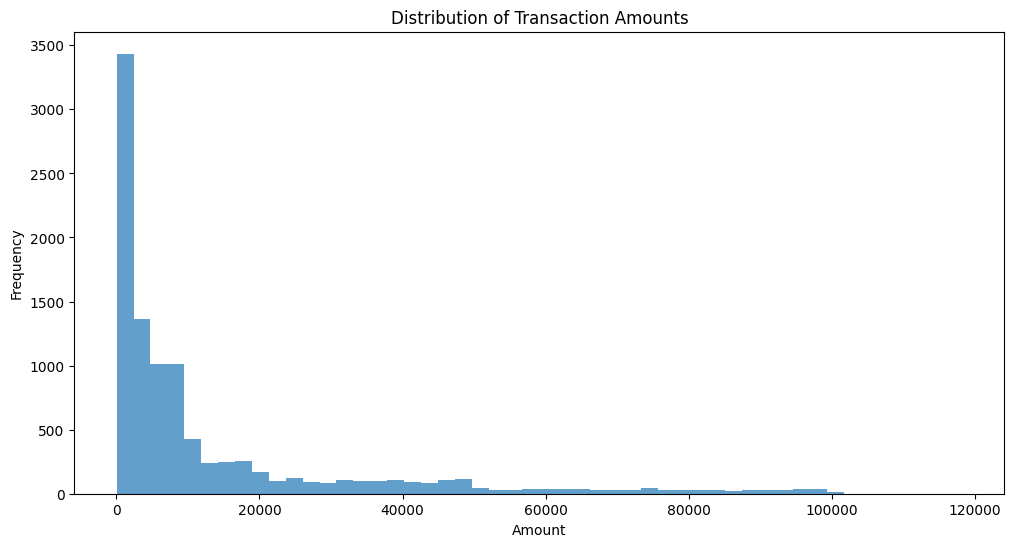

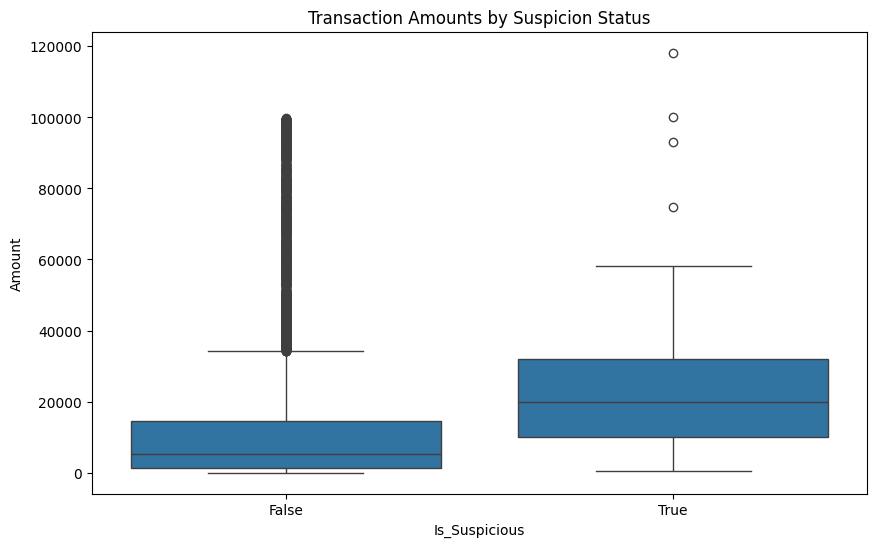

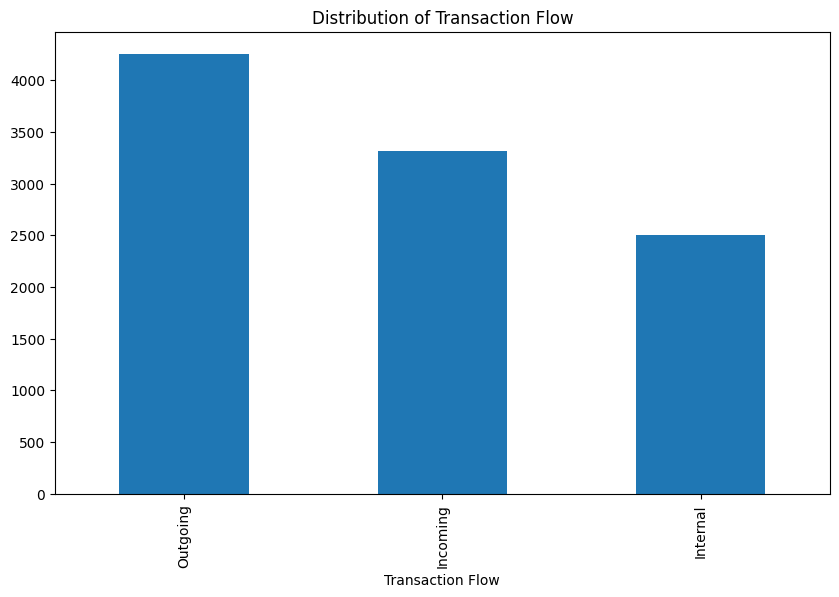

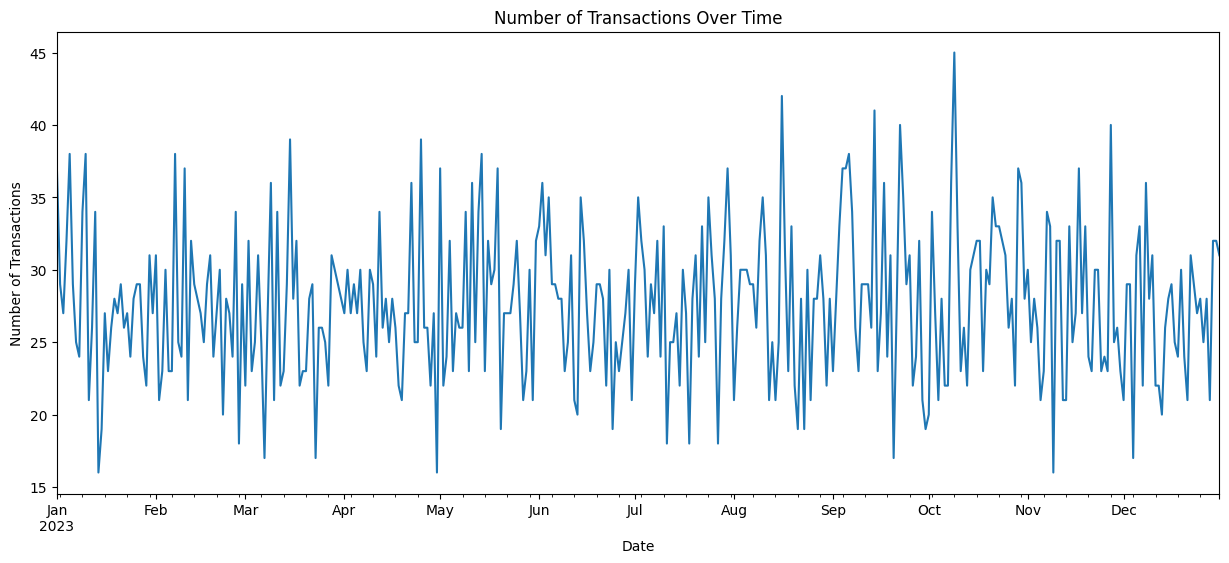


High-Risk Country Statistics:
Total transactions from high-risk countries: 0
Suspicious transactions from high-risk countries: 0

Transaction Amount Ranges:
Amount
0-10k       7036
10k-50k     2369
50k-100k     670
100k+          1
Name: count, dtype: int64

Suspicious Transactions by Amount Range:
Is_Suspicious  False  True 
Amount                     
0-10k           7014     22
10k-50k         2324     45
50k-100k         662      8
100k+              0      1

Transaction Type by Suspicion Status:
Is_Suspicious      False  True 
Transaction Type               
Cash Deposit        1272      0
Cash Withdrawal     1248      0
Cash withdrawal     1000     10
Currency Exchange   1000      4
SEPA                1317      0
SWIFT               1355      0
WIRE                2808     62


<Figure size 1200x600 with 0 Axes>

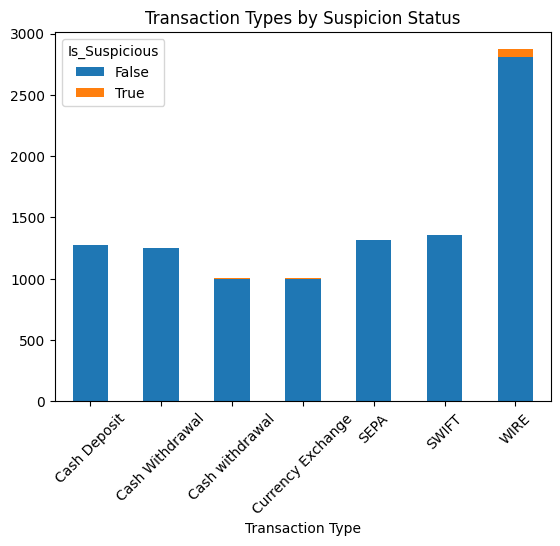


Currency Usage in Suspicious Transactions:
Is_Suspicious  False  True 
Currency                   
CHF             2052     14
EUR             1896     18
GBP             1967     18
JPY             2038     11
USD             2047     15


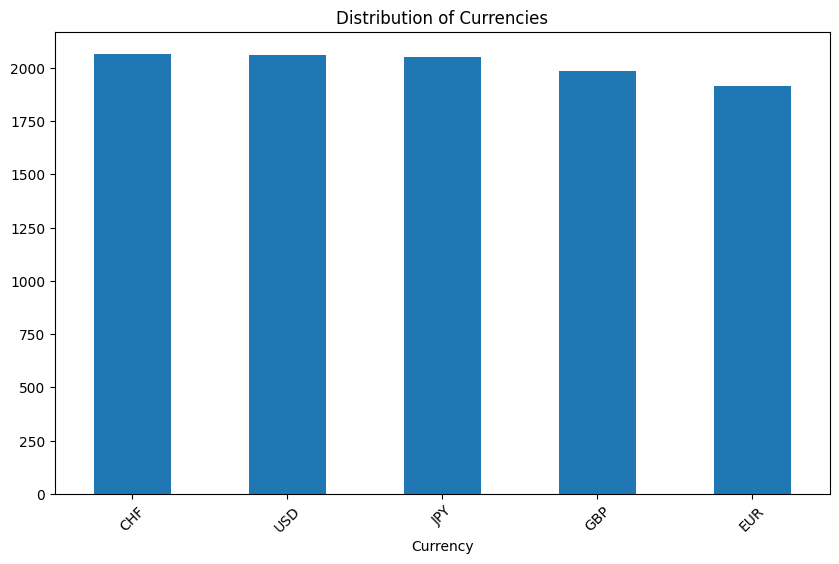

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Load the synthetic data
synthetic_data = pd.read_csv('synthetic_transactions_structured.csv')

# 1. Basic Statistics
print("Basic Statistics for Amount:")
print(synthetic_data['Amount'].describe())

# 2. Transaction Analysis
print("\nTransaction Type Distribution:")
print(synthetic_data['Transaction Type'].value_counts(normalize=True))

print("\nCurrency Distribution:")
print(synthetic_data['Currency'].value_counts(normalize=True))

print("\nTop 10 Countries:")
print(synthetic_data['Country'].value_counts().head(10))

# 3. Suspicious Transaction Analysis
suspicious_ratio = synthetic_data['Is_Suspicious'].mean()
print(f"\nSuspicious Transaction Ratio: {suspicious_ratio:.2%}")

# Average amount by suspicion status
print("\nAverage Amount by Suspicion Status:")
print(synthetic_data.groupby('Is_Suspicious')['Amount'].mean())

# Distribution of Suspicion Categories
print("\nDistribution of Suspicion Categories:")
print(synthetic_data['Suspicion Category'].value_counts(normalize=True))

# 4. Visualizations
plt.figure(figsize=(12, 6))
plt.hist(synthetic_data['Amount'], bins=50, alpha=0.7)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

# Box plot of amounts by suspicion status
plt.figure(figsize=(10, 6))
sns.boxplot(x='Is_Suspicious', y='Amount', data=synthetic_data)
plt.title('Transaction Amounts by Suspicion Status')
plt.show()

# Transaction flow analysis
plt.figure(figsize=(10, 6))
synthetic_data['Transaction Flow'].value_counts().plot(kind='bar')
plt.title('Distribution of Transaction Flow')
plt.show()

# 5. Time Series Analysis
# Convert Date to datetime
synthetic_data['Date'] = pd.to_datetime(synthetic_data['Date'])

# Transaction count over time
plt.figure(figsize=(15, 6))
synthetic_data.groupby('Date').size().plot()
plt.title('Number of Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.show()

# 6. High-Risk Analysis
high_risk_countries = ['Cayman Islands', 'British Virgin Islands', 'Panama']
high_risk_transactions = synthetic_data[synthetic_data['Country'].isin(high_risk_countries)]

print("\nHigh-Risk Country Statistics:")
print(f"Total transactions from high-risk countries: {len(high_risk_transactions)}")
print(f"Suspicious transactions from high-risk countries: {len(high_risk_transactions[high_risk_transactions['Is_Suspicious']])}")

# 7. Amount Range Analysis
amount_ranges = pd.cut(synthetic_data['Amount'],
                      bins=[0, 10000, 50000, 100000, float('inf')],
                      labels=['0-10k', '10k-50k', '50k-100k', '100k+'])
print("\nTransaction Amount Ranges:")
print(amount_ranges.value_counts())

# Suspicious transactions by amount range
print("\nSuspicious Transactions by Amount Range:")
suspicious_by_range = pd.crosstab(amount_ranges, synthetic_data['Is_Suspicious'])
print(suspicious_by_range)

# 8. Transaction Type Analysis
print("\nTransaction Type by Suspicion Status:")
print(pd.crosstab(synthetic_data['Transaction Type'], synthetic_data['Is_Suspicious']))

# Visualization of suspicious transactions by transaction type
plt.figure(figsize=(12, 6))
suspicious_by_type = pd.crosstab(synthetic_data['Transaction Type'], synthetic_data['Is_Suspicious'])
suspicious_by_type.plot(kind='bar', stacked=True)
plt.title('Transaction Types by Suspicion Status')
plt.xticks(rotation=45)
plt.show()

# 9. Currency Analysis
print("\nCurrency Usage in Suspicious Transactions:")
currency_suspicious = pd.crosstab(synthetic_data['Currency'], synthetic_data['Is_Suspicious'])
print(currency_suspicious)

# Plot currency distribution
plt.figure(figsize=(10, 6))
synthetic_data['Currency'].value_counts().plot(kind='bar')
plt.title('Distribution of Currencies')
plt.xticks(rotation=45)
plt.show()

### DATA QUALITY REPORT ###

1. BASIC DATA QUALITY METRICS
--------------------------------------------------
Total Records: 10076
Missing Values:
Transaction_id        0
Sender                0
Receiver              0
Amount                0
Currency              0
Country               0
Transaction Type      0
Description           0
Date                  0
Transaction Flow      0
Is_Suspicious         0
Suspicion Category    0
dtype: int64

Duplicate Records: 0

2. TRANSACTION AMOUNT ANALYSIS
--------------------------------------------------

Amount Statistics:
count     10076.000000
mean      13534.841591
std       20295.697991
min          50.000000
25%        1388.822500
50%        5287.060000
75%       14832.500000
max      118200.000000
Name: Amount, dtype: float64


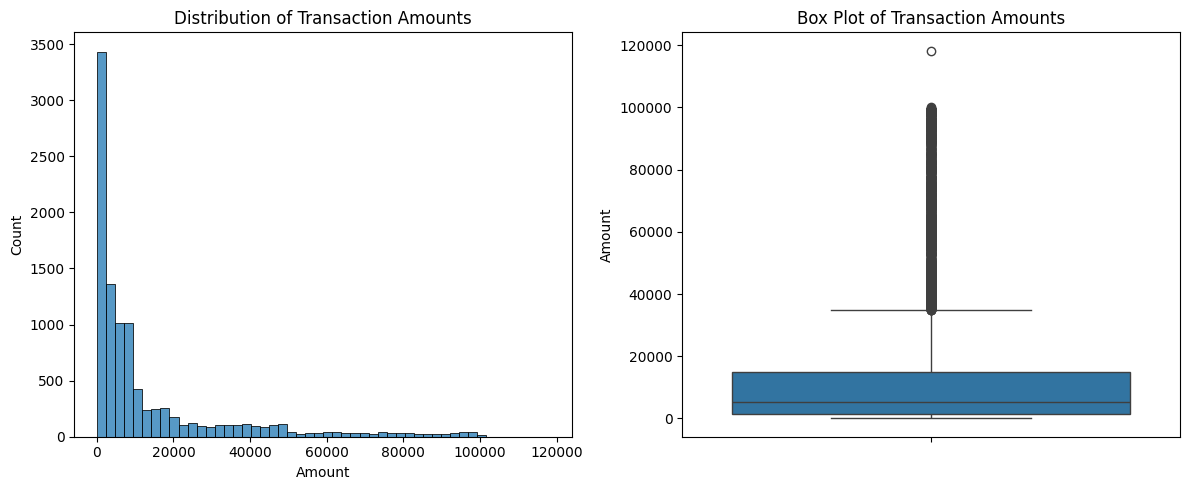


3. SUSPICIOUS TRANSACTION ANALYSIS
--------------------------------------------------
Suspicious Transaction Ratio: 0.75%

Amount Statistics by Suspicion Status:
                 count          mean           std    min      25%       50%  \
Is_Suspicious                                                                  
False          10000.0  13438.135887  20247.956853   50.0   1378.6   5211.62   
True              76.0  26259.276316  22586.385174  540.0  10000.0  19880.00   

                   75%       max  
Is_Suspicious                     
False          14542.5   99890.0  
True           31872.5  118200.0  


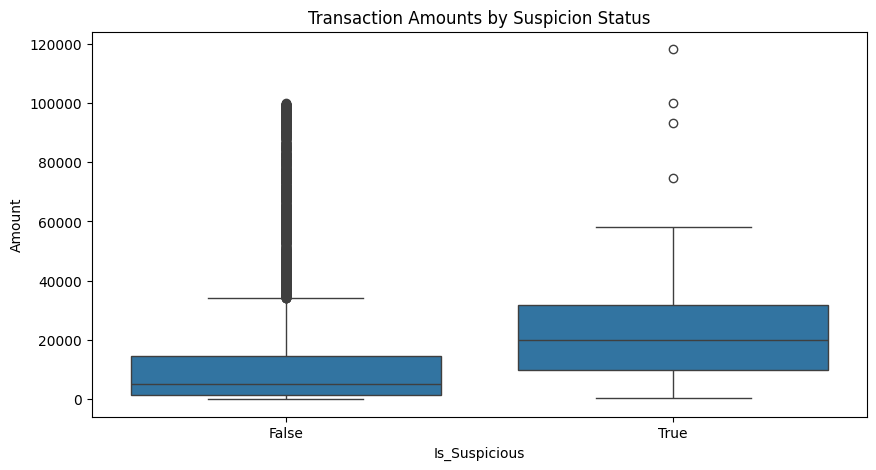


4. CATEGORICAL VARIABLE ANALYSIS
--------------------------------------------------

Currency Distribution:
Currency
CHF    0.205042
USD    0.204645
JPY    0.203355
GBP    0.197003
EUR    0.189956
Name: proportion, dtype: float64


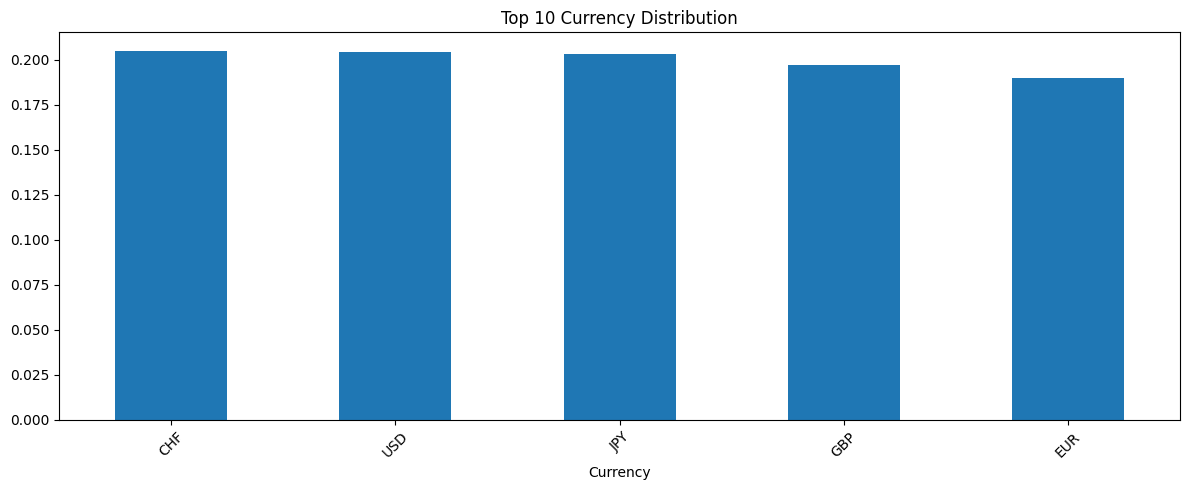


Country Distribution:
Country
United States             0.087733
Germany                   0.085748
United Kingdom            0.080389
Svalbard and Jan Mayen    0.007741
Sweden                    0.007543
Name: proportion, dtype: float64


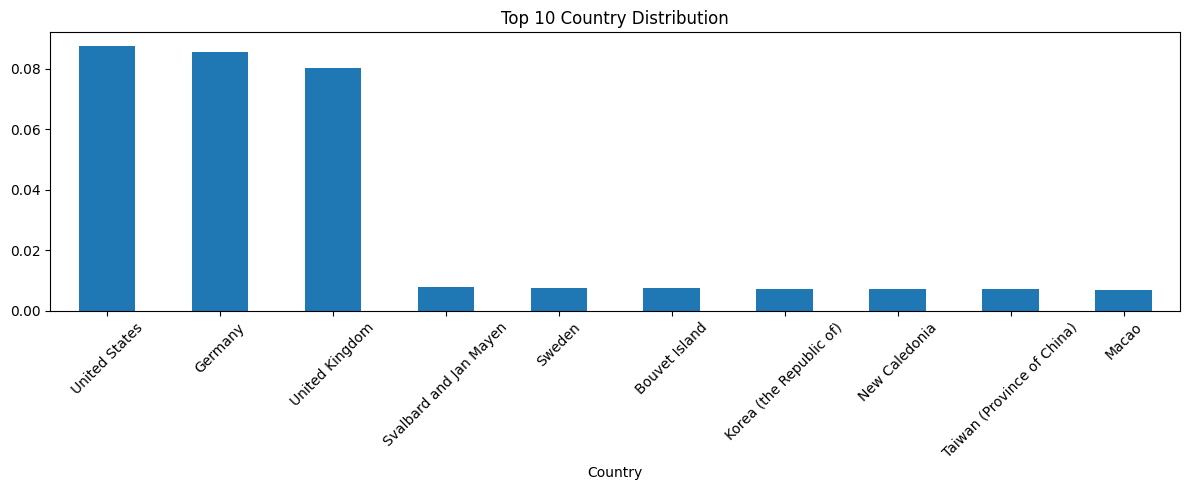


Transaction Type Distribution:
Transaction Type
WIRE               0.284835
SWIFT              0.134478
SEPA               0.130707
Cash Deposit       0.126241
Cash Withdrawal    0.123859
Name: proportion, dtype: float64


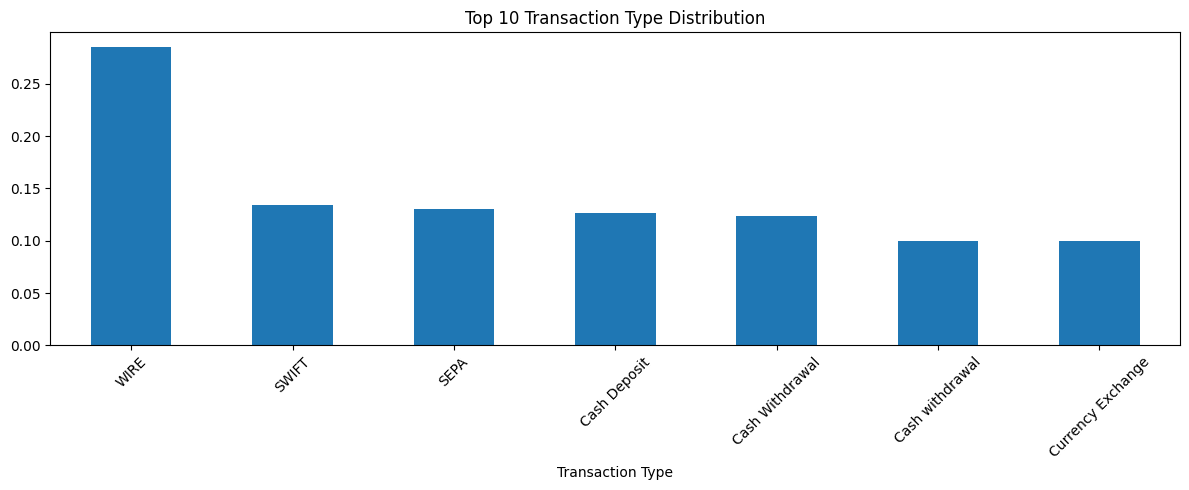


Transaction Flow Distribution:
Transaction Flow
Outgoing    0.422588
Incoming    0.328900
Internal    0.248511
Name: proportion, dtype: float64


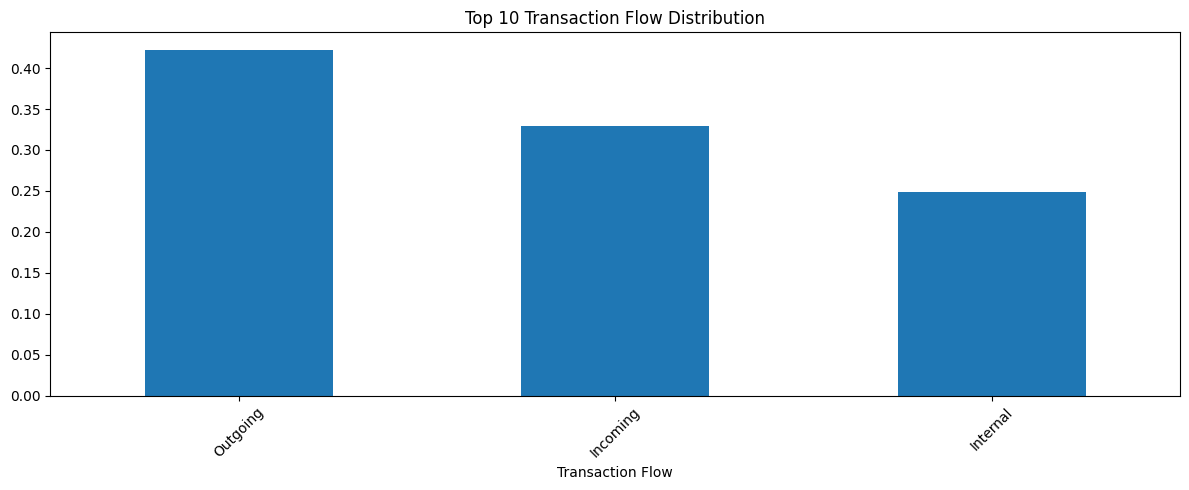


Suspicion Category Distribution:
Suspicion Category
Normal                                0.992457
Rapid Currency Conversion             0.000397
Very High-Risk Country Transaction    0.000397
Fictitious Loans                      0.000397
Transit Payments                      0.000397
Name: proportion, dtype: float64


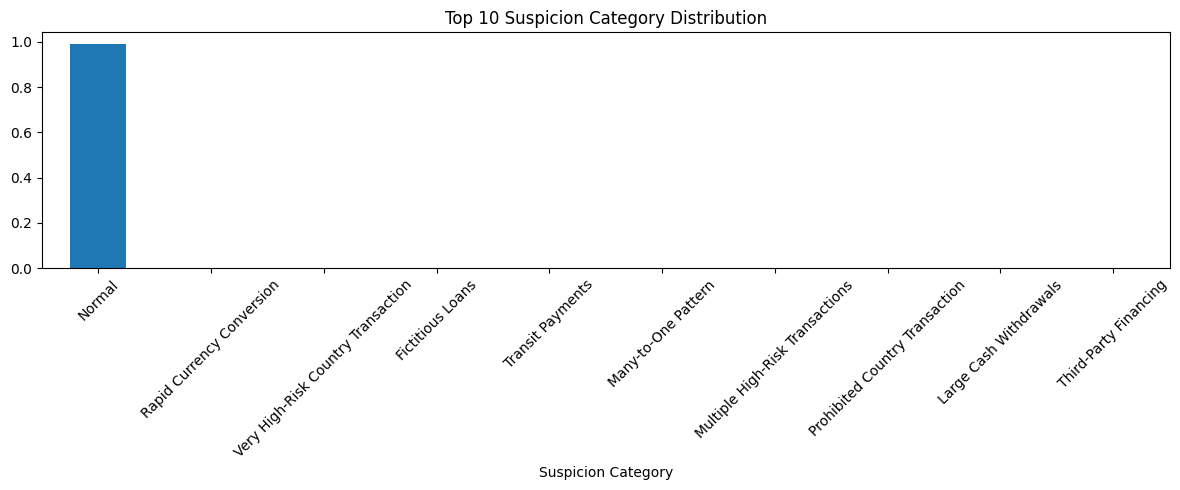


5. TEMPORAL ANALYSIS
--------------------------------------------------


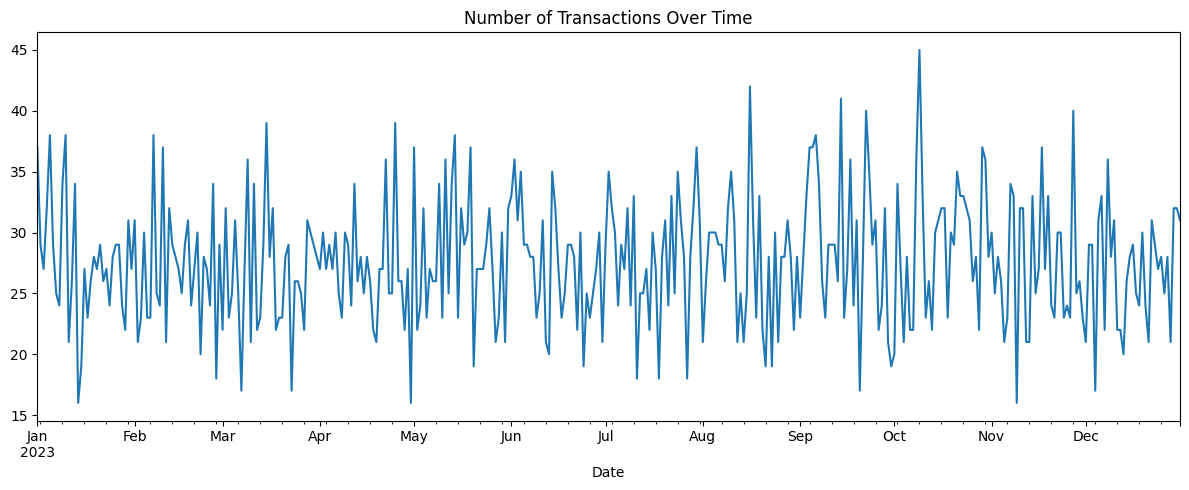


6. PATTERN ANALYSIS
--------------------------------------------------

Currency usage in suspicious transactions:
Is_Suspicious     False     True 
Currency                         
CHF            0.993224  0.006776
EUR            0.990596  0.009404
GBP            0.990932  0.009068
JPY            0.994632  0.005368
USD            0.992726  0.007274

High-risk country transactions: 0
Suspicious transactions in high-risk countries: 0

7. DATA QUALITY SCORES
--------------------------------------------------
Completeness Score: 100.00%
Uniqueness Score: 100.00%
Currency Consistency Score: 100.00%

8. RELATIONSHIP ANALYSIS
--------------------------------------------------


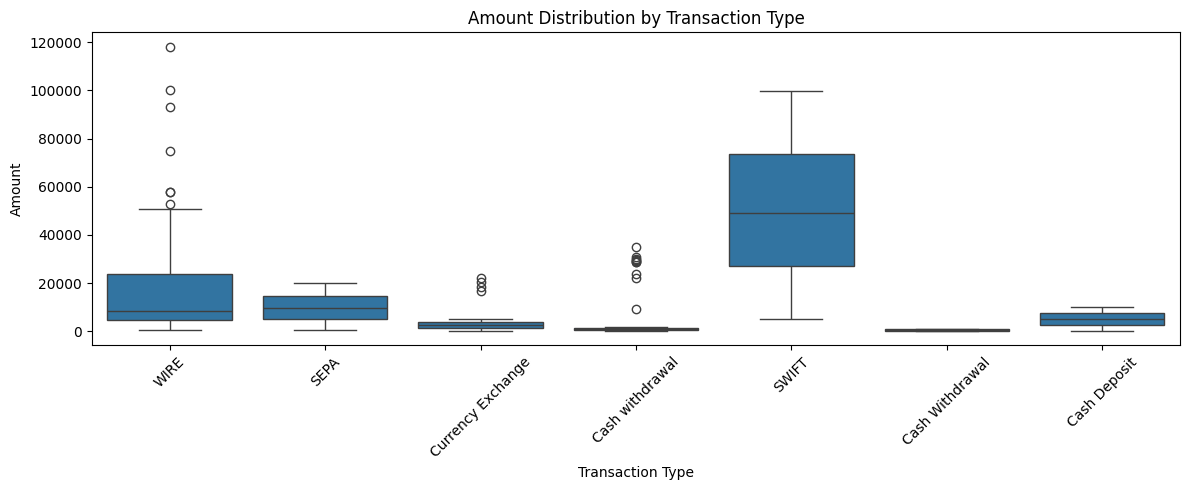


Suspicious patterns by Transaction Flow:
Is_Suspicious        False     True 
Transaction Flow                    
Incoming          0.995775  0.004225
Internal          0.998403  0.001597
Outgoing          0.986379  0.013621

9. SUMMARY AND RECOMMENDATIONS
--------------------------------------------------

Identified Issues:
No major issues identified


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def test_synthetic_data(df):
    """
    Comprehensive function to test synthetic transaction data quality
    Parameters:
    df (pandas.DataFrame): The synthetic transaction dataset
    """
    print("### DATA QUALITY REPORT ###\n")

    # 1. Basic Data Quality Checks
    print("1. BASIC DATA QUALITY METRICS")
    print("-" * 50)
    print(f"Total Records: {len(df)}")
    print(f"Missing Values:\n{df.isnull().sum()}")
    print("\nDuplicate Records:", df.duplicated().sum())

    # 2. Statistical Summary of Amount
    print("\n2. TRANSACTION AMOUNT ANALYSIS")
    print("-" * 50)
    amount_stats = df['Amount'].describe()
    print("\nAmount Statistics:")
    print(amount_stats)

    # Visualize Amount Distribution
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df['Amount'], bins=50)
    plt.title('Distribution of Transaction Amounts')
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df['Amount'])
    plt.title('Box Plot of Transaction Amounts')
    plt.tight_layout()
    plt.show()

    # 3. Suspicious Transaction Analysis
    print("\n3. SUSPICIOUS TRANSACTION ANALYSIS")
    print("-" * 50)
    suspicious_ratio = df['Is_Suspicious'].mean()
    print(f"Suspicious Transaction Ratio: {suspicious_ratio:.2%}")

    # Amount by Suspicion Status
    print("\nAmount Statistics by Suspicion Status:")
    print(df.groupby('Is_Suspicious')['Amount'].describe())

    # Visualize Amount by Suspicion Status
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='Is_Suspicious', y='Amount', data=df)
    plt.title('Transaction Amounts by Suspicion Status')
    plt.show()

    # 4. Categorical Variable Analysis
    print("\n4. CATEGORICAL VARIABLE ANALYSIS")
    print("-" * 50)

    categorical_cols = ['Currency', 'Country', 'Transaction Type',
                       'Transaction Flow', 'Suspicion Category']

    for col in categorical_cols:
        print(f"\n{col} Distribution:")
        dist = df[col].value_counts(normalize=True)
        print(dist.head())

        # Visualize top 10 categories
        plt.figure(figsize=(12, 5))
        dist.head(10).plot(kind='bar')
        plt.title(f'Top 10 {col} Distribution')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # 5. Temporal Analysis
    print("\n5. TEMPORAL ANALYSIS")
    print("-" * 50)

    df['Date'] = pd.to_datetime(df['Date'])

    # Transactions by date
    daily_transactions = df.groupby('Date').size()

    plt.figure(figsize=(12, 5))
    daily_transactions.plot()
    plt.title('Number of Transactions Over Time')
    plt.tight_layout()
    plt.show()

    # 6. Pattern Analysis
    print("\n6. PATTERN ANALYSIS")
    print("-" * 50)

    # Currency usage in suspicious transactions
    currency_suspicious = pd.crosstab(df['Currency'], df['Is_Suspicious'], normalize='index')
    print("\nCurrency usage in suspicious transactions:")
    print(currency_suspicious)

    # High-risk country analysis
    high_risk_countries = ['Cayman Islands', 'British Virgin Islands', 'Panama']
    high_risk_txns = df[df['Country'].isin(high_risk_countries)]
    print(f"\nHigh-risk country transactions: {len(high_risk_txns)}")
    print(f"Suspicious transactions in high-risk countries: "
          f"{len(high_risk_txns[high_risk_txns['Is_Suspicious']])}")

    # 7. Data Quality Scores
    print("\n7. DATA QUALITY SCORES")
    print("-" * 50)

    # Completeness Score
    completeness = 1 - (df.isnull().sum().sum() / (df.shape[0] * df.shape[1]))
    print(f"Completeness Score: {completeness:.2%}")

    # Uniqueness Score (based on duplicate records)
    uniqueness = 1 - (df.duplicated().sum() / len(df))
    print(f"Uniqueness Score: {uniqueness:.2%}")

    # Consistency Score (based on valid currency codes)
    valid_currencies = ['USD', 'EUR', 'GBP', 'CHF', 'JPY']
    currency_consistency = (df['Currency'].isin(valid_currencies).sum() / len(df))
    print(f"Currency Consistency Score: {currency_consistency:.2%}")

    # 8. Relationship Analysis
    print("\n8. RELATIONSHIP ANALYSIS")
    print("-" * 50)

    # Amount vs Transaction Type
    plt.figure(figsize=(12, 5))
    sns.boxplot(x='Transaction Type', y='Amount', data=df)
    plt.xticks(rotation=45)
    plt.title('Amount Distribution by Transaction Type')
    plt.tight_layout()
    plt.show()

    # Suspicious patterns by Transaction Flow
    flow_suspicious = pd.crosstab(df['Transaction Flow'], df['Is_Suspicious'], normalize='index')
    print("\nSuspicious patterns by Transaction Flow:")
    print(flow_suspicious)

    # 9. Summary and Recommendations
    print("\n9. SUMMARY AND RECOMMENDATIONS")
    print("-" * 50)

    # Data quality issues
    issues = []

    if suspicious_ratio > 0.1:
        issues.append("High suspicious transaction ratio (>10%)")

    if completeness < 0.95:
        issues.append("Low completeness score (<95%)")

    if uniqueness < 0.95:
        issues.append("Low uniqueness score (<95%)")

    if currency_consistency < 0.95:
        issues.append("Low currency consistency score (<95%)")

    if len(df['Transaction Type'].unique()) < 3:
        issues.append("Limited variety in transaction types (<3 types)")

    print("\nIdentified Issues:")
    if issues:
        for issue in issues:
            print(f"- {issue}")
    else:
        print("No major issues identified")

# Load and test the data
df = pd.read_csv('synthetic_transactions_structured.csv')
test_synthetic_data(df)

# GAN model

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load and preprocess the data
df = pd.read_csv('synthetic_transactions_structured.csv')

# Create label encoders for categorical columns
categorical_columns = ['Sender', 'Receiver', 'Currency', 'Country', 'Transaction Type',
                      'Description', 'Transaction Flow', 'Suspicion Category']
label_encoders = {}
for column in categorical_columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

# Convert date to numerical format (days since minimum date)
df['Date'] = pd.to_datetime(df['Date'])
min_date = df['Date'].min()
df['Date'] = (df['Date'] - min_date).dt.days

# Normalize numerical columns
scaler = StandardScaler()
numerical_columns = ['Amount', 'Date']
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Convert boolean column to int
df['Is_Suspicious'] = df['Is_Suspicious'].astype(int)

# Convert to tensor
data_tensor = torch.FloatTensor(df.values)

# Custom Dataset
class TransactionDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# Generator
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),

            nn.Linear(1024, output_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Training parameters
latent_dim = 100
output_dim = data_tensor.shape[1]
batch_size = 64
num_epochs = 100
lr = 0.0002
beta1 = 0.5

# Initialize models
generator = Generator(latent_dim, output_dim)
discriminator = Discriminator(output_dim)

# Loss function and optimizers
criterion = nn.BCELoss()
g_optimizer = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

# Create DataLoader
dataset = TransactionDataset(data_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Training loop
print("Starting training...")
for epoch in range(num_epochs):
    for i, real_transactions in enumerate(dataloader):
        batch_size = real_transactions.size(0)

        # Train Discriminator
        d_optimizer.zero_grad()
        label_real = torch.ones(batch_size, 1)
        label_fake = torch.zeros(batch_size, 1)

        output_real = discriminator(real_transactions)
        d_loss_real = criterion(output_real, label_real)

        z = torch.randn(batch_size, latent_dim)
        fake_transactions = generator(z)
        output_fake = discriminator(fake_transactions.detach())
        d_loss_fake = criterion(output_fake, label_fake)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        g_optimizer.zero_grad()
        output_fake = discriminator(fake_transactions)
        g_loss = criterion(output_fake, label_real)

        g_loss.backward()
        g_optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], d_loss: {d_loss.item():.4f}, g_loss: {g_loss.item():.4f}')

# Generate synthetic transactions
print("\nGenerating synthetic transactions...")
num_synthetic = 1000
z = torch.randn(num_synthetic, latent_dim)
with torch.no_grad():
    synthetic_data = generator(z).numpy()

# Convert back to DataFrame
synthetic_df = pd.DataFrame(synthetic_data, columns=df.columns)

# Inverse transform numerical columns
synthetic_df[numerical_columns] = scaler.inverse_transform(synthetic_df[numerical_columns])

# Inverse transform categorical columns
for column in categorical_columns:
    synthetic_df[column] = label_encoders[column].inverse_transform(synthetic_df[column].astype(int))

# Convert date back to datetime
synthetic_df['Date'] = pd.to_datetime(min_date + pd.to_timedelta(synthetic_df['Date'].astype(int), unit='D'))

# Convert Is_Suspicious back to boolean
synthetic_df['Is_Suspicious'] = synthetic_df['Is_Suspicious'].round().astype(bool)

# Save synthetic data
synthetic_df.to_csv('gan_synthetic_transactions.csv', index=False)
print("Synthetic transactions saved to 'gan_synthetic_transactions.csv'")

# Print summary statistics
print("\nSynthetic Data Summary:")
print(f"Total transactions: {len(synthetic_df)}")
print(f"Suspicious transactions: {len(synthetic_df[synthetic_df['Is_Suspicious']])}")
print(f"Normal transactions: {len(synthetic_df[~synthetic_df['Is_Suspicious']])}")

Starting training...
Epoch [10/100], d_loss: 0.0011, g_loss: 7.7035
Epoch [20/100], d_loss: 0.0002, g_loss: 10.4090
Epoch [30/100], d_loss: 0.0000, g_loss: 11.2851
Epoch [40/100], d_loss: 0.0001, g_loss: 12.6987
Epoch [50/100], d_loss: 0.0000, g_loss: 14.4042
Epoch [60/100], d_loss: 0.0000, g_loss: 15.7572
Epoch [70/100], d_loss: 0.0000, g_loss: 15.2872
Epoch [80/100], d_loss: 0.0000, g_loss: 17.5393
Epoch [90/100], d_loss: 0.0000, g_loss: 19.6866
Epoch [100/100], d_loss: 0.0000, g_loss: 20.8292

Generating synthetic transactions...
Synthetic transactions saved to 'gan_synthetic_transactions.csv'

Synthetic Data Summary:
Total transactions: 1000
Suspicious transactions: 82
Normal transactions: 918
